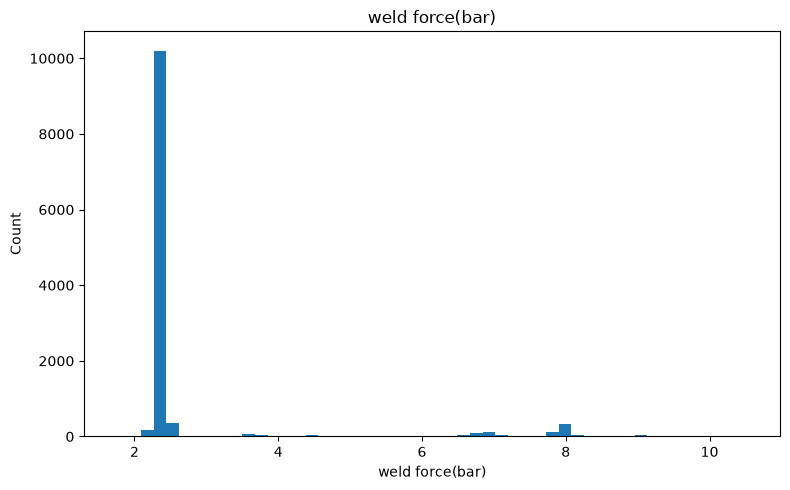

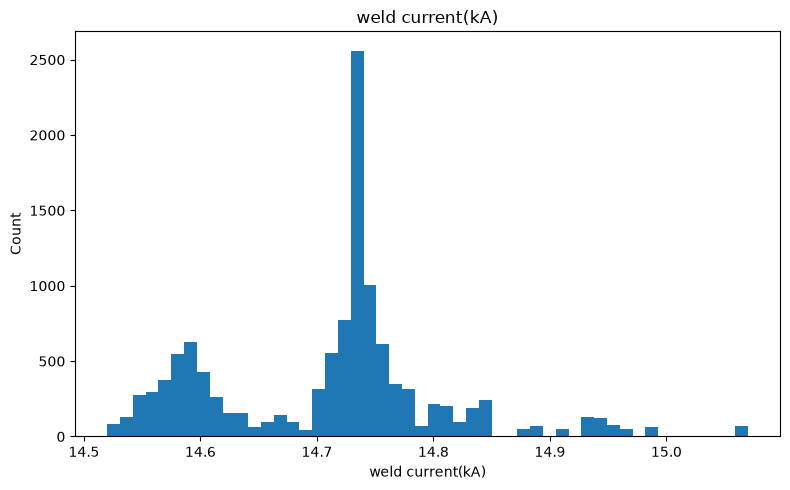

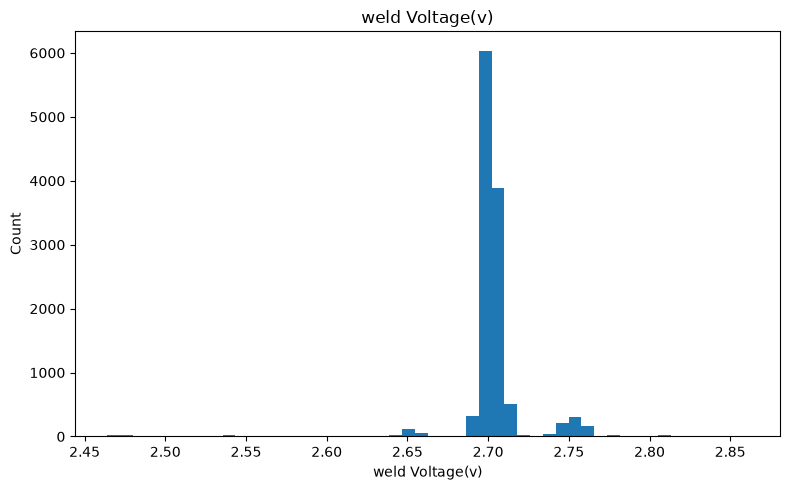

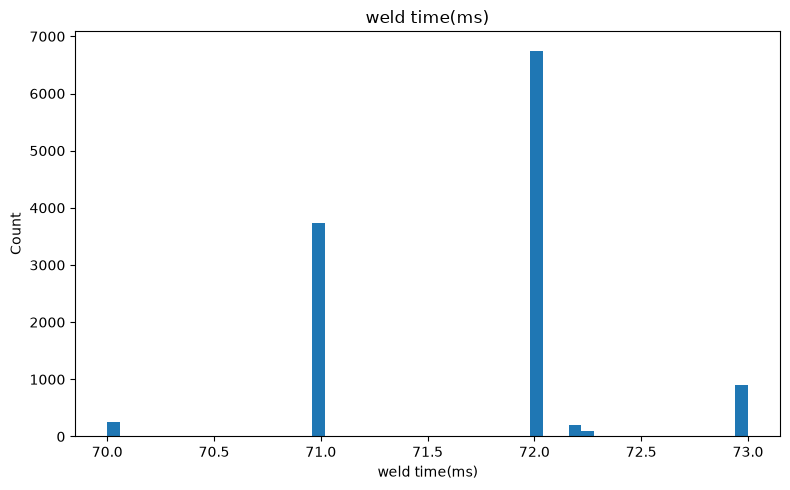

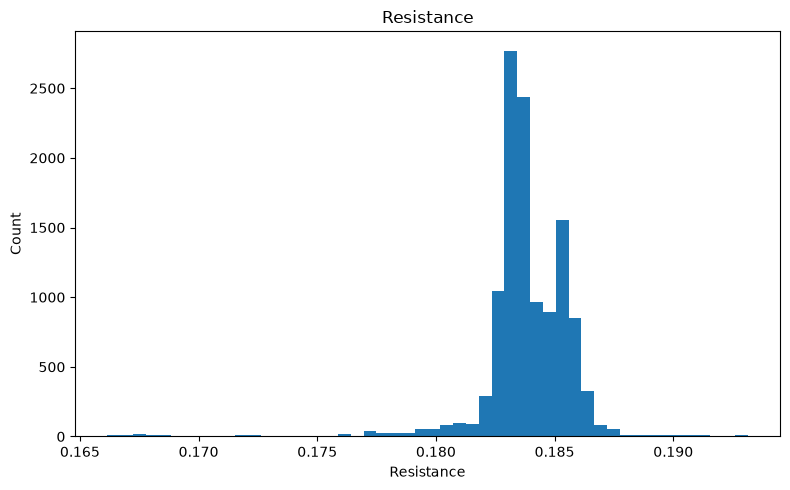

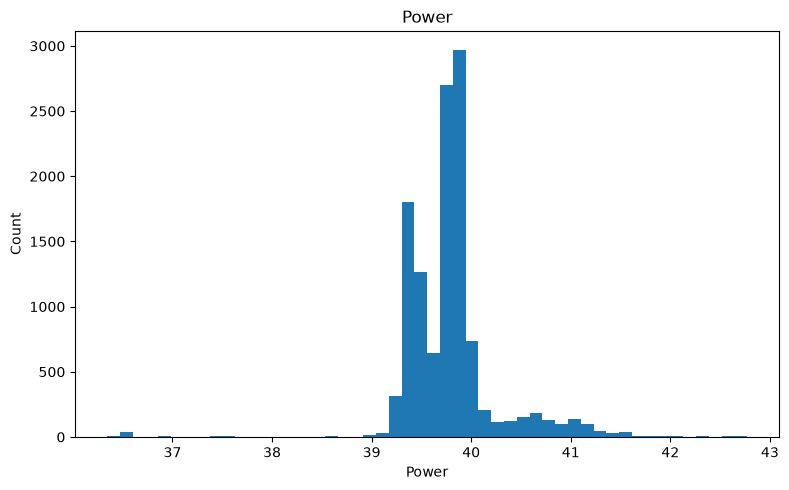

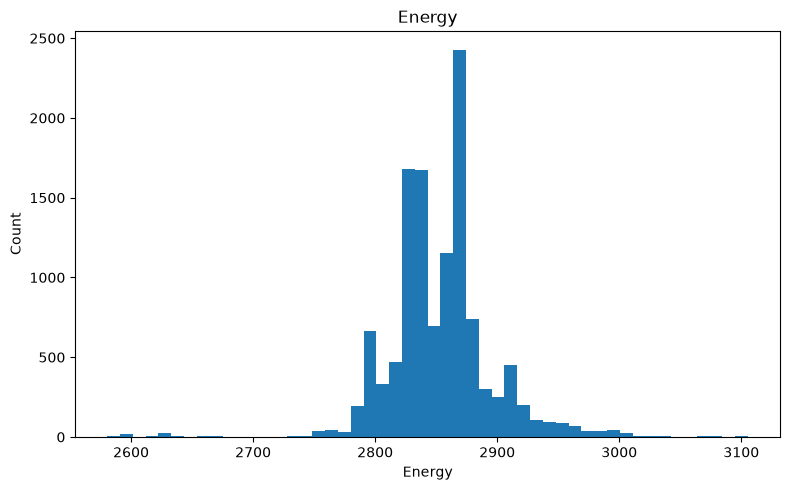

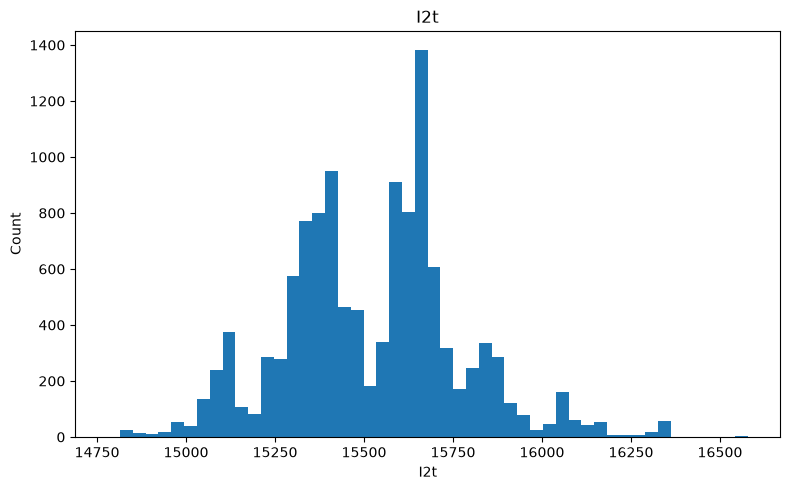

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 원본 엑셀 불러오기
df = pd.read_excel("experiments/YSJ/YSJ-001/Welding Data Set_01.xlsx")

# 파생변수 4개 생성
df["Resistance"] = df["weld Voltage(v)"] / df["weld current(kA)"]
df["Power"] = df["weld Voltage(v)"] * df["weld current(kA)"]
df["Energy"] = df["weld Voltage(v)"] * df["weld current(kA)"] * df["weld time(ms)"]
df["I2t"] = (df["weld current(kA)"] ** 2) * df["weld time(ms)"]

# 총 8개 변수
features = [
    "weld force(bar)",
    "weld current(kA)",
    "weld Voltage(v)",
    "weld time(ms)",
    "Resistance",
    "Power",
    "Energy",
    "I2t"
]

# 히스토그램 8개
for column in features:
    plt.figure(figsize=(8, 5))
    plt.hist(df[column].dropna(), bins=50)
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 데이터 불러오기
df = pd.read_excel(
    "experiments/YSJ/YSJ-001/Welding Data Set_01.xlsx"
)

# 날짜 생성
df["date"] = pd.to_datetime(df["working time"]).dt.date

# Energy
df["Energy"] = (
    df["weld Voltage(v)"]
    * df["weld current(kA)"]
    * df["weld time(ms)"]
)

# Resistance
df["Resistance"] = (
    df["weld Voltage(v)"]
    / df["weld current(kA)"]
)

# 날짜별 Current MAD
def mad(x):
    median = x.median()
    return (x - median).abs().median()

daily_mad = (
    df.groupby("date")["weld current(kA)"]
    .apply(mad)
)

df["Current_MAD"] = df["date"].map(daily_mad)

df[["date", "Current_MAD", "Energy", "Resistance"]].head()

,date,Current_MAD,Energy,Resistance
0,2020-03-24,0.04,2833.45704,0.185381
1,2020-03-24,0.04,2833.45704,0.185381
2,2020-03-24,0.04,2790.41502,0.185901
3,2020-03-24,0.04,2829.71664,0.185901
4,2020-03-24,0.04,2834.65728,0.185714


In [16]:
features = [
    "Current_MAD",
    "Energy",
    "Resistance"
]

model_df = df[features].dropna().copy()

scaler = StandardScaler()

X = scaler.fit_transform(model_df)

print("사용 행 개수:", len(model_df))
print("사용 변수:", features)

사용 행 개수: 11939
사용 변수: ['Current_MAD', 'Energy', 'Resistance']


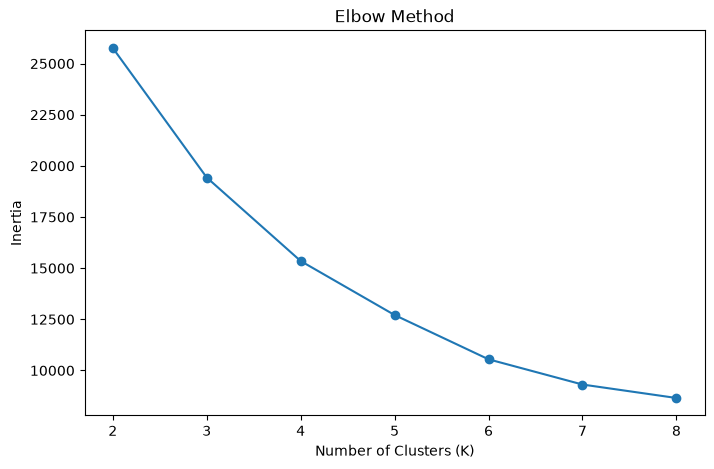

In [17]:
inertias = []

K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [18]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

model_df["Cluster"] = kmeans.fit_predict(X)

# 원본 데이터에도 cluster 붙이기
df.loc[model_df.index, "Cluster"] = model_df["Cluster"]

print(model_df["Cluster"].value_counts())

Cluster
1    6193
0    5670
2      76
Name: count, dtype: int64


In [20]:
cluster_summary = (
    model_df
    .groupby("Cluster")[features]
    .mean()
)

print(cluster_summary)

         Current_MAD       Energy  Resistance
Cluster                                      
0           0.054068  2850.392365    0.184192
1           0.028035  2858.710342    0.183677
2           0.043750  2641.739528    0.168909


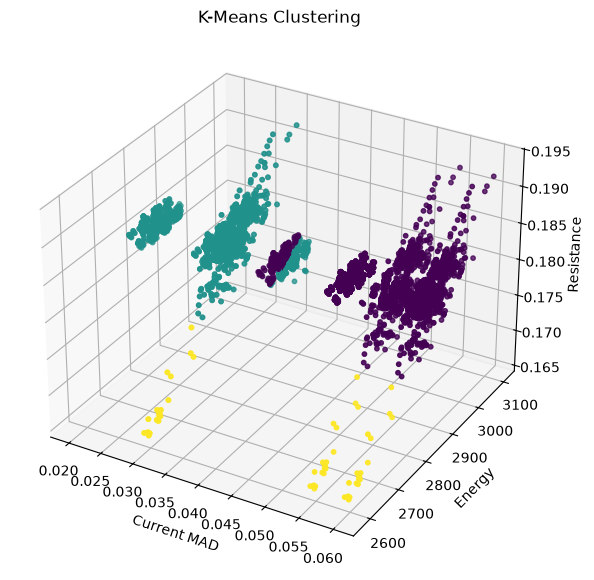

In [21]:
fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    model_df["Current_MAD"],
    model_df["Energy"],
    model_df["Resistance"],
    c=model_df["Cluster"],
    s=10
)

ax.set_xlabel("Current MAD")
ax.set_ylabel("Energy")
ax.set_zlabel("Resistance")

plt.title("K-Means Clustering")

plt.show()

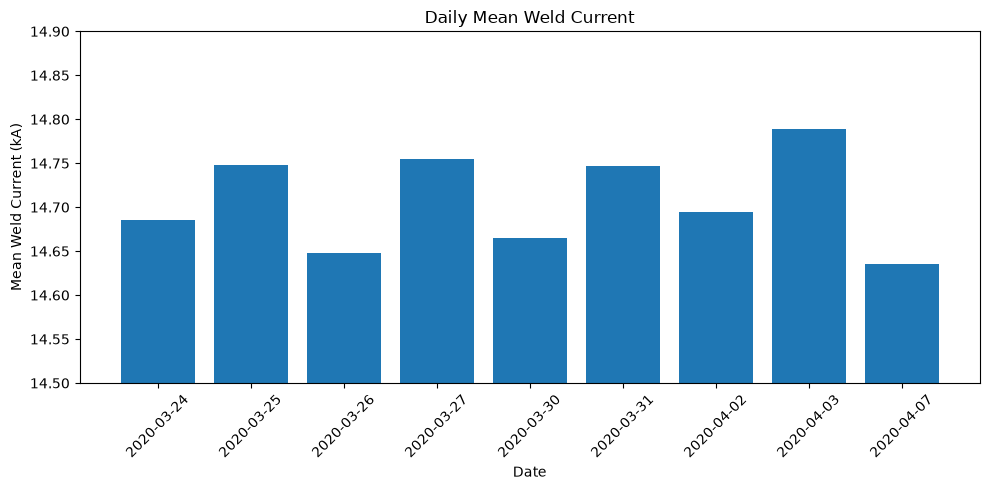

date
2020-03-24    14.685817
2020-03-25    14.748203
2020-03-26    14.648110
2020-03-27    14.754266
2020-03-30    14.664592
2020-03-31    14.746411
2020-04-02    14.694350
2020-04-03    14.788625
2020-04-07    14.635770
Name: weld current(kA), dtype: float64


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# 날짜 만들기
df["date"] = pd.to_datetime(df["working time"]).dt.date

# 날짜별 평균 전류
daily_current = (
    df.groupby("date")["weld current(kA)"]
    .mean()
)

# 그래프
plt.figure(figsize=(10, 5))

plt.bar(
    [str(x) for x in daily_current.index],
    daily_current.values
)

plt.xlabel("Date")
plt.ylabel("Mean Weld Current (kA)")
plt.title("Daily Mean Weld Current")

plt.xticks(rotation=45)
plt.ylim(14.5, 14.9)

plt.tight_layout()
plt.show()

# 실제 값 출력
print(daily_current)

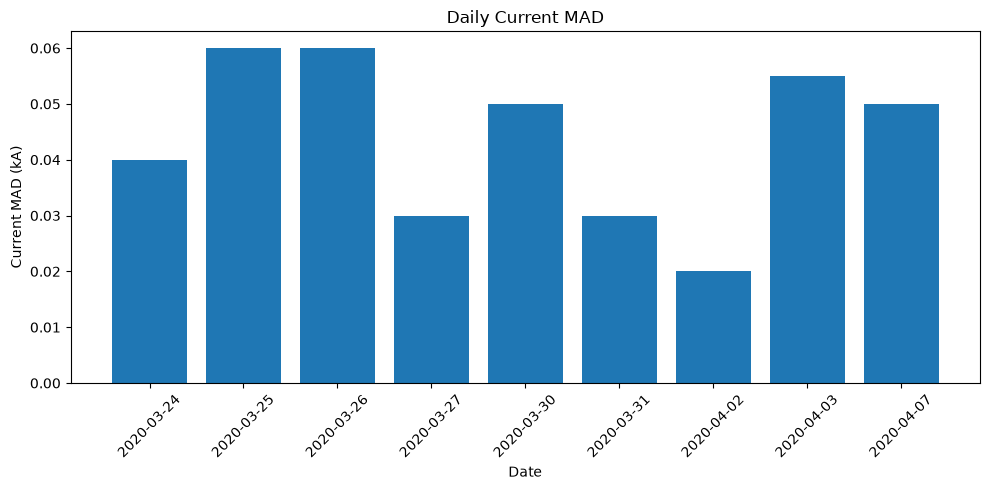

date
2020-03-24    0.040
2020-03-25    0.060
2020-03-26    0.060
2020-03-27    0.030
2020-03-30    0.050
2020-03-31    0.030
2020-04-02    0.020
2020-04-03    0.055
2020-04-07    0.050
Name: weld current(kA), dtype: float64


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# 날짜 생성
df["date"] = pd.to_datetime(df["working time"]).dt.date

# MAD 함수
def mad(x):
    median = x.median()
    return (x - median).abs().median()

# 날짜별 Current MAD
daily_mad = df.groupby("date")["weld current(kA)"].apply(mad)

# 그래프
plt.figure(figsize=(10, 5))

plt.bar(
    [str(x) for x in daily_mad.index],
    daily_mad.values
)

plt.xlabel("Date")
plt.ylabel("Current MAD (kA)")
plt.title("Daily Current MAD")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 실제 수치 출력
print(daily_mad)

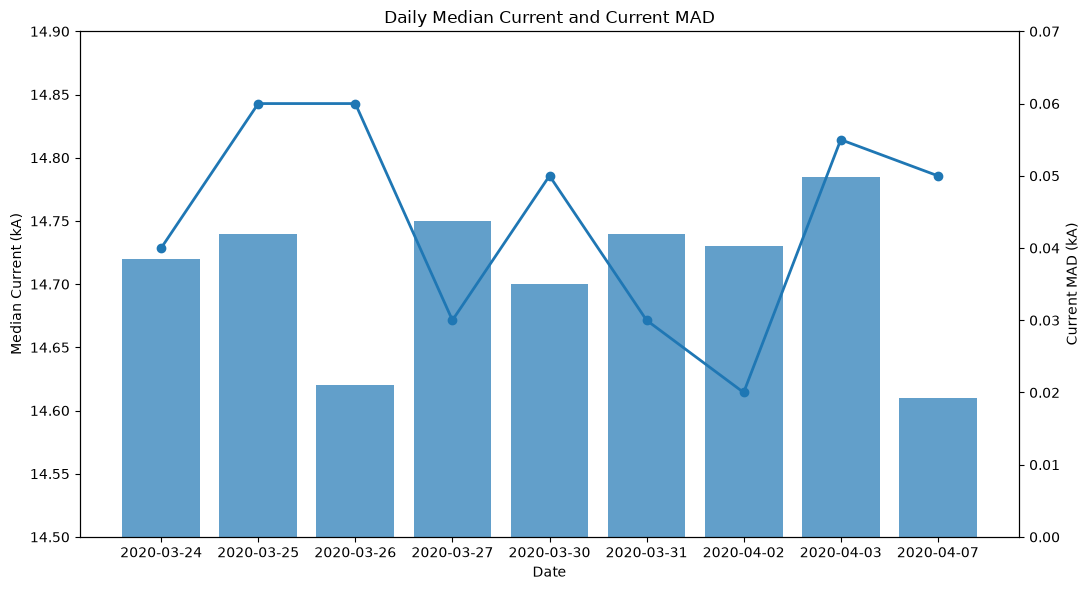

            Median_Current  Current_MAD
date                                   
2020-03-24          14.720        0.040
2020-03-25          14.740        0.060
2020-03-26          14.620        0.060
2020-03-27          14.750        0.030
2020-03-30          14.700        0.050
2020-03-31          14.740        0.030
2020-04-02          14.730        0.020
2020-04-03          14.785        0.055
2020-04-07          14.610        0.050


In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# 날짜 생성
df["date"] = pd.to_datetime(df["working time"]).dt.date

# MAD 함수
def mad(x):
    median = x.median()
    return (x - median).abs().median()

# 날짜별 중앙값
daily_median = df.groupby("date")["weld current(kA)"].median()

# 날짜별 MAD
daily_mad = df.groupby("date")["weld current(kA)"].apply(mad)

# 그래프
fig, ax1 = plt.subplots(figsize=(11, 6))

# 중앙값 - 막대
ax1.bar(
    [str(x) for x in daily_median.index],
    daily_median.values,
    alpha=0.7
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Median Current (kA)")
ax1.set_ylim(14.5, 14.9)

# MAD - 선 그래프
ax2 = ax1.twinx()

ax2.plot(
    [str(x) for x in daily_mad.index],
    daily_mad.values,
    marker="o",
    linewidth=2
)

ax2.set_ylabel("Current MAD (kA)")
ax2.set_ylim(0, 0.07)

plt.title("Daily Median Current and Current MAD")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 수치도 출력
result = pd.DataFrame({
    "Median_Current": daily_median,
    "Current_MAD": daily_mad
})

print(result)

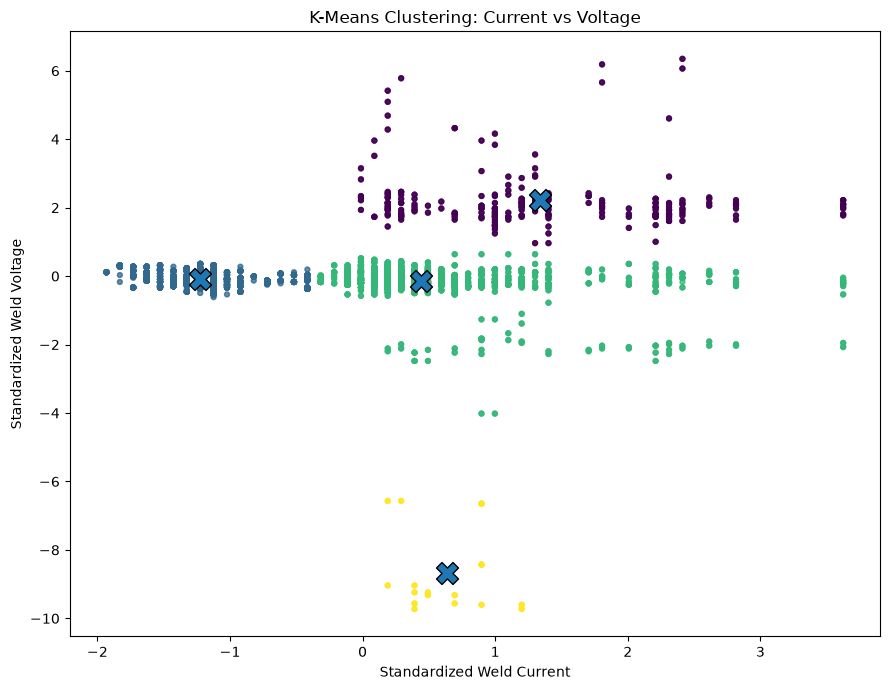

In [30]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. 사용할 변수
features = [
    "weld current(kA)",
    "weld Voltage(v)"
]

model_df = df[features].dropna().copy()

# 2. 표준화
scaler = StandardScaler()
X = scaler.fit_transform(model_df[features])

# 3. K-Means
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

model_df["Cluster"] = kmeans.fit_predict(X)

# 4. 표준화 공간에서 중심점
centers = kmeans.cluster_centers_

# 5. 그래프
plt.figure(figsize=(9, 7))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=model_df["Cluster"],
    s=12,
    alpha=0.5
)

# 군집 중심
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=250,
    edgecolors="black"
)

plt.xlabel("Standardized Weld Current")
plt.ylabel("Standardized Weld Voltage")
plt.title("K-Means Clustering: Current vs Voltage")

plt.tight_layout()
plt.show()

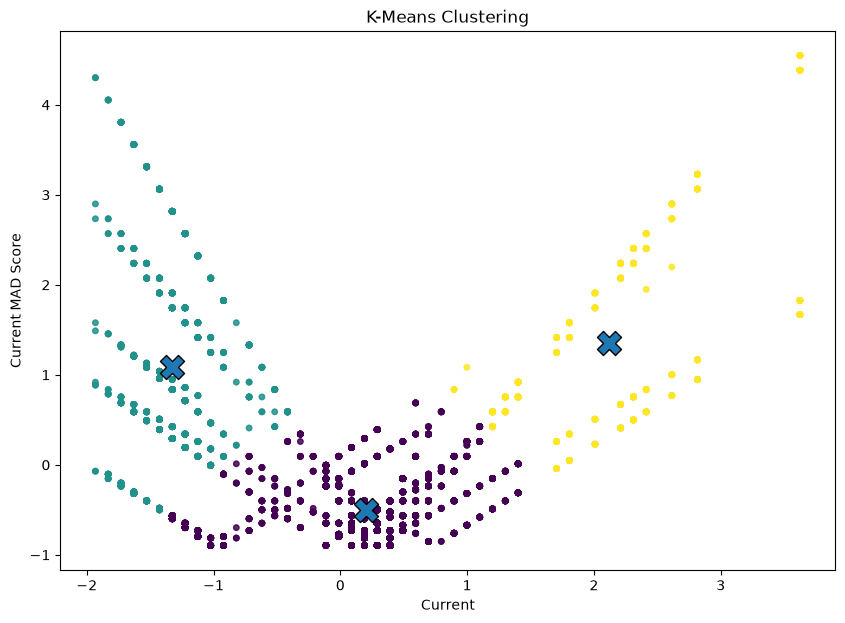

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 모델링에 사용할 변수
X = df[[
    "weld current(kA)",
    "Current_MAD_Score"
]].dropna()

# 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means 모델
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# 군집 예측
clusters = kmeans.fit_predict(X_scaled)

# 그래프
plt.figure(figsize=(10, 7))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters,
    s=15,
    alpha=0.6
)

# 군집 중심
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=300,
    edgecolors="black"
)

plt.xlabel("Current")
plt.ylabel("Current MAD Score")
plt.title("K-Means Clustering")

plt.show()

K-Means에 사용되는 전체 행: 11939


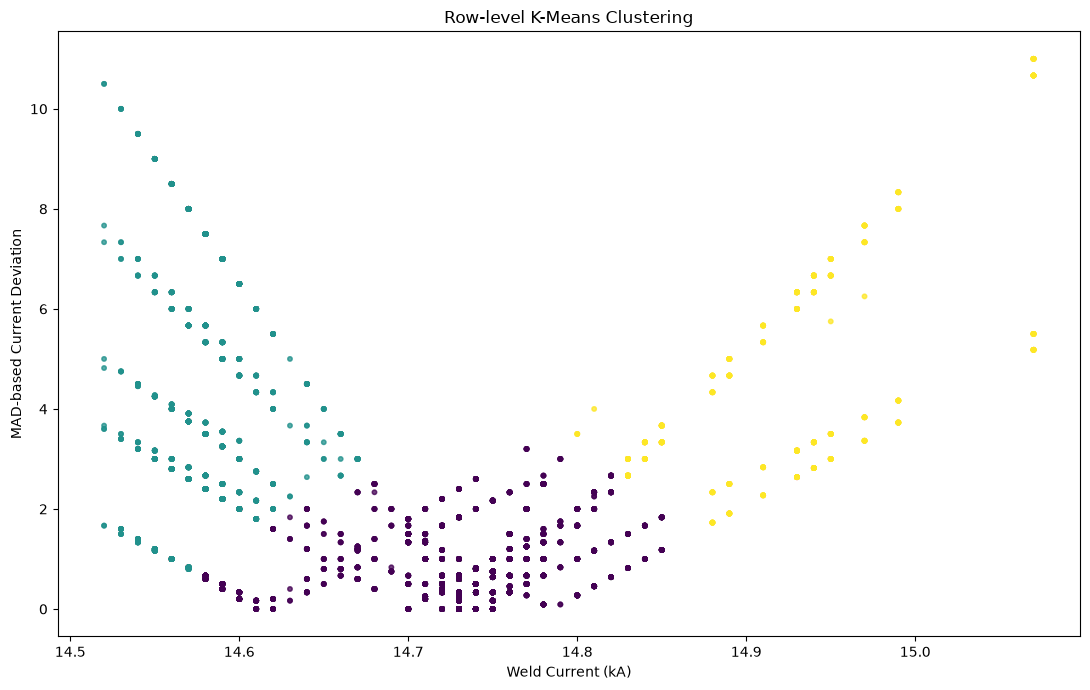


Cluster별 행 개수
Cluster
0    8335
1    2704
2     900
Name: count, dtype: int64

Cluster별 평균
         weld current(kA)  MAD_Score
Cluster                             
0               14.731109   0.804790
1               14.580126   4.000168
2               14.920733   4.540606


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# =====================================================
# 1. 날짜 생성
# =====================================================

df["date"] = pd.to_datetime(df["working time"]).dt.date


# =====================================================
# 2. 날짜별 전류 중앙값
# =====================================================

df["Daily_Median"] = (
    df.groupby("date")["weld current(kA)"]
      .transform("median")
)


# =====================================================
# 3. 각 행의 전류 편차
# |현재 전류 - 해당 날짜 중앙값|
# =====================================================

df["Current_Deviation"] = abs(
    df["weld current(kA)"] - df["Daily_Median"]
)


# =====================================================
# 4. 날짜별 MAD
# =====================================================

df["Daily_MAD"] = (
    df.groupby("date")["Current_Deviation"]
      .transform("median")
)


# =====================================================
# 5. 각 행의 MAD 기준 이탈도
# 이 값이 2 → 해당 날짜 MAD의 2배만큼 이탈
# =====================================================

df["MAD_Score"] = (
    df["Current_Deviation"] / df["Daily_MAD"]
)

# 무한값 제거
df["MAD_Score"] = df["MAD_Score"].replace(
    [np.inf, -np.inf],
    np.nan
)


# =====================================================
# 6. K-Means 입력 데이터
# =====================================================

model_df = df[
    [
        "weld current(kA)",
        "MAD_Score"
    ]
].dropna().copy()

print("K-Means에 사용되는 전체 행:", len(model_df))


# =====================================================
# 7. 표준화
# =====================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    model_df[
        [
            "weld current(kA)",
            "MAD_Score"
        ]
    ]
)


# =====================================================
# 8. K-Means
# =====================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

model_df["Cluster"] = kmeans.fit_predict(X_scaled)


# =====================================================
# 9. 11,000여 개 행 전체 시각화
# =====================================================

plt.figure(figsize=(11, 7))

plt.scatter(
    model_df["weld current(kA)"],
    model_df["MAD_Score"],
    c=model_df["Cluster"],
    s=10,
    alpha=0.5
)

plt.xlabel("Weld Current (kA)")
plt.ylabel("MAD-based Current Deviation")
plt.title("Row-level K-Means Clustering")

plt.tight_layout()
plt.show()


# =====================================================
# 10. 군집별 행 개수
# =====================================================

print("\nCluster별 행 개수")
print(model_df["Cluster"].value_counts().sort_index())


# =====================================================
# 11. 군집별 특징
# =====================================================

print("\nCluster별 평균")
print(
    model_df.groupby("Cluster")[
        ["weld current(kA)", "MAD_Score"]
    ].mean()
)

전체 모델링 행 개수: 11939
K=2, Silhouette=0.596
K=3, Silhouette=0.444
K=4, Silhouette=0.467
K=5, Silhouette=0.512
K=6, Silhouette=0.515


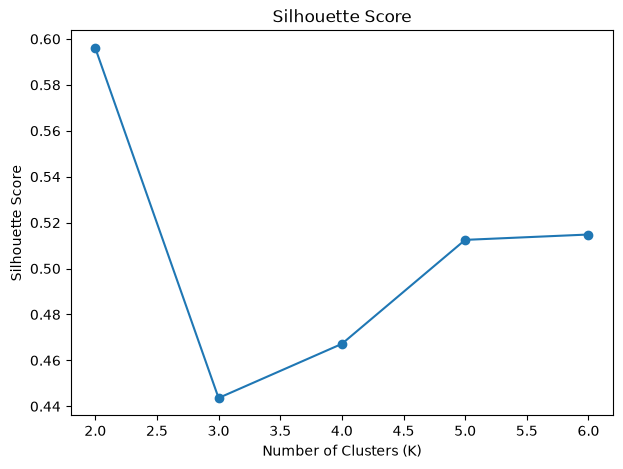

선택된 K: 2


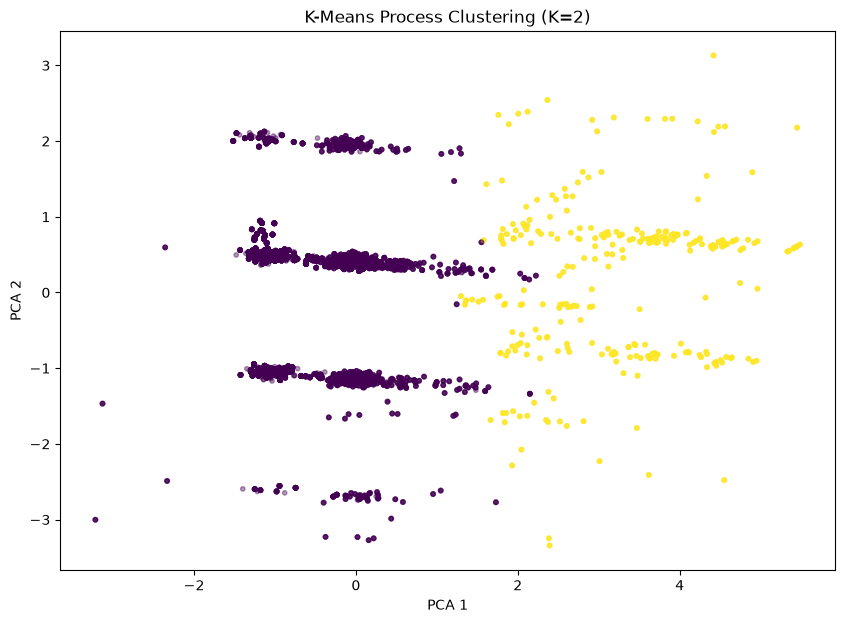


=== Cluster별 행 개수 ===
Cluster
0    10827
1     1112
Name: count, dtype: int64

=== Cluster별 공정변수 평균 ===
         weld force(bar)  weld current(kA)  weld Voltage(v)  weld time(ms)
Cluster                                                                   
0                  2.380            14.697            2.701         71.725
1                  6.756            14.849            2.738         71.712

=== Cluster별 공정변수 중앙값 ===
         weld force(bar)  weld current(kA)  weld Voltage(v)  weld time(ms)
Cluster                                                                   
0                  2.330             14.73            2.702           72.0
1                  7.375             14.83            2.752           72.0


In [34]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


# =====================================================
# 1. 4개 원본 공정변수
# =====================================================

features = [
    "weld force(bar)",
    "weld current(kA)",
    "weld Voltage(v)",
    "weld time(ms)"
]

model_df = df[features].dropna().copy()

print("전체 모델링 행 개수:", len(model_df))


# =====================================================
# 2. 표준화
# =====================================================

scaler = StandardScaler()
X = scaler.fit_transform(model_df)


# =====================================================
# 3. K=2~6 비교
# =====================================================

scores = []

for k in range(2, 7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X)

    score = silhouette_score(
        X,
        labels,
        sample_size=min(5000, len(X)),
        random_state=42
    )

    scores.append(score)

    print(f"K={k}, Silhouette={score:.3f}")


# =====================================================
# 4. Silhouette 그래프
# =====================================================

plt.figure(figsize=(7, 5))

plt.plot(
    range(2, 7),
    scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.show()


# =====================================================
# 5. 가장 높은 Silhouette의 K 선택
# =====================================================

best_k = range(2, 7)[scores.index(max(scores))]

print("선택된 K:", best_k)


# =====================================================
# 6. 최종 K-Means
# =====================================================

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

model_df["Cluster"] = kmeans.fit_predict(X)


# =====================================================
# 7. PCA - 4차원을 2차원으로 시각화
# =====================================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)


plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=model_df["Cluster"],
    s=10,
    alpha=0.4
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.title(
    f"K-Means Process Clustering (K={best_k})"
)

plt.show()


# =====================================================
# 8. 군집별 실제 공정조건 평균
# =====================================================

print("\n=== Cluster별 행 개수 ===")

print(
    model_df["Cluster"]
    .value_counts()
    .sort_index()
)


print("\n=== Cluster별 공정변수 평균 ===")

print(
    model_df.groupby("Cluster")[features]
    .mean()
    .round(3)
)


print("\n=== Cluster별 공정변수 중앙값 ===")

print(
    model_df.groupby("Cluster")[features]
    .median()
    .round(3)
)

전체 행: 11939
Force 2.0~2.6 행: 10739
K=2 | Silhouette=0.557
K=3 | Silhouette=0.575
K=4 | Silhouette=0.562
K=5 | Silhouette=0.454
K=6 | Silhouette=0.430


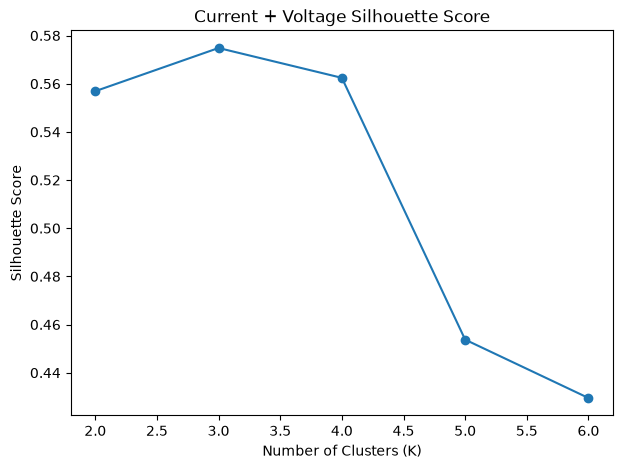

Best K = 3


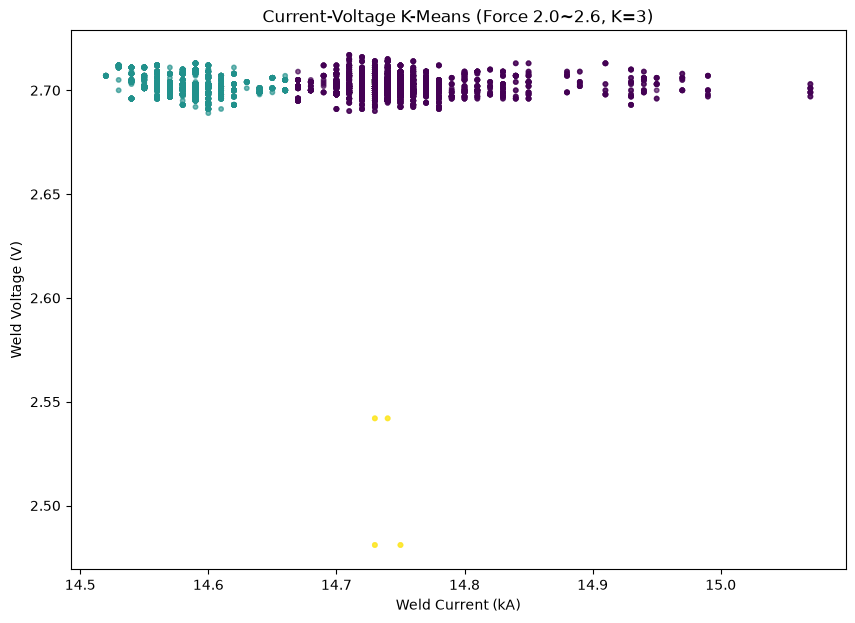


=== Cluster Count ===
Cluster
0    7232
1    3491
2      16
Name: count, dtype: int64

=== Cluster Mean ===
         weld current(kA)  weld Voltage(v)
Cluster                                   
0                 14.7494           2.7021
1                 14.5864           2.7023
2                 14.7375           2.5115

=== Cluster Median ===
         weld current(kA)  weld Voltage(v)
Cluster                                   
0                  14.740           2.7020
1                  14.590           2.7020
2                  14.735           2.5115


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# =====================================================
# 1. Force 주 공정군만 선택
#    이전 EDA 기준 2.0 ~ 2.6 bar
# =====================================================

main_df = df[
    (df["weld force(bar)"] >= 2.0) &
    (df["weld force(bar)"] <= 2.6)
].copy()

print("전체 행:", len(df))
print("Force 2.0~2.6 행:", len(main_df))


# =====================================================
# 2. Current + Voltage
# =====================================================

features = [
    "weld current(kA)",
    "weld Voltage(v)"
]

model_df = main_df[features].dropna().copy()


# =====================================================
# 3. 표준화
# =====================================================

scaler = StandardScaler()
X = scaler.fit_transform(model_df[features])


# =====================================================
# 4. K = 2~6 비교
# =====================================================

scores = []

for k in range(2, 7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X)

    score = silhouette_score(
        X,
        labels,
        sample_size=min(5000, len(X)),
        random_state=42
    )

    scores.append(score)

    print(f"K={k} | Silhouette={score:.3f}")


# =====================================================
# 5. Silhouette 그래프
# =====================================================

plt.figure(figsize=(7, 5))

plt.plot(
    range(2, 7),
    scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Current + Voltage Silhouette Score")

plt.show()


# =====================================================
# 6. 가장 높은 K 선택
# =====================================================

best_k = list(range(2, 7))[scores.index(max(scores))]

print("Best K =", best_k)


# =====================================================
# 7. 최종 K-Means
# =====================================================

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

model_df["Cluster"] = kmeans.fit_predict(X)


# =====================================================
# 8. 11,000여 행 중 해당 Force군의 모든 행 시각화
# =====================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    model_df["weld current(kA)"],
    model_df["weld Voltage(v)"],
    c=model_df["Cluster"],
    s=10,
    alpha=0.4
)

plt.xlabel("Weld Current (kA)")
plt.ylabel("Weld Voltage (V)")
plt.title(
    f"Current-Voltage K-Means (Force 2.0~2.6, K={best_k})"
)

plt.show()


# =====================================================
# 9. 군집별 특징
# =====================================================

print("\n=== Cluster Count ===")
print(
    model_df["Cluster"]
    .value_counts()
    .sort_index()
)

print("\n=== Cluster Mean ===")
print(
    model_df
    .groupby("Cluster")[features]
    .mean()
    .round(4)
)

print("\n=== Cluster Median ===")
print(
    model_df
    .groupby("Cluster")[features]
    .median()
    .round(4)
)

=== 날짜별 Cluster 개수 ===
Cluster        0    1  2
date                    
2020-03-24   786  414  0
2020-03-25   767  281  4
2020-03-26   440  560  0
2020-03-27  1132  212  4
2020-03-30   809  661  0
2020-03-31  1214  282  4
2020-04-02  1440  560  0
2020-04-03   401   95  4
2020-04-07   243  426  0

=== 날짜별 Cluster 비율(%) ===
Cluster         0      1     2
date                          
2020-03-24  65.50  34.50  0.00
2020-03-25  72.91  26.71  0.38
2020-03-26  44.00  56.00  0.00
2020-03-27  83.98  15.73  0.30
2020-03-30  55.03  44.97  0.00
2020-03-31  80.93  18.80  0.27
2020-04-02  72.00  28.00  0.00
2020-04-03  80.20  19.00  0.80
2020-04-07  36.32  63.68  0.00


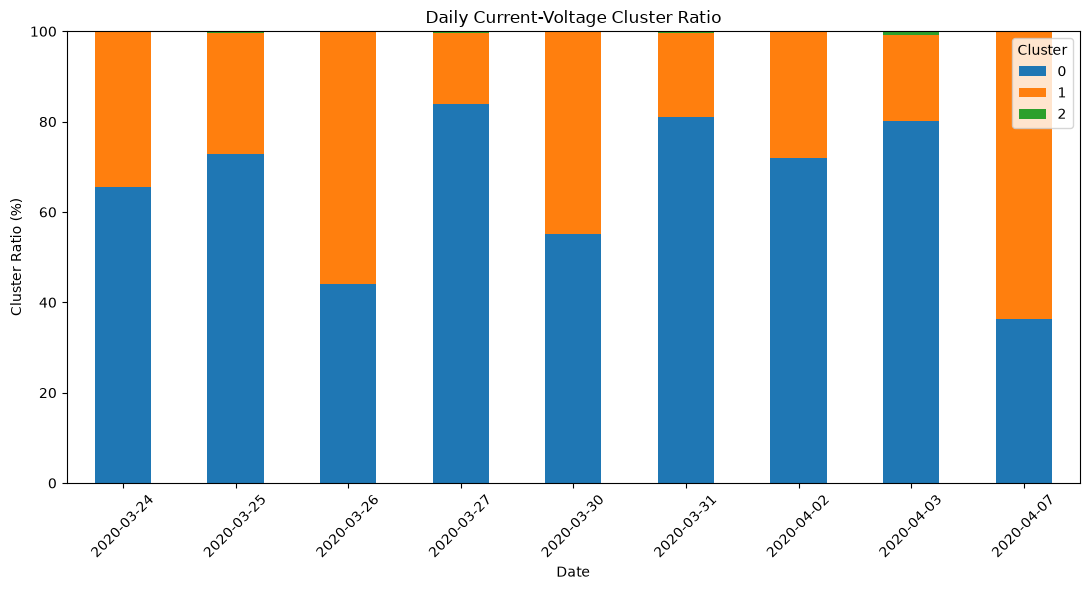

In [36]:
# 원본 행 번호 보존
model_df["date"] = main_df.loc[model_df.index, "date"]

# 날짜별 Cluster 개수
cluster_count = pd.crosstab(
    model_df["date"],
    model_df["Cluster"]
)

# 날짜별 Cluster 비율(%)
cluster_ratio = pd.crosstab(
    model_df["date"],
    model_df["Cluster"],
    normalize="index"
) * 100

print("=== 날짜별 Cluster 개수 ===")
print(cluster_count)

print("\n=== 날짜별 Cluster 비율(%) ===")
print(cluster_ratio.round(2))


# 그래프
cluster_ratio.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.ylabel("Cluster Ratio (%)")
plt.xlabel("Date")
plt.title("Daily Current-Voltage Cluster Ratio")
plt.xticks(rotation=45)
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

            Low_Current_Cluster_Ratio  Current_MAD
date                                              
2020-03-24                    34.5000        0.040
2020-03-25                    26.7110        0.060
2020-03-26                    56.0000        0.060
2020-03-27                    15.7270        0.030
2020-03-30                    44.9660        0.050
2020-03-31                    18.8000        0.030
2020-04-02                    28.0000        0.020
2020-04-03                    19.0000        0.055
2020-04-07                    63.6771        0.050


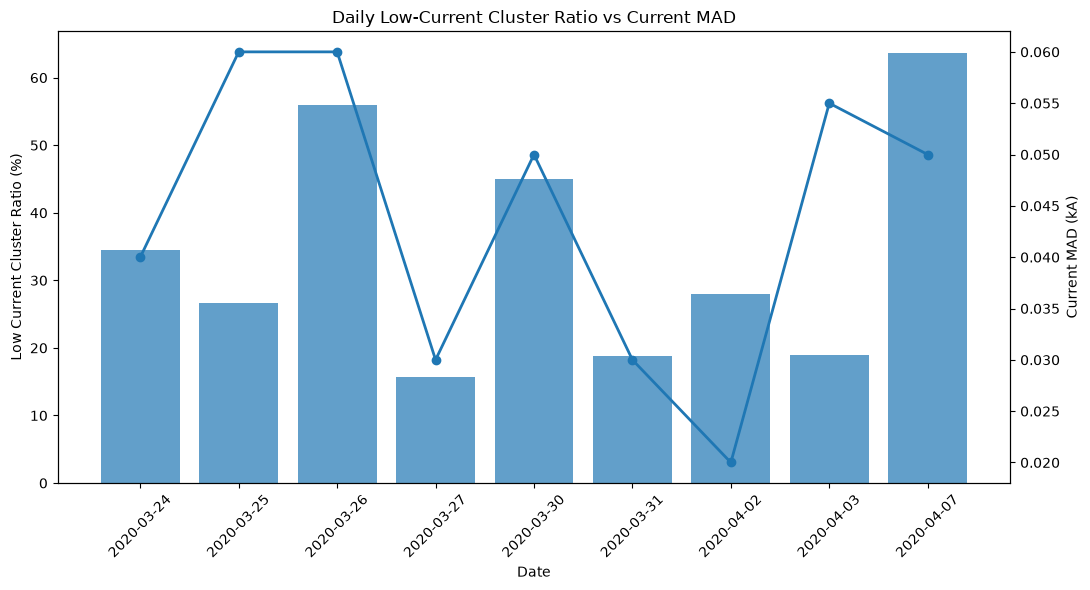

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. 날짜별 Current MAD 계산
# ==========================================

def mad(x):
    median = x.median()
    return (x - median).abs().median()

daily_mad = (
    df.groupby("date")["weld current(kA)"]
      .apply(mad)
)


# ==========================================
# 2. K-means 결과에 날짜 연결
# ==========================================

model_df["date"] = main_df.loc[model_df.index, "date"]


# ==========================================
# 3. 날짜별 저전류 Cluster 1 비율
# ==========================================

low_current_ratio = (
    model_df.groupby("date")["Cluster"]
    .apply(lambda x: (x == 1).mean() * 100)
)


# ==========================================
# 4. 하나의 데이터프레임으로 합치기
# ==========================================

daily_result = pd.DataFrame({
    "Low_Current_Cluster_Ratio": low_current_ratio,
    "Current_MAD": daily_mad
}).dropna()

print(daily_result.round(4))


# ==========================================
# 5. 그래프
# ==========================================

fig, ax1 = plt.subplots(figsize=(11, 6))

dates = [str(x) for x in daily_result.index]

# 저전류 Cluster 비율
ax1.bar(
    dates,
    daily_result["Low_Current_Cluster_Ratio"],
    alpha=0.7
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Low Current Cluster Ratio (%)")


# MAD
ax2 = ax1.twinx()

ax2.plot(
    dates,
    daily_result["Current_MAD"],
    marker="o",
    linewidth=2
)

ax2.set_ylabel("Current MAD (kA)")


plt.title("Daily Low-Current Cluster Ratio vs Current MAD")

ax1.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

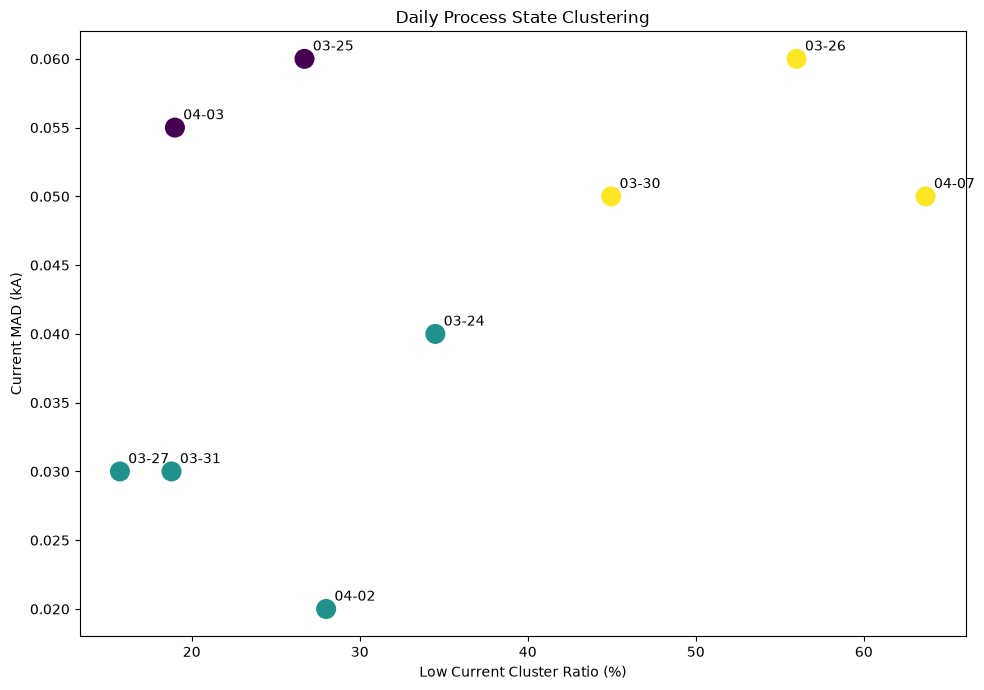

            Low_Current_Cluster_Ratio  Current_MAD  Process_Cluster
date                                                               
2020-03-24                    34.5000        0.040                1
2020-03-25                    26.7110        0.060                0
2020-03-26                    56.0000        0.060                2
2020-03-27                    15.7270        0.030                1
2020-03-30                    44.9660        0.050                2
2020-03-31                    18.8000        0.030                1
2020-04-02                    28.0000        0.020                1
2020-04-03                    19.0000        0.055                0
2020-04-07                    63.6771        0.050                2


In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. 사용할 변수
X = daily_result[
    ["Low_Current_Cluster_Ratio", "Current_MAD"]
].copy()

# 2. 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

daily_result["Process_Cluster"] = kmeans.fit_predict(X_scaled)

# 4. 생산일별 분포 시각화
plt.figure(figsize=(10, 7))

plt.scatter(
    daily_result["Low_Current_Cluster_Ratio"],
    daily_result["Current_MAD"],
    c=daily_result["Process_Cluster"],
    s=180
)

# 날짜 표시
for date, row in daily_result.iterrows():
    plt.annotate(
        str(date)[5:],
        (
            row["Low_Current_Cluster_Ratio"],
            row["Current_MAD"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Low Current Cluster Ratio (%)")
plt.ylabel("Current MAD (kA)")
plt.title("Daily Process State Clustering")

plt.tight_layout()
plt.show()

# 결과
print(
    daily_result[
        [
            "Low_Current_Cluster_Ratio",
            "Current_MAD",
            "Process_Cluster"
        ]
    ].round(4)
)

In [41]:
# 생산일별 군집 결과 확인
result = daily_result[
    [
        "Low_Current_Cluster_Ratio",
        "Current_MAD",
        "Process_Cluster"
    ]
].copy()

# 군집별 평균
cluster_summary = result.groupby("Process_Cluster")[
    ["Low_Current_Cluster_Ratio", "Current_MAD"]
].mean()

print("=== 날짜별 결과 ===")
print(result.round(4))

print("\n=== 군집별 평균 ===")
print(cluster_summary.round(4))

print("\n=== 군집별 날짜 ===")

for cluster in sorted(result["Process_Cluster"].unique()):
    dates = result[result["Process_Cluster"] == cluster].index

    print(f"\nCluster {cluster}")
    for date in dates:
        print(date)

=== 날짜별 결과 ===
            Low_Current_Cluster_Ratio  Current_MAD  Process_Cluster
date                                                               
2020-03-24                    34.5000        0.040                1
2020-03-25                    26.7110        0.060                0
2020-03-26                    56.0000        0.060                2
2020-03-27                    15.7270        0.030                1
2020-03-30                    44.9660        0.050                2
2020-03-31                    18.8000        0.030                1
2020-04-02                    28.0000        0.020                1
2020-04-03                    19.0000        0.055                0
2020-04-07                    63.6771        0.050                2

=== 군집별 평균 ===
                 Low_Current_Cluster_Ratio  Current_MAD
Process_Cluster                                        
0                                  22.8555       0.0575
1                                  24.2568       0.03

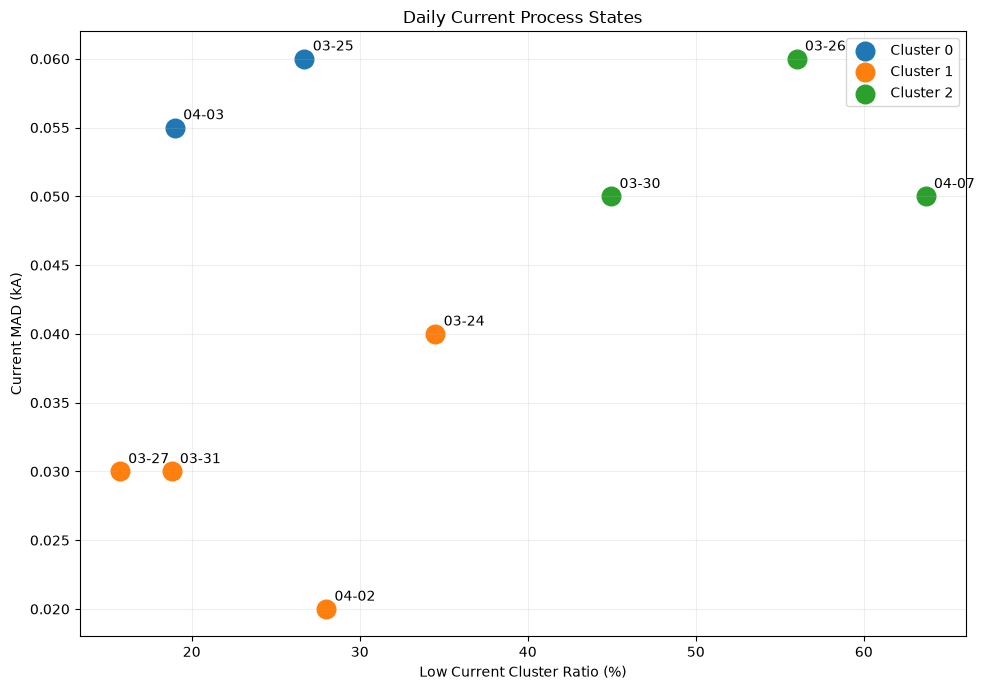

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for cluster in sorted(result["Process_Cluster"].unique()):

    temp = result[result["Process_Cluster"] == cluster]

    plt.scatter(
        temp["Low_Current_Cluster_Ratio"],
        temp["Current_MAD"],
        s=180,
        label=f"Cluster {cluster}"
    )

    for date, row in temp.iterrows():
        plt.annotate(
            str(date)[5:],
            (
                row["Low_Current_Cluster_Ratio"],
                row["Current_MAD"]
            ),
            xytext=(6, 6),
            textcoords="offset points"
        )

plt.xlabel("Low Current Cluster Ratio (%)")
plt.ylabel("Current MAD (kA)")
plt.title("Daily Current Process States")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

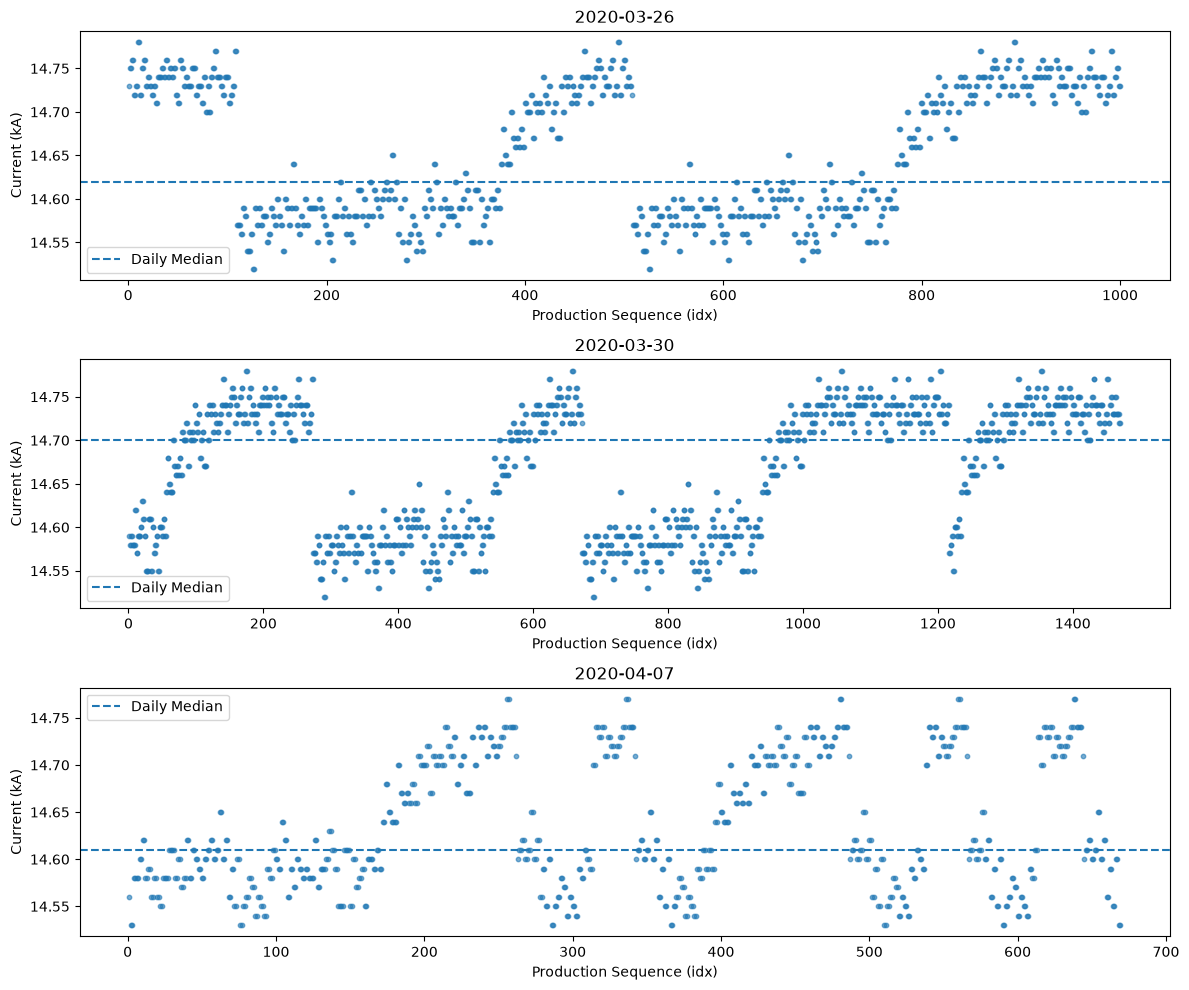

In [43]:
# 3/26, 3/30, 4/07 생산순서별 Current 확인

target_dates = [
    pd.to_datetime("2020-03-26").date(),
    pd.to_datetime("2020-03-30").date(),
    pd.to_datetime("2020-04-07").date()
]

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for ax, date in zip(axes, target_dates):

    temp = df[df["date"] == date].sort_values("idx")

    ax.scatter(
        temp["idx"],
        temp["weld current(kA)"],
        s=10,
        alpha=0.6
    )

    ax.axhline(
        temp["weld current(kA)"].median(),
        linestyle="--",
        label="Daily Median"
    )

    ax.set_title(str(date))
    ax.set_xlabel("Production Sequence (idx)")
    ax.set_ylabel("Current (kA)")
    ax.legend()

plt.tight_layout()
plt.show()

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# 1. 저전류 / 고전류 기준 자동 설정
# 이전 Current-Voltage K-means의 군집 평균 이용
# =====================================================

cluster_current_mean = (
    model_df.groupby("Cluster")["weld current(kA)"].mean()
)

# Voltage 이상군(Cluster 2 같은 극소수 군집)은 제외하고
# 행 수가 많은 2개 군집 선택
large_clusters = (
    model_df["Cluster"]
    .value_counts()
    .nlargest(2)
    .index
)

means = cluster_current_mean.loc[large_clusters].sort_values()

low_center = means.iloc[0]
high_center = means.iloc[1]

threshold = (low_center + high_center) / 2

print("Low Current Center :", round(low_center, 4))
print("High Current Center:", round(high_center, 4))
print("Threshold          :", round(threshold, 4))


# =====================================================
# 2. 모든 행을 생산순서대로 LOW / HIGH 분류
# =====================================================

analysis_df = df.dropna(
    subset=["date", "idx", "weld current(kA)"]
).copy()

analysis_df = analysis_df.sort_values(["date", "idx"])

analysis_df["Current_State"] = np.where(
    analysis_df["weld current(kA)"] < threshold,
    "LOW",
    "HIGH"
)


# =====================================================
# 3. 날짜별 전환 횟수 + 저전류 비율 + 지속구간 계산
# =====================================================

results = []

for date, temp in analysis_df.groupby("date"):

    temp = temp.sort_values("idx").copy()

    # 이전 행과 상태가 달라졌는지
    temp["State_Change"] = (
        temp["Current_State"] != temp["Current_State"].shift()
    )

    # 첫 행은 전환으로 세지 않음
    temp.iloc[0, temp.columns.get_loc("State_Change")] = False

    transition_count = temp["State_Change"].sum()

    # 저전류 행 비율
    low_ratio = (
        (temp["Current_State"] == "LOW").mean() * 100
    )

    # 연속된 LOW/HIGH 구간 번호
    temp["Run"] = (
        temp["Current_State"] != temp["Current_State"].shift()
    ).cumsum()

    # LOW 구간들의 길이
    low_runs = (
        temp[temp["Current_State"] == "LOW"]
        .groupby("Run")
        .size()
    )

    mean_low_run = low_runs.mean() if len(low_runs) else 0
    max_low_run = low_runs.max() if len(low_runs) else 0

    results.append({
        "Date": date,
        "Low_Current_Ratio": low_ratio,
        "Transition_Count": transition_count,
        "Mean_Low_Run": mean_low_run,
        "Max_Low_Run": max_low_run
    })


result = pd.DataFrame(results).set_index("Date")

print("\n=== 날짜별 전류 상태 분석 ===")
print(result.round(2))

Low Current Center : 14.5864
High Current Center: 14.7494
Threshold          : 14.6679

=== 날짜별 전류 상태 분석 ===
            Low_Current_Ratio  Transition_Count  Mean_Low_Run  Max_Low_Run
Date                                                                      
2020-03-24              34.50                13         59.14          398
2020-03-25              20.78                11         46.83          268
2020-03-26              56.00                20         56.00          268
2020-03-27              12.86                 3        106.00          210
2020-03-30              44.97                39         33.05          268
2020-03-31              15.67                12         47.00          268
2020-04-02              28.00                32         35.00          268
2020-04-03              11.88                 1         95.00           95
2020-04-07              63.68                26         30.43          173


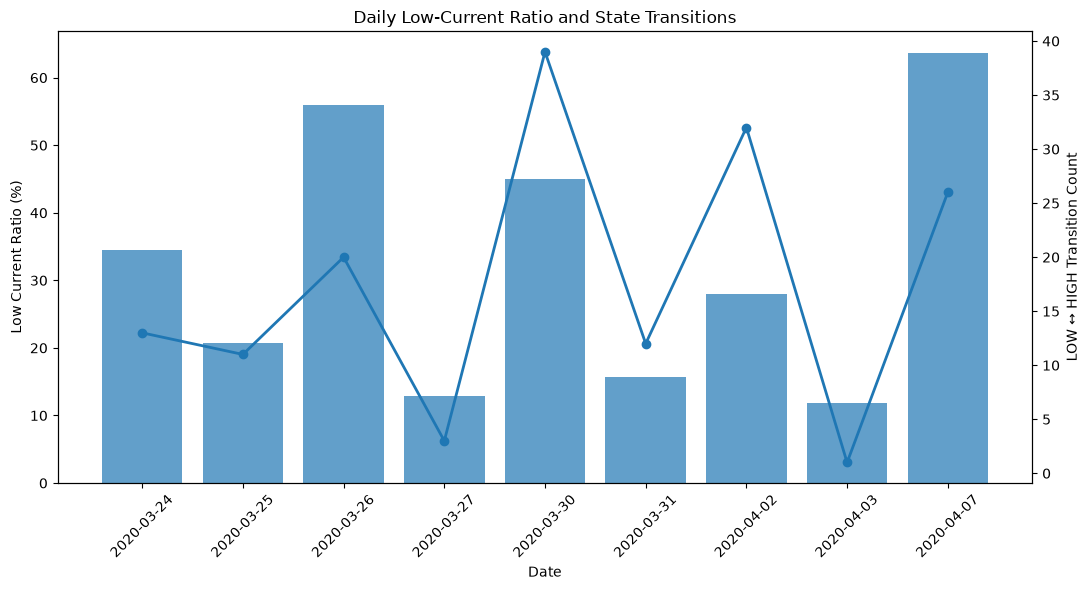

            Low_Current_Ratio  Transition_Count  Mean_Low_Run  Max_Low_Run
Date                                                                      
2020-03-24          34.500000                13     59.142857          398
2020-03-25          20.784024                11     46.833333          268
2020-03-26          56.000000                20     56.000000          268
2020-03-27          12.864078                 3    106.000000          210
2020-03-30          44.965986                39     33.050000          268
2020-03-31          15.666667                12     47.000000          268
2020-04-02          28.000000                32     35.000000          268
2020-04-03          11.875000                 1     95.000000           95
2020-04-07          63.677130                26     30.428571          173


In [46]:
fig, ax1 = plt.subplots(figsize=(11, 6))

dates = [str(x) for x in result.index]

# 저전류 비율
ax1.bar(
    dates,
    result["Low_Current_Ratio"],
    alpha=0.7,
    label="Low Current Ratio"
)

ax1.set_ylabel("Low Current Ratio (%)")
ax1.set_xlabel("Date")

# 전환 횟수
ax2 = ax1.twinx()

ax2.plot(
    dates,
    result["Transition_Count"],
    marker="o",
    linewidth=2,
    label="Transition Count"
)

ax2.set_ylabel("LOW ↔ HIGH Transition Count")

plt.title("Daily Low-Current Ratio and State Transitions")

ax1.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(result)

            N_Rows  Low_Current_Ratio  Transition_Count  Transition_Rate  \
Date                                                                       
2020-03-24    1200              34.50                13             1.08   
2020-03-25    1352              20.78                11             0.81   
2020-03-26    1000              56.00                20             2.00   
2020-03-27    1648              12.86                 3             0.18   
2020-03-30    1470              44.97                39             2.65   
2020-03-31    1800              15.67                12             0.67   
2020-04-02    2000              28.00                32             1.60   
2020-04-03     800              11.88                 1             0.13   
2020-04-07     669              63.68                26             3.89   

            Mean_Low_Run  Max_Low_Run  
Date                                   
2020-03-24         59.14          398  
2020-03-25         46.83          268  
202

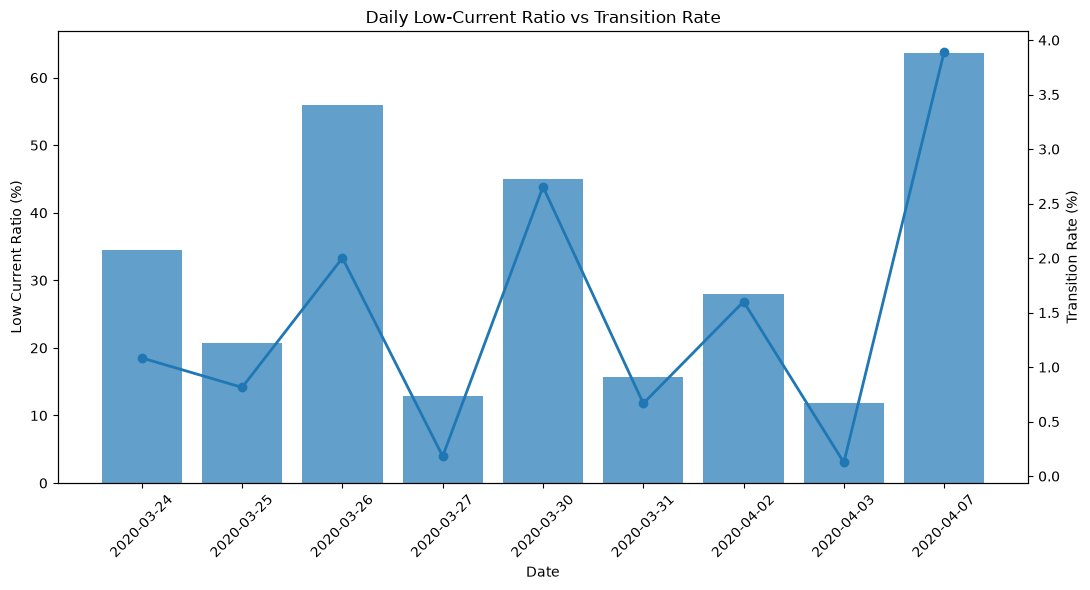

In [47]:
# 생산량 차이를 보정한 전환율(%)
daily_n = analysis_df.groupby("date").size()

result["N_Rows"] = daily_n

result["Transition_Rate"] = (
    result["Transition_Count"]
    / (result["N_Rows"] - 1)
    * 100
)

print(
    result[
        [
            "N_Rows",
            "Low_Current_Ratio",
            "Transition_Count",
            "Transition_Rate",
            "Mean_Low_Run",
            "Max_Low_Run"
        ]
    ].round(2)
)

# 그래프
fig, ax1 = plt.subplots(figsize=(11, 6))

dates = [str(x) for x in result.index]

ax1.bar(
    dates,
    result["Low_Current_Ratio"],
    alpha=0.7
)

ax1.set_ylabel("Low Current Ratio (%)")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()

ax2.plot(
    dates,
    result["Transition_Rate"],
    marker="o",
    linewidth=2
)

ax2.set_ylabel("Transition Rate (%)")

plt.title("Daily Low-Current Ratio vs Transition Rate")
ax1.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

=== Spearman Correlation ===
                   Current_MAD  Low_Current_Ratio  Transition_Rate  \
Current_MAD              1.000              0.228            0.127   
Low_Current_Ratio        0.228              1.000            0.967   
Transition_Rate          0.127              0.967            1.000   
Mean_Low_Run            -0.025             -0.667           -0.800   
Max_Low_Run             -0.139              0.292            0.237   

                   Mean_Low_Run  Max_Low_Run  
Current_MAD              -0.025       -0.139  
Low_Current_Ratio        -0.667        0.292  
Transition_Rate          -0.800        0.237  
Mean_Low_Run              1.000       -0.091  
Max_Low_Run              -0.091        1.000  


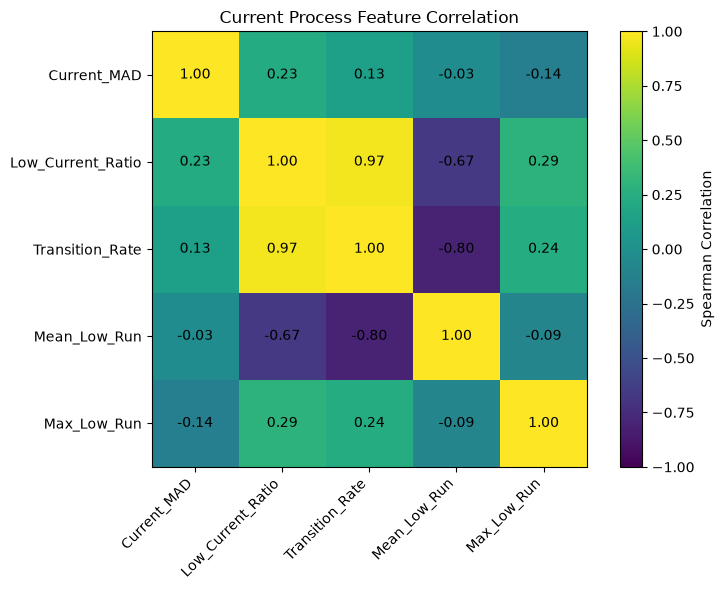

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Current MAD 추가
result["Current_MAD"] = daily_mad

# 비교할 변수
cols = [
    "Current_MAD",
    "Low_Current_Ratio",
    "Transition_Rate",
    "Mean_Low_Run",
    "Max_Low_Run"
]

# 상관계수
corr = result[cols].corr(method="spearman")

print("=== Spearman Correlation ===")
print(corr.round(3))


# 상관관계 시각화
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    corr,
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))

ax.set_xticklabels(cols, rotation=45, ha="right")
ax.set_yticklabels(cols)

# 숫자 표시
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(im, label="Spearman Correlation")
plt.title("Current Process Feature Correlation")

plt.tight_layout()
plt.show()

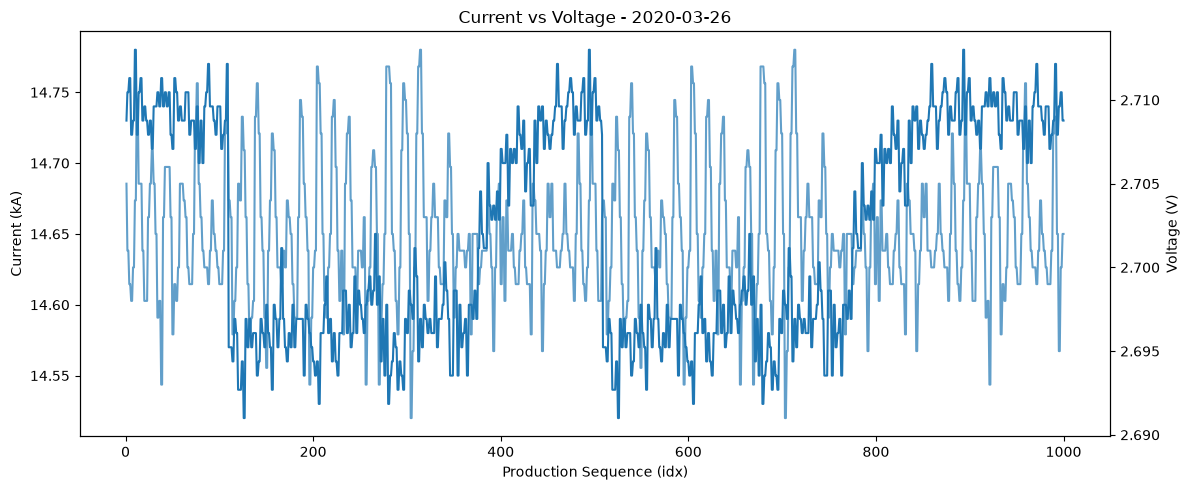

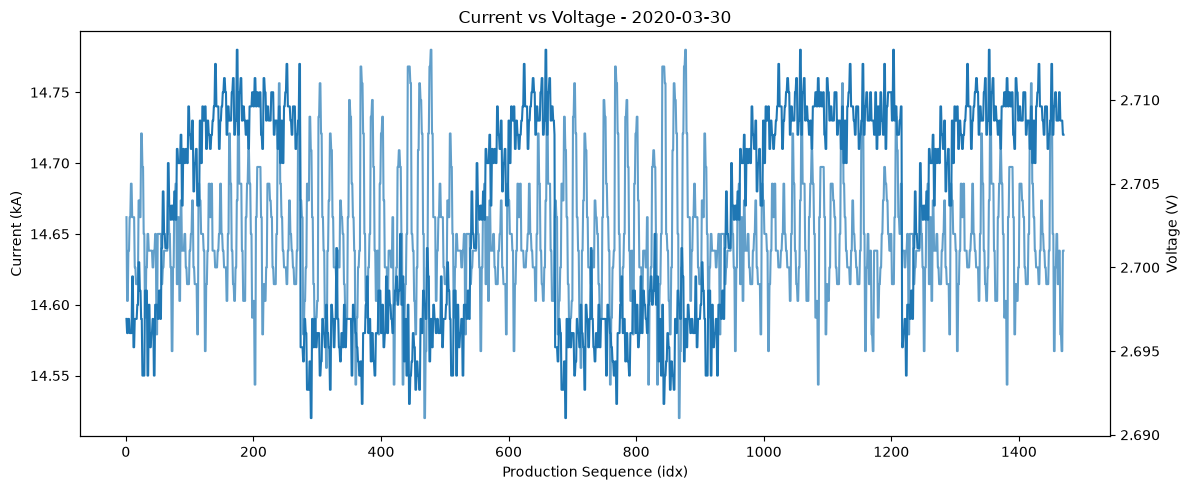

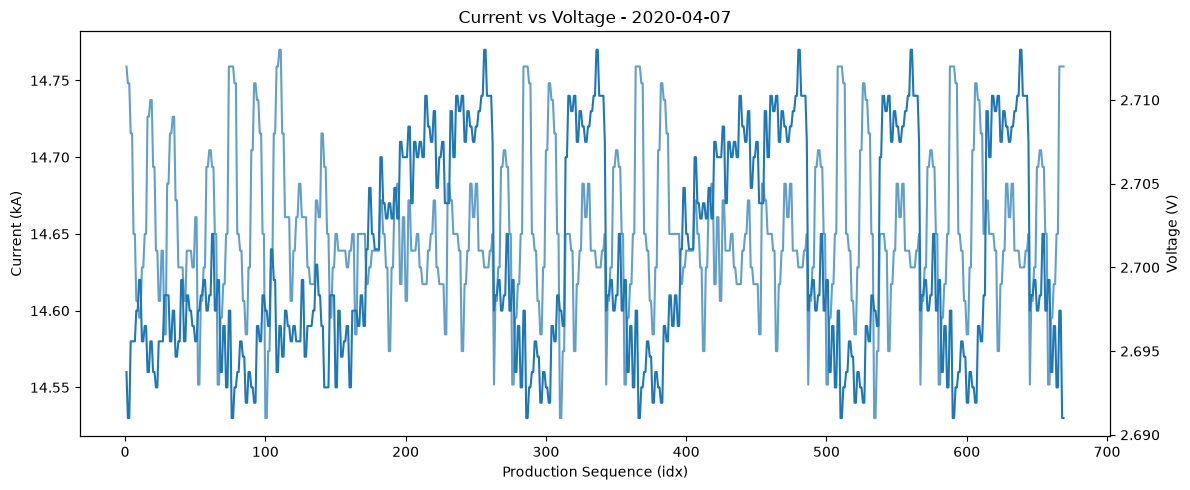

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# 날짜 + 생산순서 정렬
plot_df = df.dropna(
    subset=["date", "idx", "weld current(kA)", "weld Voltage(v)"]
).copy()

plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df = plot_df.sort_values(["date", "idx"])

# 우선 확인할 날짜
dates = ["2020-03-26", "2020-03-30", "2020-04-07"]

for date in dates:

    temp = plot_df[
        plot_df["date"] == pd.to_datetime(date)
    ].copy()

    fig, ax1 = plt.subplots(figsize=(12, 5))

    # Current
    ax1.plot(
        temp["idx"],
        temp["weld current(kA)"],
        label="Current"
    )

    ax1.set_xlabel("Production Sequence (idx)")
    ax1.set_ylabel("Current (kA)")

    # Voltage용 두 번째 Y축
    ax2 = ax1.twinx()

    ax2.plot(
        temp["idx"],
        temp["weld Voltage(v)"],
        alpha=0.7,
        label="Voltage"
    )

    ax2.set_ylabel("Voltage (V)")

    plt.title(f"Current vs Voltage - {date}")
    plt.tight_layout()
    plt.show()

In [50]:
from scipy.stats import pearsonr, spearmanr
import pandas as pd

results = []

for date, temp in plot_df.groupby("date"):

    temp = temp.dropna(
        subset=["weld current(kA)", "weld Voltage(v)"]
    )

    pearson_r, pearson_p = pearsonr(
        temp["weld current(kA)"],
        temp["weld Voltage(v)"]
    )

    spearman_r, spearman_p = spearmanr(
        temp["weld current(kA)"],
        temp["weld Voltage(v)"]
    )

    results.append({
        "Date": date,
        "Pearson": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman": spearman_r,
        "Spearman_p": spearman_p
    })

corr_result = pd.DataFrame(results)

print(corr_result.round(4))

        Date  Pearson  Pearson_p  Spearman  Spearman_p
0 2020-03-24  -0.0902     0.0018   -0.1114      0.0001
1 2020-03-25   0.1392     0.0000    0.1390      0.0000
2 2020-03-26  -0.1259     0.0001   -0.1256      0.0001
3 2020-03-27   0.1343     0.0000    0.0750      0.0023
4 2020-03-30  -0.1141     0.0000   -0.0932      0.0003
5 2020-03-31   0.1378     0.0000    0.0872      0.0002
6 2020-04-02  -0.0572     0.0105   -0.0685      0.0022
7 2020-04-03   0.1267     0.0003    0.1732      0.0000
8 2020-04-07  -0.2317     0.0000   -0.2011      0.0000


C:\Users\sj789\AppData\Local\Temp\ipykernel_2116\444862009.py:32: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(corr_result.round(4))


=== Daily Voltage Statistics ===
            Voltage_Median  Voltage_MAD
date                                   
2020-03-24           2.702        0.003
2020-03-25           2.702        0.004
2020-03-26           2.701        0.002
2020-03-27           2.703        0.004
2020-03-30           2.701        0.002
2020-03-31           2.702        0.004
2020-04-02           2.702        0.003
2020-04-03           2.703        0.006
2020-04-07           2.701        0.002


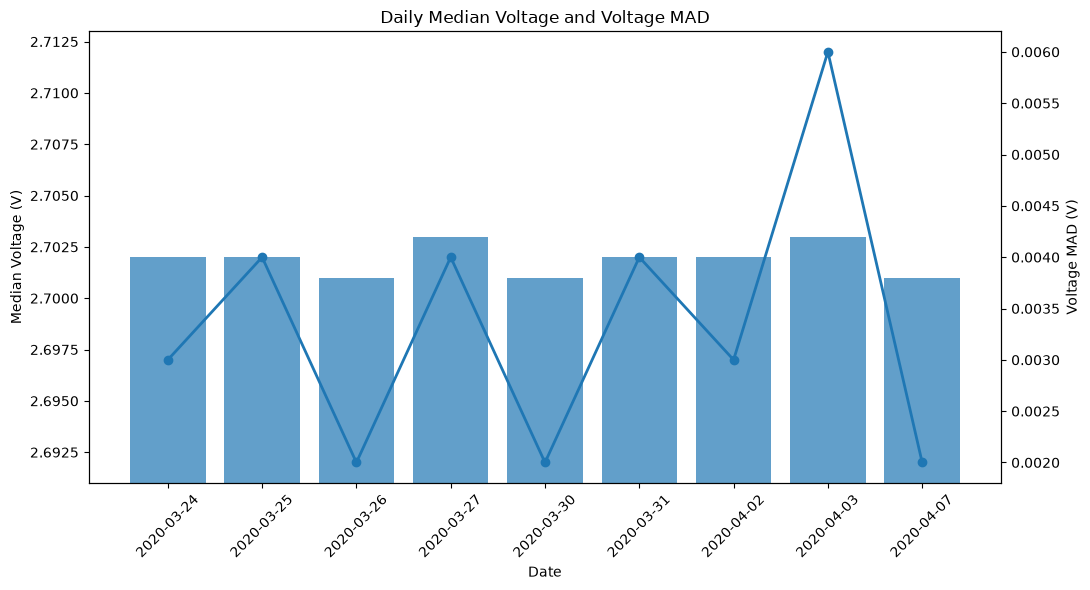

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 날짜 형식
df["date"] = pd.to_datetime(df["date"])

# MAD 함수
def mad(x):
    median = x.median()
    return np.median(np.abs(x - median))

# 날짜별 Voltage 중앙값 + MAD
voltage_daily = df.groupby("date")["weld Voltage(v)"].agg(
    Voltage_Median="median",
    Voltage_MAD=mad
)

print("=== Daily Voltage Statistics ===")
print(voltage_daily.round(4))


# 그래프
fig, ax1 = plt.subplots(figsize=(11, 6))

dates = voltage_daily.index.strftime("%Y-%m-%d")

# Voltage 중앙값
ax1.bar(
    dates,
    voltage_daily["Voltage_Median"],
    alpha=0.7
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Median Voltage (V)")
ax1.set_ylim(
    voltage_daily["Voltage_Median"].min() - 0.01,
    voltage_daily["Voltage_Median"].max() + 0.01
)

# Voltage MAD
ax2 = ax1.twinx()

ax2.plot(
    dates,
    voltage_daily["Voltage_MAD"],
    marker="o",
    linewidth=2
)

ax2.set_ylabel("Voltage MAD (V)")

plt.title("Daily Median Voltage and Voltage MAD")
ax1.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

            Current_MAD  Voltage_MAD
date                                
2020-03-24        0.040        0.003
2020-03-25        0.060        0.004
2020-03-26        0.060        0.002
2020-03-27        0.030        0.004
2020-03-30        0.050        0.002
2020-03-31        0.030        0.004
2020-04-02        0.020        0.003
2020-04-03        0.055        0.006
2020-04-07        0.050        0.002

=== Current MAD vs Voltage MAD ===
Pearson  : -0.043  (p=0.912)
Spearman : -0.156  (p=0.689)


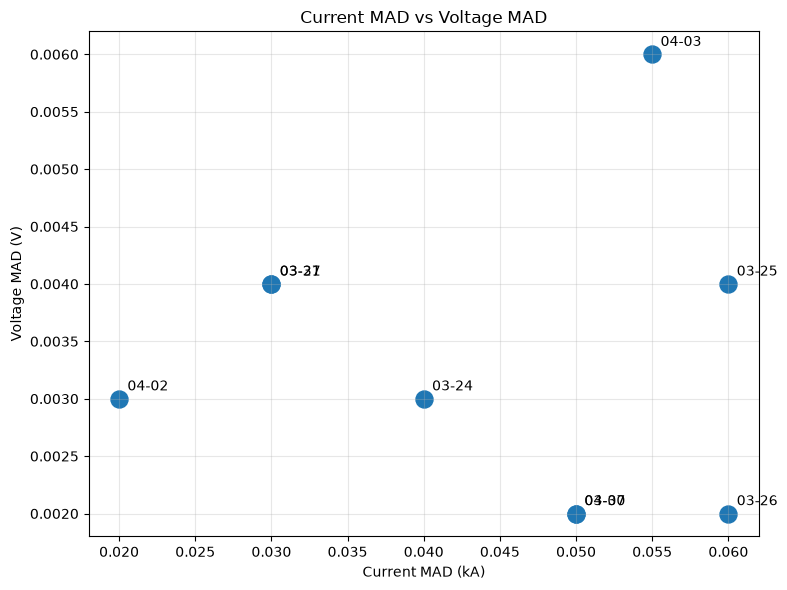

In [52]:
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# MAD 함수
def mad(x):
    med = x.median()
    return np.median(np.abs(x - med))

# 날짜별 Current MAD / Voltage MAD
mad_compare = df.groupby("date").agg(
    Current_MAD=("weld current(kA)", mad),
    Voltage_MAD=("weld Voltage(v)", mad)
)

# 상관계수
pearson_r, pearson_p = pearsonr(
    mad_compare["Current_MAD"],
    mad_compare["Voltage_MAD"]
)

spearman_r, spearman_p = spearmanr(
    mad_compare["Current_MAD"],
    mad_compare["Voltage_MAD"]
)

print(mad_compare.round(4))

print("\n=== Current MAD vs Voltage MAD ===")
print(f"Pearson  : {pearson_r:.3f}  (p={pearson_p:.3f})")
print(f"Spearman : {spearman_r:.3f}  (p={spearman_p:.3f})")


# 그래프
plt.figure(figsize=(8, 6))

plt.scatter(
    mad_compare["Current_MAD"],
    mad_compare["Voltage_MAD"],
    s=150
)

# 날짜 표시
for date, row in mad_compare.iterrows():

    plt.annotate(
        pd.to_datetime(date).strftime("%m-%d"),
        (
            row["Current_MAD"],
            row["Voltage_MAD"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Current MAD (kA)")
plt.ylabel("Voltage MAD (V)")
plt.title("Current MAD vs Voltage MAD")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

=== Daily Resistance ===
            Resistance_Median  Resistance_MAD
date                                         
2020-03-24           0.183639        0.000605
2020-03-25           0.183537        0.000981
2020-03-26           0.184565        0.000927
2020-03-27           0.183379        0.000632
2020-03-30           0.183924        0.000749
2020-03-31           0.183435        0.000644
2020-04-02           0.183571        0.000509
2020-04-03           0.183311        0.001366
2020-04-07           0.184710        0.000867


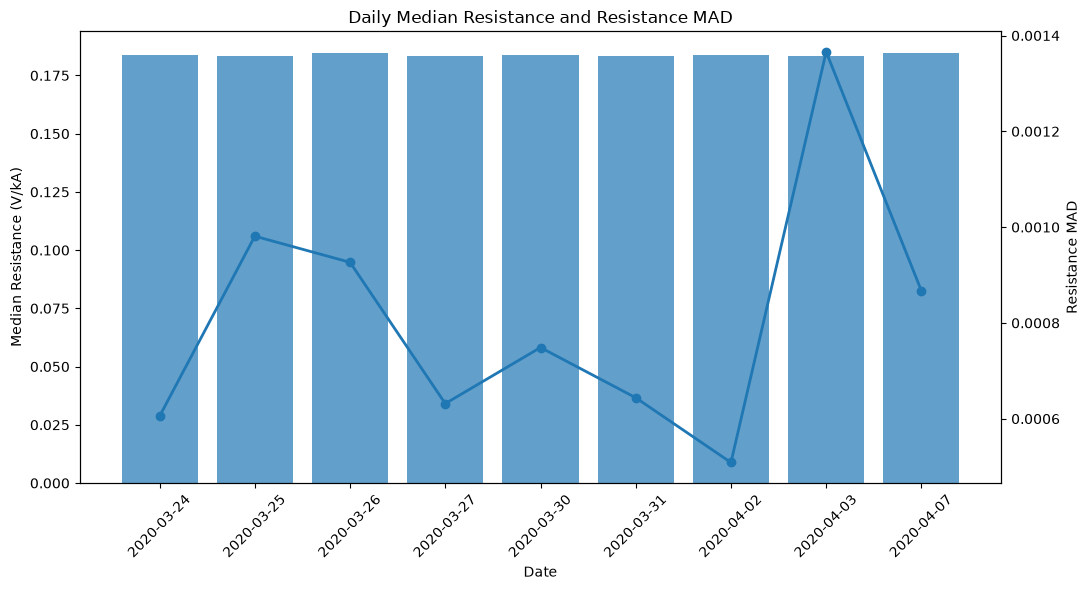

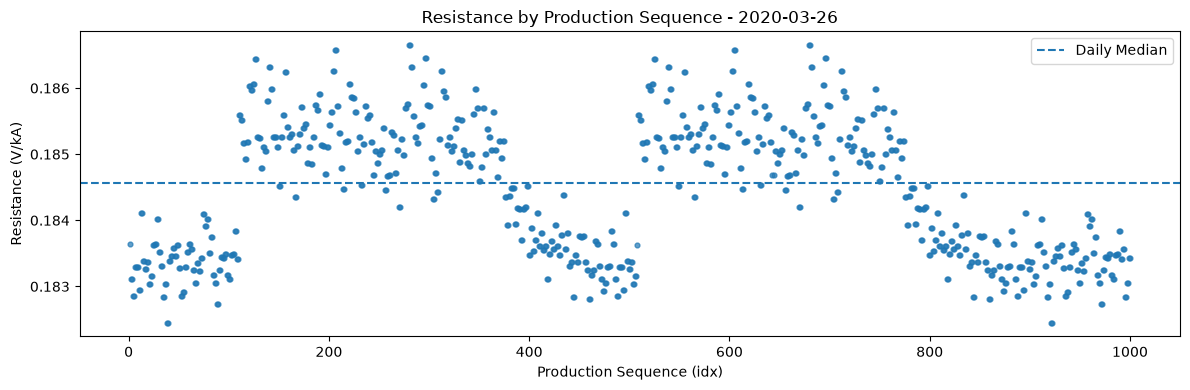

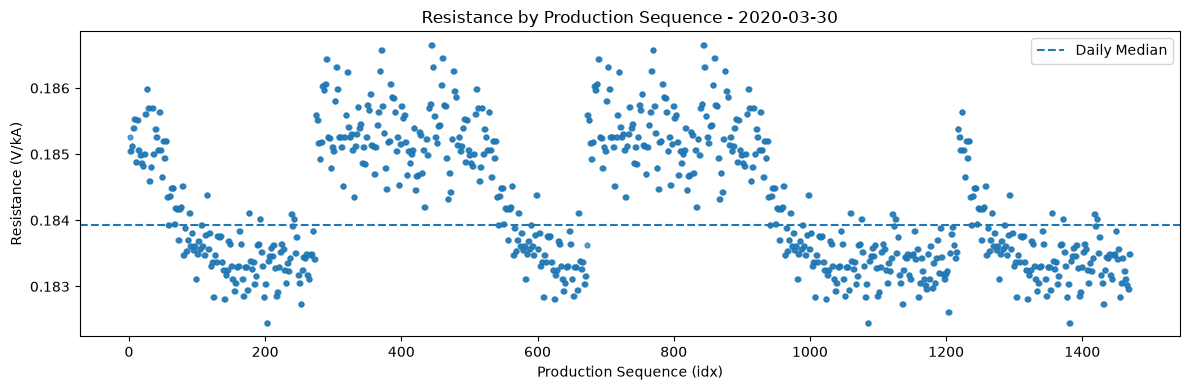

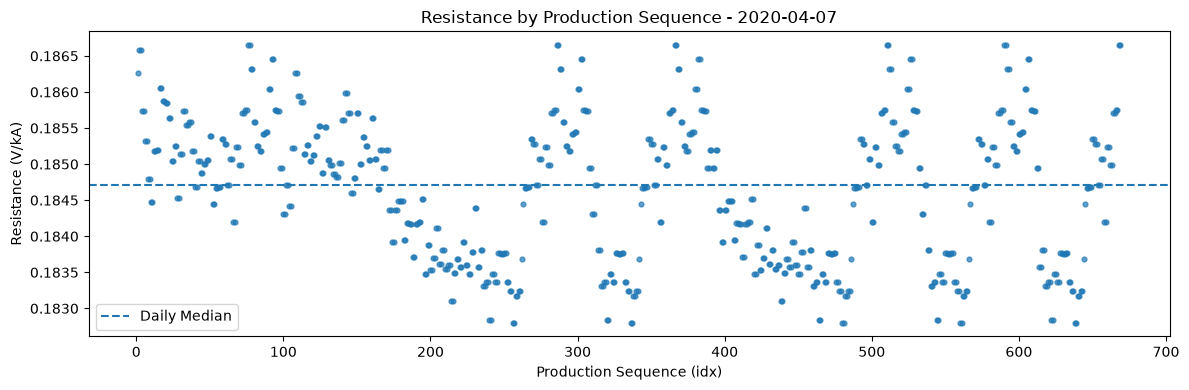

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Resistance 파생변수 생성
# R = V / I
# ==========================================

df["Resistance"] = (
    df["weld Voltage(v)"] /
    df["weld current(kA)"]
)


# ==========================================
# 2. MAD 함수
# ==========================================

def mad(x):
    median = x.median()
    return np.median(np.abs(x - median))


# ==========================================
# 3. 날짜별 Resistance 중앙값 + MAD
# ==========================================

resistance_daily = df.groupby("date")["Resistance"].agg(
    Resistance_Median="median",
    Resistance_MAD=mad
)

print("=== Daily Resistance ===")
print(resistance_daily.round(6))


# ==========================================
# 4. 날짜별 Resistance 중앙값 + MAD 그래프
# ==========================================

fig, ax1 = plt.subplots(figsize=(11, 6))

dates = pd.to_datetime(
    resistance_daily.index
).strftime("%Y-%m-%d")

# 중앙값
ax1.bar(
    dates,
    resistance_daily["Resistance_Median"],
    alpha=0.7
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Median Resistance (V/kA)")

# MAD
ax2 = ax1.twinx()

ax2.plot(
    dates,
    resistance_daily["Resistance_MAD"],
    marker="o",
    linewidth=2
)

ax2.set_ylabel("Resistance MAD")

plt.title("Daily Median Resistance and Resistance MAD")

ax1.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


# ==========================================
# 5. 생산순서별 Resistance
# ==========================================

target_dates = [
    "2020-03-26",
    "2020-03-30",
    "2020-04-07"
]

df["date"] = pd.to_datetime(df["date"])

for date in target_dates:

    temp = df[
        df["date"] == pd.to_datetime(date)
    ].sort_values("idx")

    plt.figure(figsize=(12, 4))

    plt.scatter(
        temp["idx"],
        temp["Resistance"],
        s=12,
        alpha=0.7
    )

    plt.axhline(
        temp["Resistance"].median(),
        linestyle="--",
        label="Daily Median"
    )

    plt.xlabel("Production Sequence (idx)")
    plt.ylabel("Resistance (V/kA)")
    plt.title(f"Resistance by Production Sequence - {date}")

    plt.legend()
    plt.tight_layout()
    plt.show()

=== Current vs Resistance ===
Pearson  : -0.5241 (p=0)
Spearman : -0.7239 (p=0)


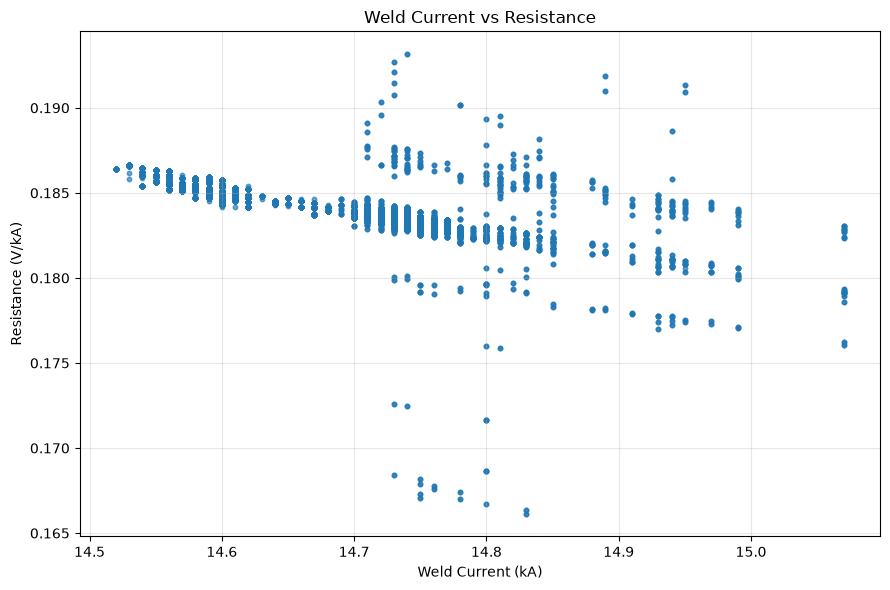

In [54]:
from scipy.stats import pearsonr, spearmanr
import pandas as pd
import matplotlib.pyplot as plt

# Current와 Resistance 결측치 제거
temp = df[
    ["weld current(kA)", "Resistance"]
].dropna()

# 전체 행 기준 상관관계
pearson_r, pearson_p = pearsonr(
    temp["weld current(kA)"],
    temp["Resistance"]
)

spearman_r, spearman_p = spearmanr(
    temp["weld current(kA)"],
    temp["Resistance"]
)

print("=== Current vs Resistance ===")
print(f"Pearson  : {pearson_r:.4f} (p={pearson_p:.4g})")
print(f"Spearman : {spearman_r:.4f} (p={spearman_p:.4g})")


# 산점도
plt.figure(figsize=(9, 6))

plt.scatter(
    temp["weld current(kA)"],
    temp["Resistance"],
    s=10,
    alpha=0.4
)

plt.xlabel("Weld Current (kA)")
plt.ylabel("Resistance (V/kA)")
plt.title("Weld Current vs Resistance")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

사용 행 개수: 11939
K=2 / Silhouette=0.7070
K=3 / Silhouette=0.7335
K=4 / Silhouette=0.6577
K=5 / Silhouette=0.6633
K=6 / Silhouette=0.6721


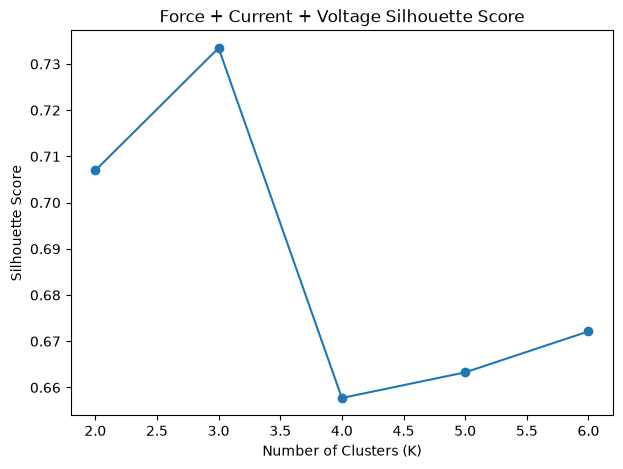


Best K = 3


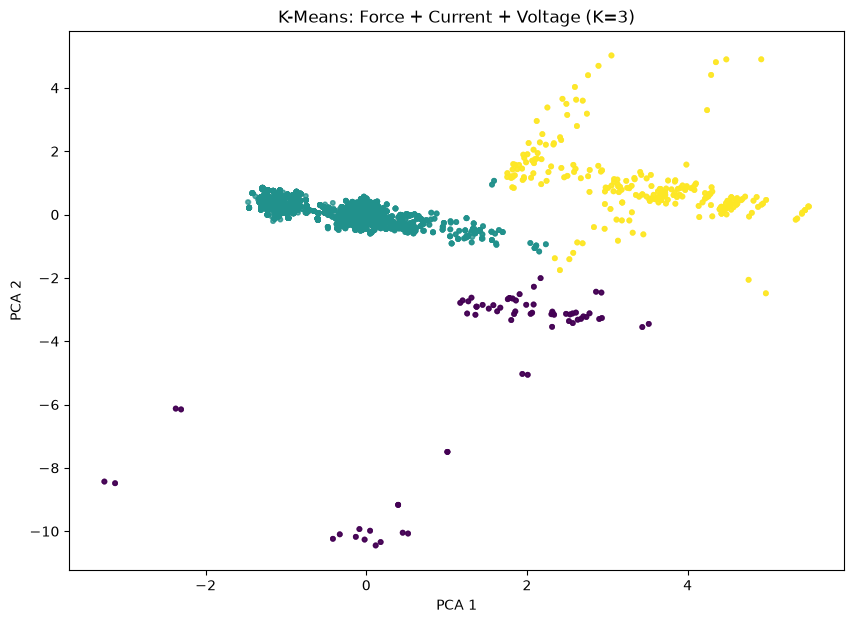


=== Cluster Count ===
Cluster
0      280
1    10743
2      916
Name: count, dtype: int64

=== Cluster Mean ===
         weld force(bar)  weld current(kA)  weld Voltage(v)
Cluster                                                    
0                 7.1956           14.8349           2.6104
1                 2.3380           14.6966           2.7022
2                 6.7173           14.8453           2.7565

=== Cluster Median ===
         weld force(bar)  weld current(kA)  weld Voltage(v)
Cluster                                                    
0                  6.875             14.80            2.651
1                  2.330             14.73            2.702
2                  7.890             14.83            2.754


In [55]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


# ==========================================
# 1. 사용할 변수
# ==========================================

features = [
    "weld force(bar)",
    "weld current(kA)",
    "weld Voltage(v)"
]

data = df[features].dropna().copy()

print("사용 행 개수:", len(data))


# ==========================================
# 2. 표준화
# ==========================================

scaler = StandardScaler()
X = scaler.fit_transform(data)


# ==========================================
# 3. K = 2~6 비교
# ==========================================

scores = []

for k in range(2, 7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    score = silhouette_score(X, labels)
    scores.append(score)

    print(f"K={k} / Silhouette={score:.4f}")


# 그래프
plt.figure(figsize=(7, 5))

plt.plot(
    range(2, 7),
    scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Force + Current + Voltage Silhouette Score")

plt.show()


# ==========================================
# 4. 가장 좋은 K 자동 선택
# ==========================================

best_k = range(2, 7)[scores.index(max(scores))]

print("\nBest K =", best_k)


# ==========================================
# 5. 최종 K-Means
# ==========================================

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

data["Cluster"] = kmeans.fit_predict(X)


# ==========================================
# 6. PCA 2차원 시각화
# ==========================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=data["Cluster"],
    s=10,
    alpha=0.5
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.title(
    f"K-Means: Force + Current + Voltage (K={best_k})"
)

plt.show()


# ==========================================
# 7. 클러스터 결과
# ==========================================

print("\n=== Cluster Count ===")
print(data["Cluster"].value_counts().sort_index())

print("\n=== Cluster Mean ===")
print(
    data.groupby("Cluster")[features]
    .mean()
    .round(4)
)

print("\n=== Cluster Median ===")
print(
    data.groupby("Cluster")[features]
    .median()
    .round(4)
)

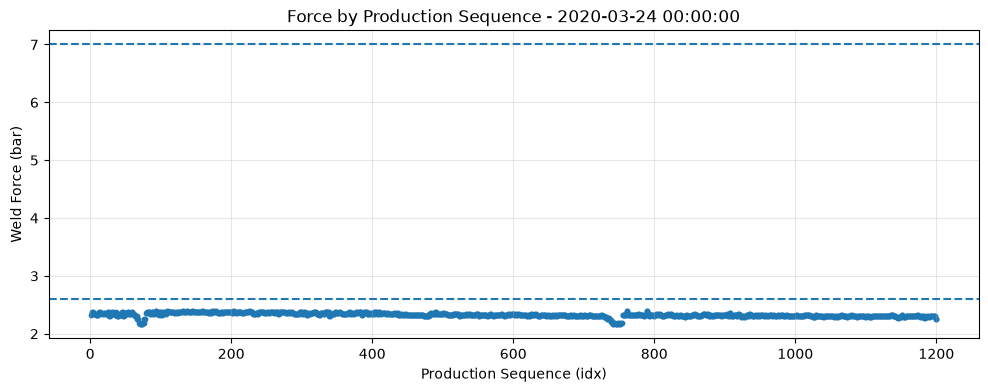

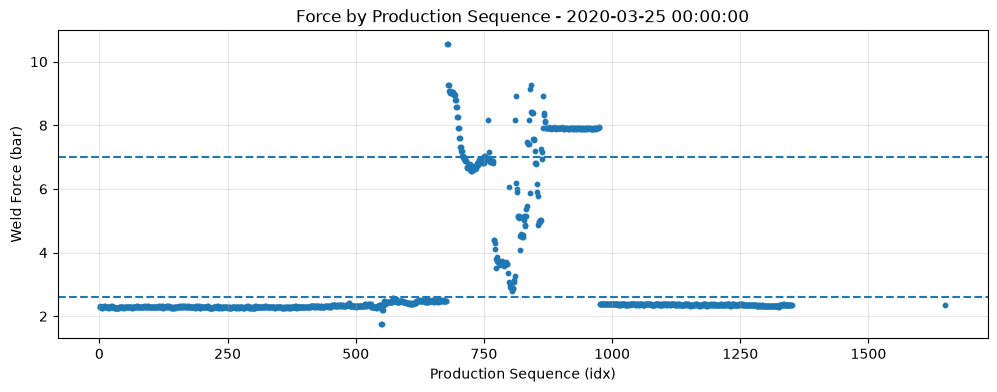

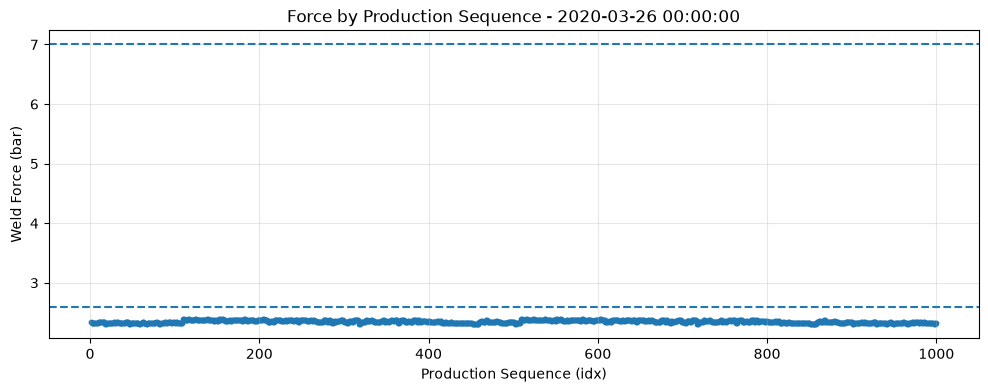

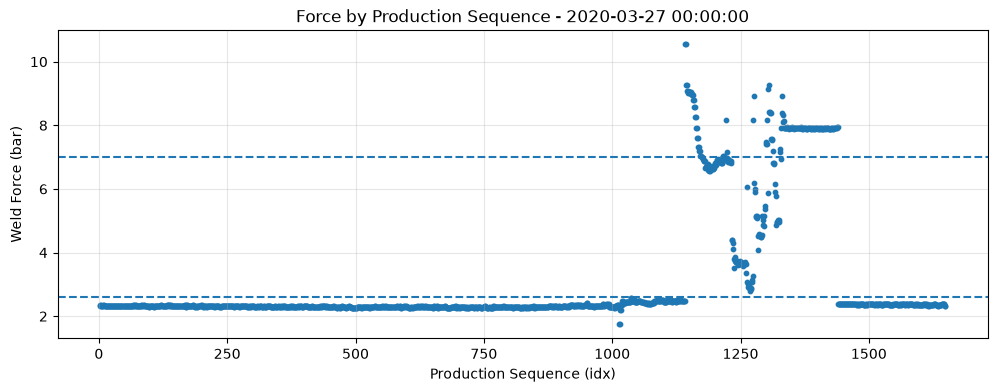

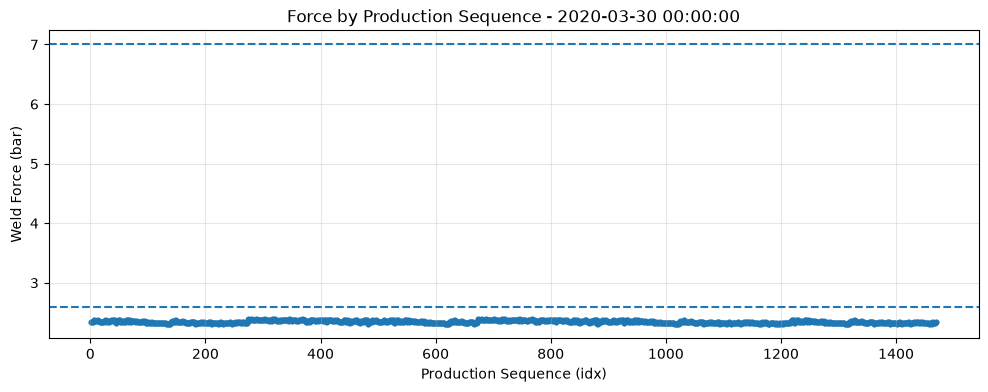

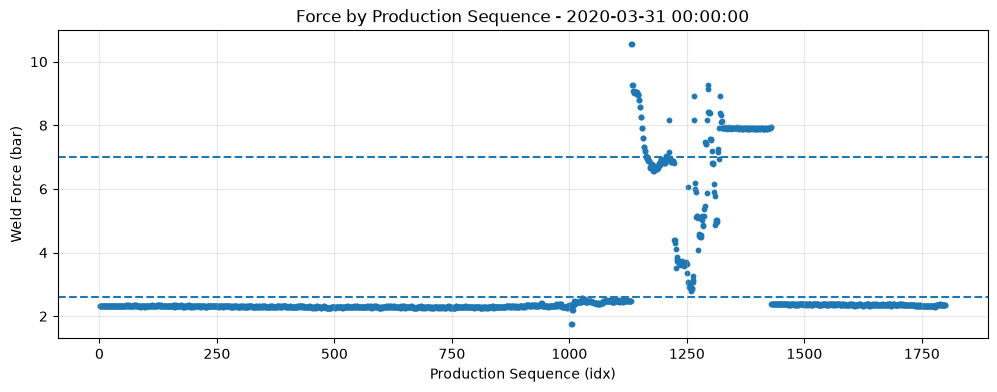

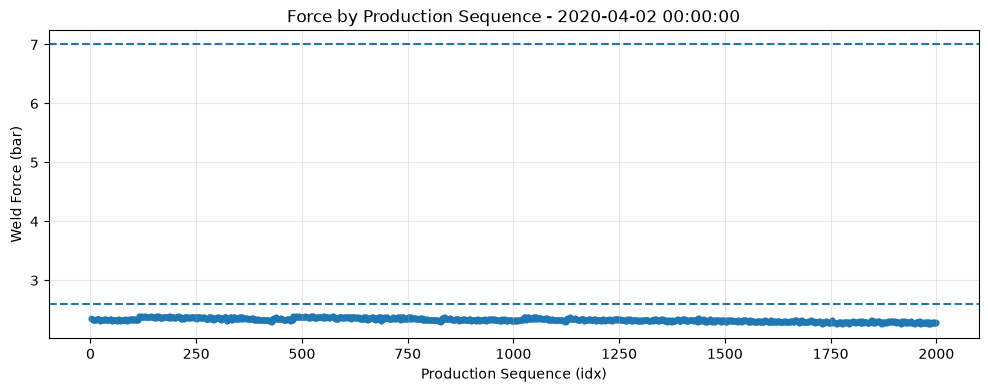

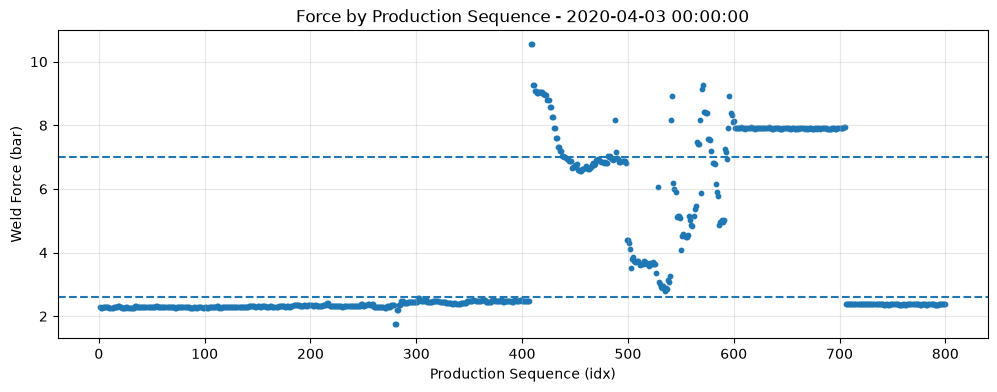

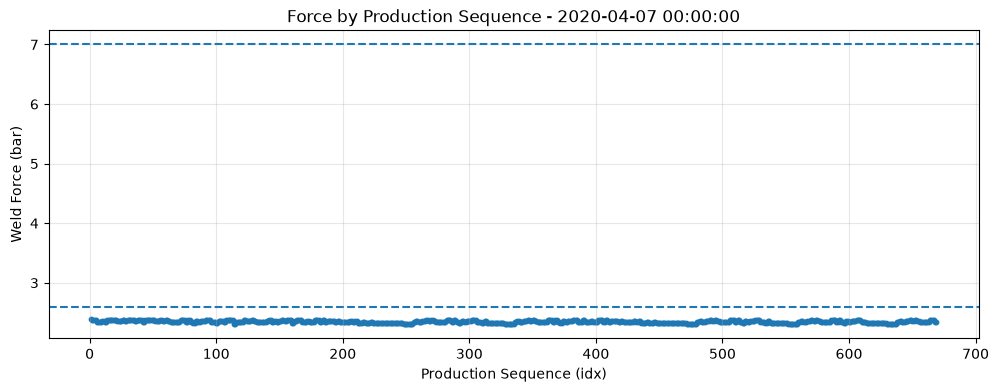

In [ ]:

# Force 7~8 bar 데이터가 무작위로 발생한 이상치가 아니라, 특정 날짜·생산구간에 연속적으로 나타나는 별도의 공정조건일 것이다.

import matplotlib.pyplot as plt

dates = sorted(df["date"].unique())

for date in dates:
    temp = df[df["date"] == date].sort_values("idx")

    plt.figure(figsize=(12, 4))

    plt.scatter(
        temp["idx"],
        temp["weld force(bar)"],
        s=10
    )

    plt.axhline(2.6, linestyle="--")
    plt.axhline(7.0, linestyle="--")

    plt.xlabel("Production Sequence (idx)")
    plt.ylabel("Weld Force (bar)")
    plt.title(f"Force by Production Sequence - {date}")

    plt.grid(alpha=0.3)
    plt.show()

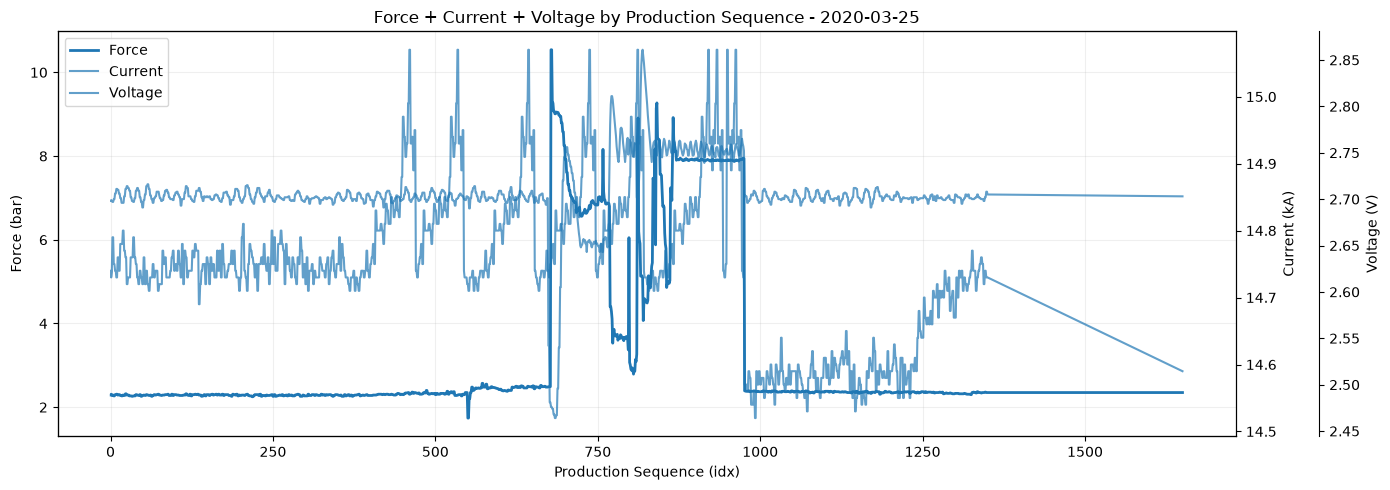

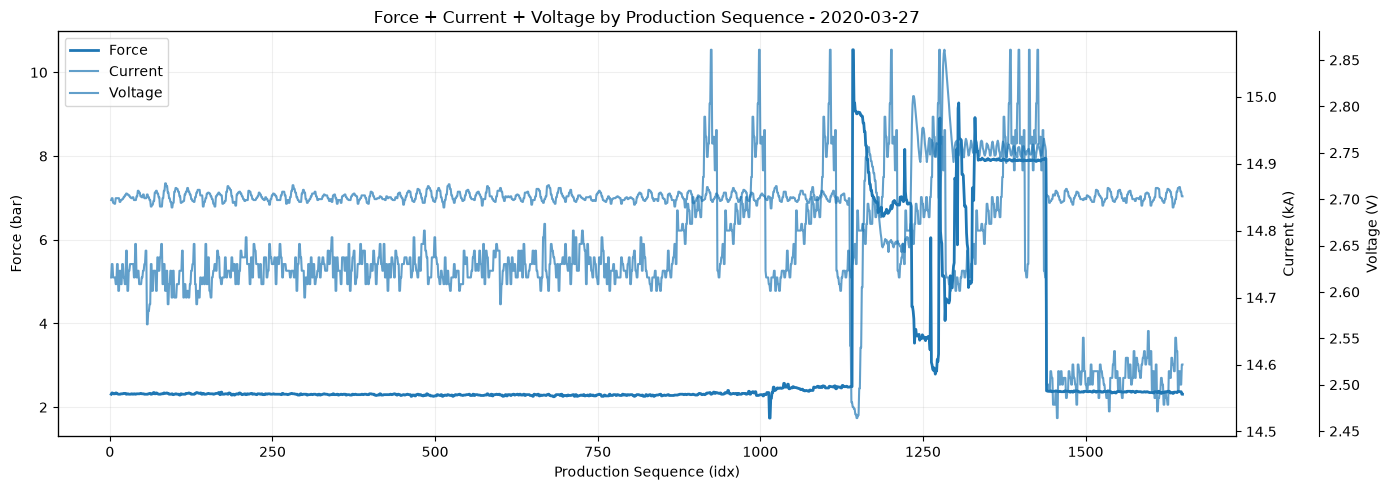

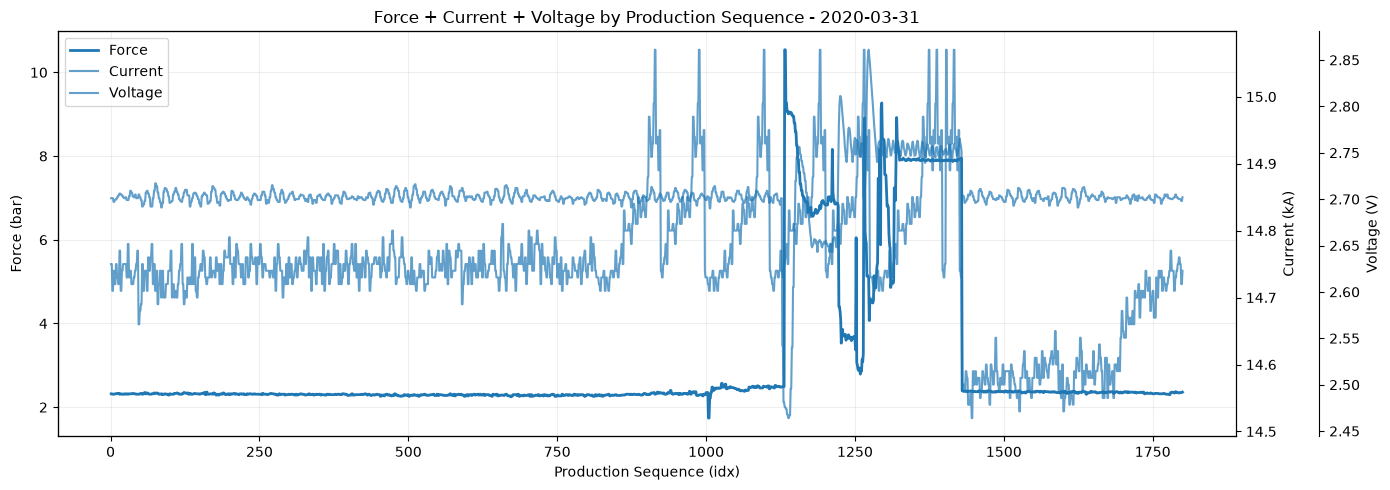

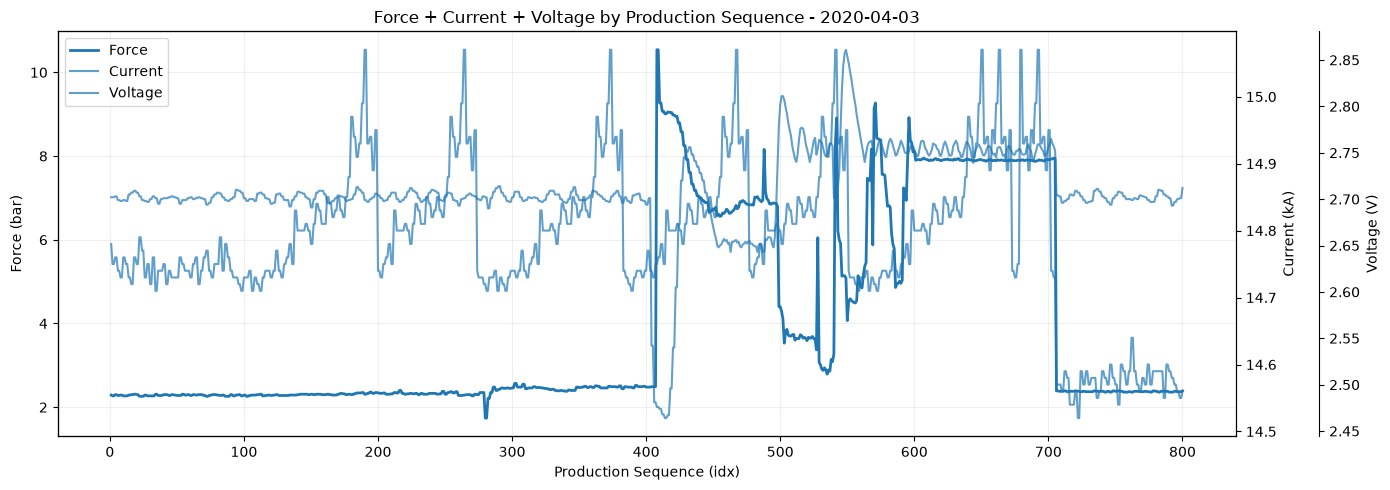

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

df["date"] = pd.to_datetime(df["date"])

target_dates = [
    "2020-03-25",
    "2020-03-27",
    "2020-03-31",
    "2020-04-03"
]

for date in target_dates:

    temp = df[
        df["date"] == pd.to_datetime(date)
    ].sort_values("idx")

    fig, ax1 = plt.subplots(figsize=(14, 5))

    # =========================
    # Force
    # =========================
    ax1.plot(
        temp["idx"],
        temp["weld force(bar)"],
        label="Force",
        linewidth=2
    )

    ax1.set_xlabel("Production Sequence (idx)")
    ax1.set_ylabel("Force (bar)")

    # =========================
    # Current
    # =========================
    ax2 = ax1.twinx()

    ax2.plot(
        temp["idx"],
        temp["weld current(kA)"],
        label="Current",
        alpha=0.7
    )

    ax2.set_ylabel("Current (kA)")

    # =========================
    # Voltage
    # =========================
    ax3 = ax1.twinx()

    # 세 번째 y축을 오른쪽으로 이동
    ax3.spines["right"].set_position(("outward", 60))

    ax3.plot(
        temp["idx"],
        temp["weld Voltage(v)"],
        label="Voltage",
        alpha=0.7
    )

    ax3.set_ylabel("Voltage (V)")

    # =========================
    # 제목
    # =========================
    plt.title(
        f"Force + Current + Voltage by Production Sequence - {date}"
    )

    # 범례
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()

    ax1.legend(
        lines1 + lines2 + lines3,
        labels1 + labels2 + labels3,
        loc="upper left"
    )

    ax1.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 데이터 불러오기
df = pd.read_excel("../YSJ-001/Welding Data Set_01.xlsx")

print(df.shape)
print(df.columns.tolist())

(11939, 10)
['idx', 'Machine_Name', 'Item No', 'working time', 'Thickness 1(mm)', 'Thickness 2(mm)', 'weld force(bar)', 'weld current(kA)', 'weld Voltage(v)', 'weld time(ms)']



Low Force (2~3 bar)
가장 강한 주기 후보: 11 rows
자기상관: 0.169


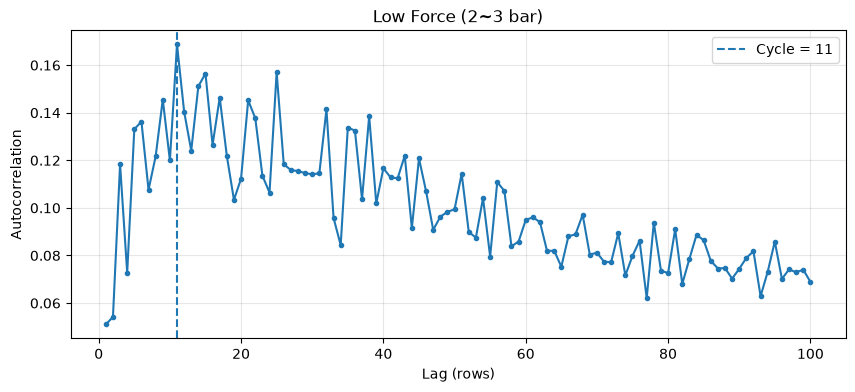


High Force (7~9 bar)
가장 강한 주기 후보: 1 rows
자기상관: 0.522


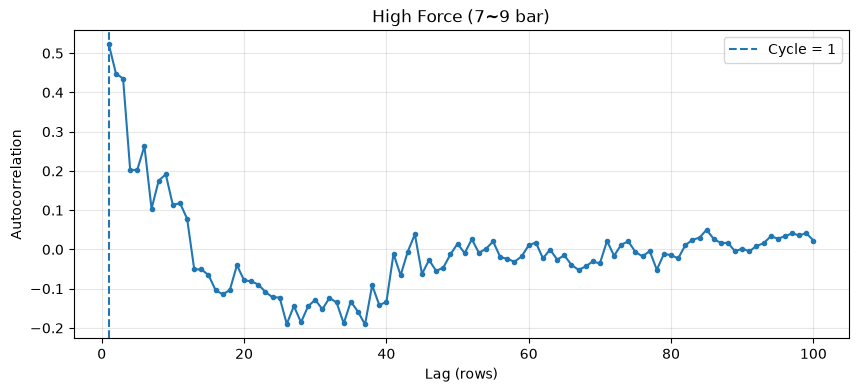

In [4]:
# 생산순서 정렬
temp = df.sort_values("idx").copy()

# 2점대 / 7~8점대 분리
low = temp[
    (temp["weld force(bar)"] >= 2) &
    (temp["weld force(bar)"] < 3)
].copy()

high = temp[
    (temp["weld force(bar)"] >= 7) &
    (temp["weld force(bar)"] < 9)
].copy()


def cycle_analysis(data, name):

    force = data["weld force(bar)"].reset_index(drop=True)

    max_lag = min(100, len(force)//2)

    correlations = []

    for lag in range(1, max_lag + 1):
        correlations.append(force.autocorr(lag=lag))

    best_lag = np.nanargmax(correlations) + 1

    print(f"\n{name}")
    print("가장 강한 주기 후보:", best_lag, "rows")
    print("자기상관:", round(correlations[best_lag-1], 3))

    plt.figure(figsize=(10,4))
    plt.plot(
        range(1, max_lag + 1),
        correlations,
        marker="o",
        markersize=3
    )

    plt.axvline(
        best_lag,
        linestyle="--",
        label=f"Cycle = {best_lag}"
    )

    plt.xlabel("Lag (rows)")
    plt.ylabel("Autocorrelation")
    plt.title(name)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


cycle_analysis(low, "Low Force (2~3 bar)")
cycle_analysis(high, "High Force (7~9 bar)")

In [5]:
import pandas as pd
import numpy as np

# idx 순서 정렬
temp = df.sort_values("idx").copy()

# High Force 정의: 7~9 bar
temp["High_Force"] = (
    (temp["weld force(bar)"] >= 7) &
    (temp["weld force(bar)"] < 9)
)

# 연속 구간 번호 생성
temp["Block"] = (
    temp["High_Force"] != temp["High_Force"].shift()
).cumsum()

# High Force 구간만 추출
high_blocks = (
    temp[temp["High_Force"]]
    .groupby("Block")
    .agg(
        start_idx=("idx", "min"),
        end_idx=("idx", "max"),
        length=("idx", "count"),
        mean_force=("weld force(bar)", "mean"),
        median_force=("weld force(bar)", "median"),
        min_force=("weld force(bar)", "min"),
        max_force=("weld force(bar)", "max")
    )
    .reset_index(drop=True)
)

print("=== High Force 연속 생산 구간 ===")
display(high_blocks)

print("\n=== 구간 길이 통계 ===")
display(high_blocks["length"].describe())

=== High Force 연속 생산 구간 ===


,start_idx,end_idx,length,mean_force,median_force,min_force,max_force
0,420,420,1,8.98,8.98,8.98,8.98
1,421,421,1,8.98,8.98,8.98,8.98
2,422,422,1,8.95,8.95,8.95,8.95
3,423,423,1,8.95,8.95,8.95,8.95
4,424,424,1,8.79,8.79,8.79,8.79
...,...,...,...,...,...,...,...
521,1435,1435,1,7.92,7.92,7.92,7.92
522,1436,1436,1,7.93,7.93,7.93,7.93
523,1437,1437,1,7.93,7.93,7.93,7.93
524,1438,1438,1,7.95,7.95,7.95,7.95



=== 구간 길이 통계 ===


count    526.000000
mean       1.171103
std        0.491064
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        4.000000
Name: length, dtype: float64

In [6]:
print(df.columns.tolist())

['idx', 'Machine_Name', 'Item No', 'working time', 'Thickness 1(mm)', 'Thickness 2(mm)', 'weld force(bar)', 'weld current(kA)', 'weld Voltage(v)', 'weld time(ms)']


In [7]:
import pandas as pd
import numpy as np

temp = df.copy()

# working time → 날짜 추출
temp["Date"] = pd.to_datetime(temp["working time"]).dt.date

# 날짜 + 생산순서 정렬
temp = temp.sort_values(["Date", "idx"]).copy()

# High Force: 7~9 bar
temp["High"] = (
    (temp["weld force(bar)"] >= 7) &
    (temp["weld force(bar)"] < 9)
)

all_blocks = []

for date, day in temp.groupby("Date"):

    day = day.sort_values("idx").copy()

    # High / Low 상태가 바뀌는 지점
    day["change"] = day["High"].ne(day["High"].shift())

    # 연속 구간 번호
    day["block"] = day["change"].cumsum()

    # High Force 구간만
    high = day[day["High"]]

    if len(high) == 0:
        continue

    blocks = (
        high.groupby("block")
        .agg(
            start_idx=("idx", "min"),
            end_idx=("idx", "max"),
            length=("idx", "count"),
            mean_force=("weld force(bar)", "mean"),
            min_force=("weld force(bar)", "min"),
            max_force=("weld force(bar)", "max")
        )
        .reset_index(drop=True)
    )

    blocks.insert(0, "Date", date)

    all_blocks.append(blocks)


# 합치기
high_blocks = pd.concat(all_blocks, ignore_index=True)

# 다음 High Force 구간까지 간격
high_blocks["next_start"] = (
    high_blocks.groupby("Date")["start_idx"].shift(-1)
)

high_blocks["gap_to_next"] = (
    high_blocks["next_start"] - high_blocks["end_idx"]
)

display(high_blocks)

,Date,start_idx,end_idx,length,mean_force,min_force,max_force,next_start,gap_to_next
0,2020-03-25,690,711,22,7.967273,7.00,8.98,751.0,40.0
1,2020-03-25,751,753,3,7.020000,7.01,7.03,758.0,5.0
2,2020-03-25,758,759,2,7.655000,7.15,8.16,811.0,52.0
3,2020-03-25,811,812,2,8.545000,8.18,8.91,835.0,23.0
4,2020-03-25,835,838,4,7.620000,7.42,8.17,842.0,4.0
5,2020-03-25,842,849,8,7.932500,7.18,8.43,862.0,13.0
6,2020-03-25,862,863,2,7.205000,7.17,7.24,865.0,2.0
7,2020-03-25,865,975,111,7.926847,7.87,8.92,NaN,NaN
8,2020-03-27,1154,1175,22,7.967273,7.00,8.98,1215.0,40.0
9,2020-03-27,1215,1217,3,7.020000,7.01,7.03,1222.0,5.0


In [8]:
import pandas as pd
import numpy as np

data = df.copy()

# --------------------------------
# 1. Force 기준으로 공정 분리
# --------------------------------

data["Process"] = np.select(
    [
        (data["weld force(bar)"] >= 2) &
        (data["weld force(bar)"] < 3),

        (data["weld force(bar)"] >= 7) &
        (data["weld force(bar)"] < 9)
    ],
    [
        "Process_A_2bar",
        "Process_B_7_8bar"
    ],
    default="Other"
)

# 두 주요 공정만 사용
process_data = data[
    data["Process"].isin([
        "Process_A_2bar",
        "Process_B_7_8bar"
    ])
].copy()


# --------------------------------
# 2. 공정별 Current 분포 확인
# --------------------------------

current_summary = (
    process_data
    .groupby("Process")["weld current(kA)"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
)

print("=== 공정별 Current ===")
display(current_summary.round(4))


# --------------------------------
# 3. 공정별 IQR로 Current 범위 계산
# --------------------------------

def current_range(group):

    q1 = group["weld current(kA)"].quantile(0.25)
    q3 = group["weld current(kA)"].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return pd.Series({
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Current": lower,
        "Upper_Current": upper
    })


current_ranges = (
    process_data
    .groupby("Process")
    .apply(current_range, include_groups=False)
)

print("\n=== 공정별 Current 정상범위 후보 ===")
display(current_ranges.round(4))

=== 공정별 Current ===


,count,mean,median,std,min,max
Process,,,,,,
Process_A_2bar,10767,14.6970,14.73,0.0892,14.52,15.07
Process_B_7_8bar,616,14.8567,14.83,0.0939,14.71,15.07



=== 공정별 Current 정상범위 후보 ===


,Q1,Q3,IQR,Lower_Current,Upper_Current
Process,,,,,
Process_A_2bar,14.6,14.75,0.15,14.375,14.975
Process_B_7_8bar,14.8,14.93,0.13,14.605,15.125


In [9]:
# --------------------------------
# 4. 공정별 Current 상태 분류
# --------------------------------

def classify_current(row):

    process = row["Process"]
    current = row["weld current(kA)"]

    lower = current_ranges.loc[process, "Lower_Current"]
    upper = current_ranges.loc[process, "Upper_Current"]

    if current < lower:
        return "Low_Current"

    elif current > upper:
        return "High_Current"

    else:
        return "Normal_Current"


process_data["Current_State"] = process_data.apply(
    classify_current,
    axis=1
)


# --------------------------------
# 5. 결과 확인
# --------------------------------

result = pd.crosstab(
    process_data["Process"],
    process_data["Current_State"]
)

print("=== 공정별 Current 상태 개수 ===")
display(result)

print("\n=== 공정별 Current 상태 비율 (%) ===")

result_ratio = pd.crosstab(
    process_data["Process"],
    process_data["Current_State"],
    normalize="index"
) * 100

display(result_ratio.round(2))

=== 공정별 Current 상태 개수 ===


Current_State,High_Current,Normal_Current
Process,,
Process_A_2bar,48,10719
Process_B_7_8bar,0,616



=== 공정별 Current 상태 비율 (%) ===


Current_State,High_Current,Normal_Current
Process,,
Process_A_2bar,0.45,99.55
Process_B_7_8bar,0.00,100.00


In [10]:
# 공정별 Current 하위 10%, 상위 10% 기준 계산
current_threshold = (
    process_data
    .groupby("Process")["weld current(kA)"]
    .quantile([0.1, 0.9])
    .unstack()
)

current_threshold.columns = ["Low_Threshold", "High_Threshold"]

display(current_threshold)


# Low / Normal / High 분류
def classify_current(row):

    process = row["Process"]
    current = row["weld current(kA)"]

    low = current_threshold.loc[process, "Low_Threshold"]
    high = current_threshold.loc[process, "High_Threshold"]

    if current <= low:
        return "Low_Current"

    elif current >= high:
        return "High_Current"

    else:
        return "Normal_Current"


process_data["Current_State"] = process_data.apply(
    classify_current,
    axis=1
)


# 결과 확인
count = pd.crosstab(
    process_data["Process"],
    process_data["Current_State"]
)

ratio = pd.crosstab(
    process_data["Process"],
    process_data["Current_State"],
    normalize="index"
) * 100

print("=== 개수 ===")
display(count)

print("=== 비율 (%) ===")
display(ratio.round(2))

,Low_Threshold,High_Threshold
Process,,
Process_A_2bar,14.57,14.78
Process_B_7_8bar,14.74,14.99


=== 개수 ===


Current_State,High_Current,Low_Current,Normal_Current
Process,,,
Process_A_2bar,1128,1162,8477
Process_B_7_8bar,64,80,472


=== 비율 (%) ===


Current_State,High_Current,Low_Current,Normal_Current
Process,,,
Process_A_2bar,10.48,10.79,78.73
Process_B_7_8bar,10.39,12.99,76.62


In [11]:
# 날짜별 공정별 Current 상태 비율 계산

# working time에서 날짜 생성
process_data["Date"] = pd.to_datetime(
    process_data["working time"]
).dt.date

# 날짜 × 공정 × Current 상태별 개수
daily_current = (
    process_data
    .groupby(["Date", "Process", "Current_State"])
    .size()
    .unstack(fill_value=0)
)

# 날짜 × 공정별 전체 개수
daily_current["Total"] = daily_current.sum(axis=1)

# 각 상태 비율(%)
for state in ["Low_Current", "Normal_Current", "High_Current"]:
    if state in daily_current.columns:
        daily_current[state + "_Rate"] = (
            daily_current[state] / daily_current["Total"] * 100
        )

daily_current = daily_current.reset_index()

display(
    daily_current[
        [
            "Date",
            "Process",
            "Total",
            "Low_Current_Rate",
            "Normal_Current_Rate",
            "High_Current_Rate"
        ]
    ].round(2)
)

Current_State,Date,Process,Total,Low_Current_Rate,Normal_Current_Rate,High_Current_Rate
0,2020-03-24,Process_A_2bar,1200,11.50,84.67,3.83
1,2020-03-25,Process_A_2bar,1059,8.88,68.18,22.95
2,2020-03-25,Process_B_7_8bar,154,12.99,76.62,10.39
3,2020-03-26,Process_A_2bar,1000,18.80,80.60,0.60
4,2020-03-27,Process_A_2bar,1355,6.05,73.95,20.00
5,2020-03-27,Process_B_7_8bar,154,12.99,76.62,10.39
6,2020-03-30,Process_A_2bar,1470,13.88,85.44,0.68
7,2020-03-31,Process_A_2bar,1507,6.24,75.78,17.98
8,2020-03-31,Process_B_7_8bar,154,12.99,76.62,10.39
9,2020-04-02,Process_A_2bar,2000,9.10,87.15,3.75


Force 2.xx 데이터 개수: 10767

=== Current 기초 통계 ===
count    10767.000000
mean        14.697036
std          0.089183
min         14.520000
25%         14.600000
50%         14.730000
75%         14.750000
max         15.070000
Name: weld current(kA), dtype: float64

Low Current 기준 : 14.570000000000002
High Current 기준: 14.78

=== Current 상태 개수 ===
Current_State
Normal_Current    8477
Low_Current       1162
High_Current      1128
Name: count, dtype: int64

=== Current 상태 비율 (%) ===
Current_State
Normal_Current    78.73
Low_Current       10.79
High_Current      10.48
Name: proportion, dtype: float64


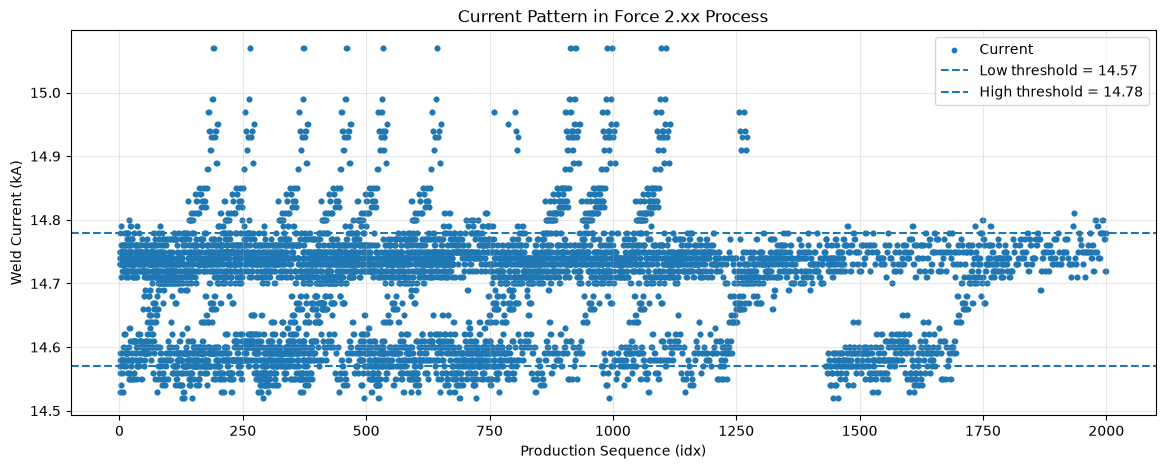

,idx,working time,weld force(bar),weld current(kA),weld Voltage(v),weld time(ms),Current_State
0,1,2020-03-24,2.33,14.57,2.701,72.0,Low_Current
2,1,2020-04-07,2.39,14.56,2.712,73.0,Low_Current
7,1,2020-04-03,2.29,14.78,2.702,71.0,High_Current
13,2,2020-03-24,2.36,14.57,2.701,72.0,Low_Current
14,2,2020-04-07,2.38,14.53,2.711,71.0,Low_Current
18,3,2020-03-24,2.37,14.54,2.703,71.0,Low_Current
24,3,2020-03-25,2.29,14.79,2.697,72.0,High_Current
25,3,2020-04-07,2.38,14.53,2.711,71.0,Low_Current
29,4,2020-03-24,2.37,14.54,2.703,72.0,Low_Current
31,4,2020-03-25,2.29,14.79,2.697,72.0,High_Current


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# 1. Force 2.xx bar 공정만 추출
# ============================================

force2 = process_data[
    process_data["Process"] == "Process_A_2bar"
].copy()

force2 = force2.sort_values("idx").reset_index(drop=True)

print("Force 2.xx 데이터 개수:", len(force2))


# ============================================
# 2. Current 분포 확인
# ============================================

current = force2["weld current(kA)"]

print("\n=== Current 기초 통계 ===")
print(current.describe())


# ============================================
# 3. 전류 하위 10%, 상위 10% 기준
# 주의: 불량 기준이 아니라
# '상대적으로 낮거나 높은 전류' 기준
# ============================================

low_threshold = current.quantile(0.10)
high_threshold = current.quantile(0.90)

print("\nLow Current 기준 :", low_threshold)
print("High Current 기준:", high_threshold)


# ============================================
# 4. Current 상태 분류
# ============================================

force2["Current_State"] = np.select(
    [
        force2["weld current(kA)"] <= low_threshold,
        force2["weld current(kA)"] >= high_threshold
    ],
    [
        "Low_Current",
        "High_Current"
    ],
    default="Normal_Current"
)


# ============================================
# 5. 개수 / 비율
# ============================================

count = force2["Current_State"].value_counts()

ratio = (
    force2["Current_State"]
    .value_counts(normalize=True)
    * 100
)

print("\n=== Current 상태 개수 ===")
print(count)

print("\n=== Current 상태 비율 (%) ===")
print(ratio.round(2))


# ============================================
# 6. 생산순서(idx)에서 어디에서 발생하는지 확인
# ============================================

plt.figure(figsize=(14, 5))

plt.scatter(
    force2["idx"],
    force2["weld current(kA)"],
    s=10,
    label="Current"
)

plt.axhline(
    low_threshold,
    linestyle="--",
    label=f"Low threshold = {low_threshold:.2f}"
)

plt.axhline(
    high_threshold,
    linestyle="--",
    label=f"High threshold = {high_threshold:.2f}"
)

plt.xlabel("Production Sequence (idx)")
plt.ylabel("Weld Current (kA)")
plt.title("Current Pattern in Force 2.xx Process")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================
# 7. Low / High Current 행 확인
# ============================================

extreme_current = force2[
    force2["Current_State"].isin(
        ["Low_Current", "High_Current"]
    )
][
    [
        "idx",
        "working time",
        "weld force(bar)",
        "weld current(kA)",
        "weld Voltage(v)",
        "weld time(ms)",
        "Current_State"
    ]
]

display(extreme_current.head(30))

원래 Cluster 중심:
Cluster 0: 14.7382 kA
Cluster 1: 14.5864 kA
Cluster 2: 14.8934 kA

=== 전류 상태별 통계 ===


,count,mean,median,std,min,max
Current_State,,,,,,
Low,3491,14.5864,14.59,0.0286,14.52,14.66
Mid,6716,14.7382,14.74,0.0265,14.67,14.81
High,560,14.8934,14.88,0.0652,14.82,15.07


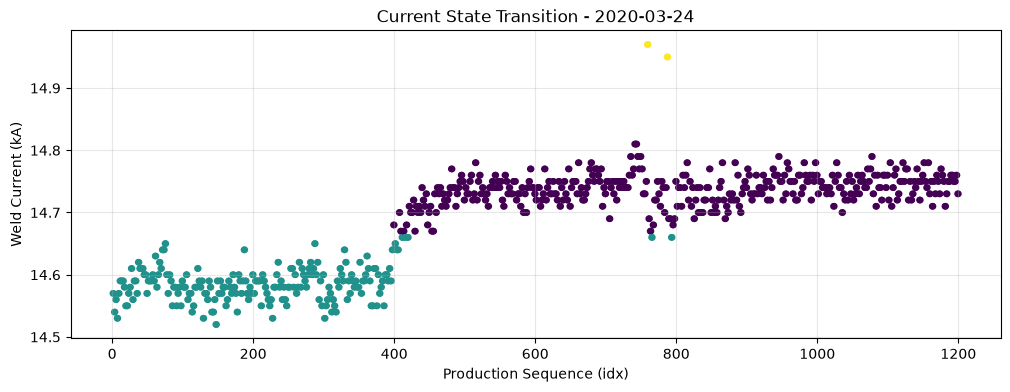

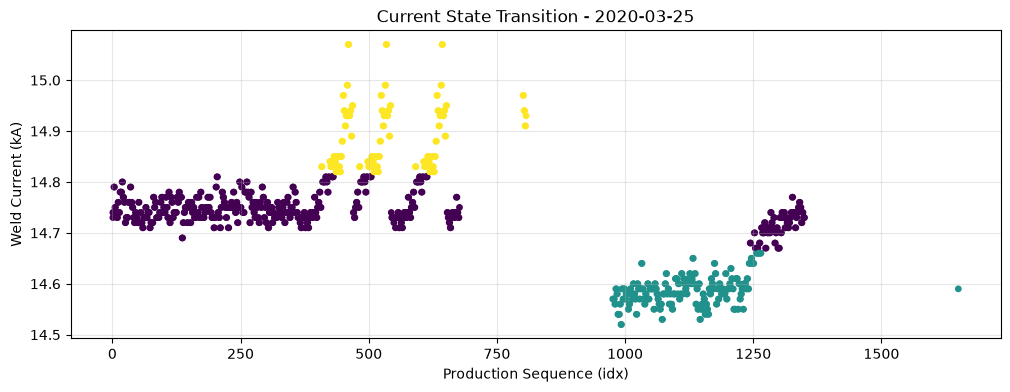

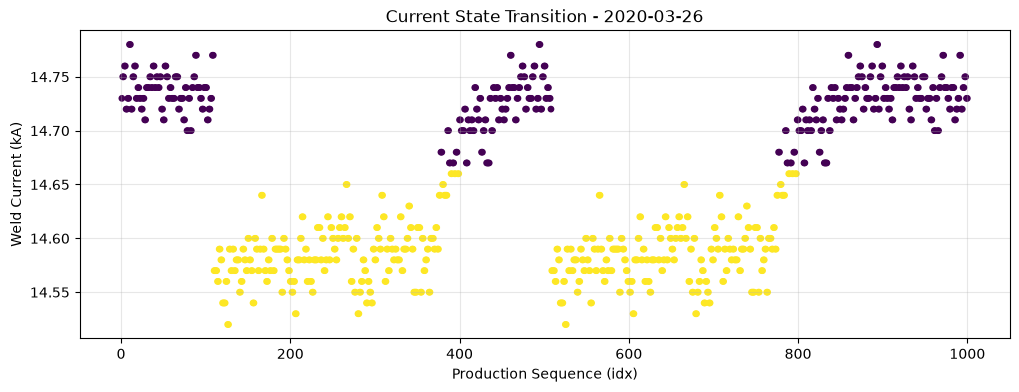

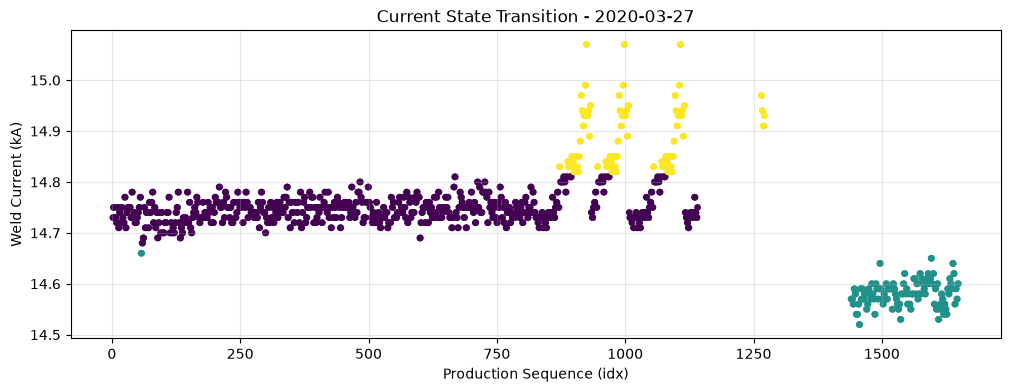

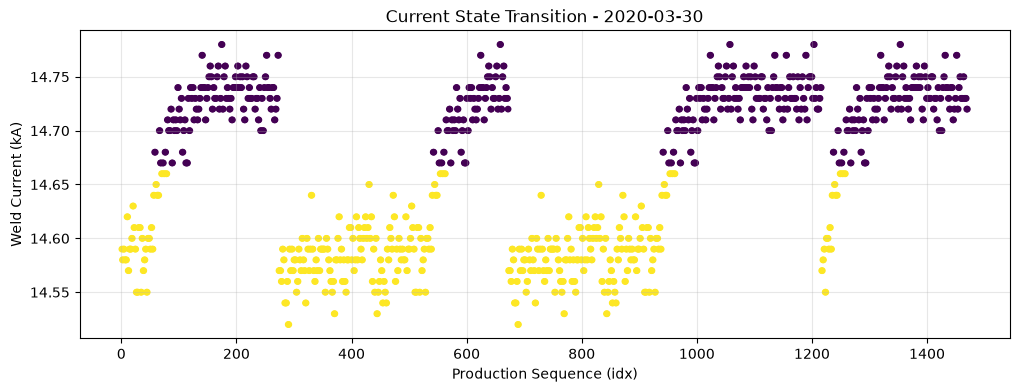

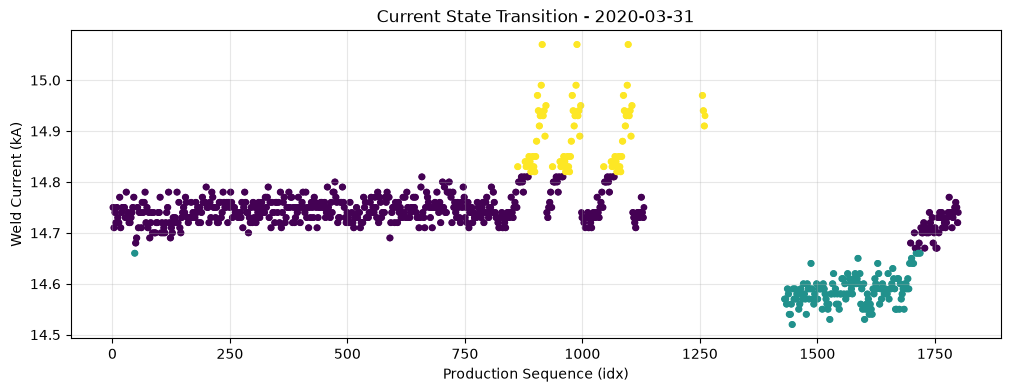

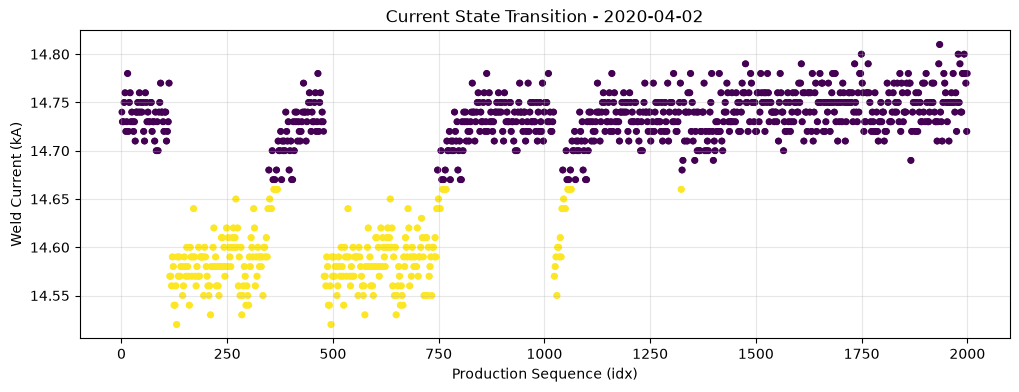

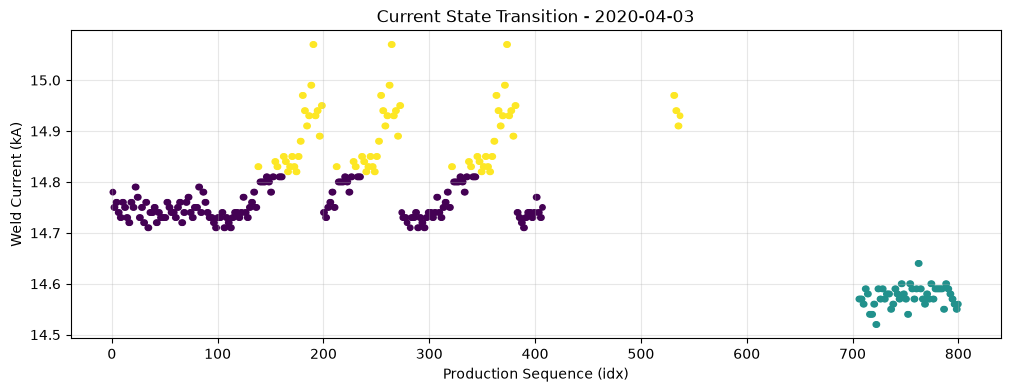

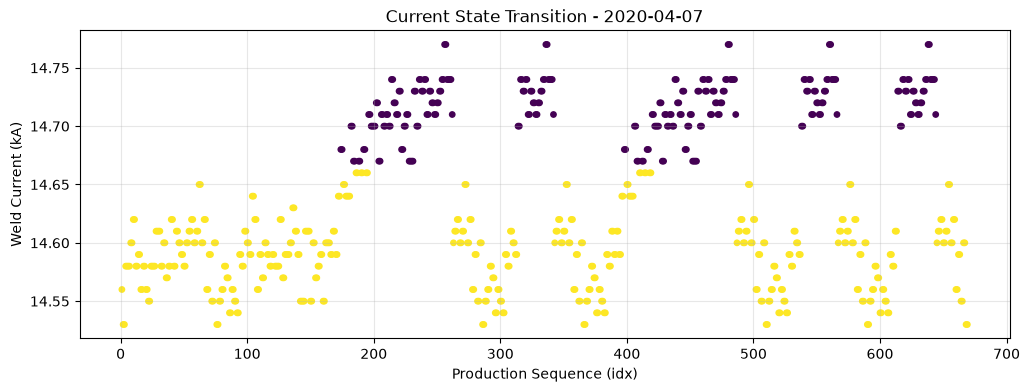


=== 실제 상태 전환 ===


,Date,idx,From,To
0,2020-03-24,399,Low,Mid
1,2020-03-24,401,Mid,Low
2,2020-03-24,407,Low,Mid
3,2020-03-24,411,Mid,Low
4,2020-03-24,413,Low,Mid
5,2020-03-24,415,Mid,Low
6,2020-03-24,417,Low,Mid
7,2020-03-24,419,Mid,Low
8,2020-03-24,421,Low,Mid
9,2020-03-24,759,Mid,High



=== 상태 전환 횟수 ===


To,High,Low,Mid
From,,,
High,0,4,38
Low,0,0,78
Mid,42,75,0



=== 날짜별 총 상태 전환 횟수 ===


,Date,Transition_Count
0,2020-03-24,17
1,2020-03-25,30
2,2020-03-26,20
3,2020-03-27,22
4,2020-03-30,39
5,2020-03-31,31
6,2020-04-02,32
7,2020-04-03,20
8,2020-04-07,26


In [14]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Force 2.xx 데이터
# ==========================================

temp = force2.copy()

# 날짜 생성
temp["Date"] = pd.to_datetime(
    temp["working time"]
).dt.date

# ==========================================
# 2. Current 하나만으로 K-Means
# Low / Mid / High 3개 상태
# ==========================================

X = temp[["weld current(kA)"]]

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

temp["Cluster"] = kmeans.fit_predict(X)


# ==========================================
# 3. 클러스터 중심 확인
# ==========================================

centers = kmeans.cluster_centers_.flatten()

print("원래 Cluster 중심:")
for i, center in enumerate(centers):
    print(f"Cluster {i}: {center:.4f} kA")


# ==========================================
# 4. 중심값 순서대로 Low / Mid / High 지정
# ==========================================

order = np.argsort(centers)

state_map = {
    order[0]: "Low",
    order[1]: "Mid",
    order[2]: "High"
}

temp["Current_State"] = temp["Cluster"].map(state_map)


print("\n=== 전류 상태별 통계 ===")

display(
    temp.groupby("Current_State")["weld current(kA)"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reindex(["Low", "Mid", "High"])
    .round(4)
)


# ==========================================
# 5. 날짜별 idx 순서에서 상태 시각화
# ==========================================

for date, day in temp.groupby("Date"):

    day = day.sort_values("idx")

    plt.figure(figsize=(12, 4))

    plt.scatter(
        day["idx"],
        day["weld current(kA)"],
        c=day["Cluster"],
        s=15
    )

    plt.title(f"Current State Transition - {date}")
    plt.xlabel("Production Sequence (idx)")
    plt.ylabel("Weld Current (kA)")
    plt.grid(alpha=0.3)

    plt.show()


# ==========================================
# 6. 실제 상태 전환 계산
# ==========================================

transition_results = []

for date, day in temp.groupby("Date"):

    day = day.sort_values("idx").copy()

    # 이전 상태
    day["Previous_State"] = day["Current_State"].shift()

    # 상태가 실제로 바뀐 행만
    changes = day[
        (day["Previous_State"].notna()) &
        (day["Current_State"] != day["Previous_State"])
    ]

    for _, row in changes.iterrows():

        transition_results.append({
            "Date": date,
            "idx": row["idx"],
            "From": row["Previous_State"],
            "To": row["Current_State"]
        })


transitions = pd.DataFrame(transition_results)

print("\n=== 실제 상태 전환 ===")
display(transitions.head(30))


# ==========================================
# 7. 전환 종류별 횟수
# ==========================================

transition_count = (
    transitions
    .groupby(["From", "To"])
    .size()
    .unstack(fill_value=0)
)

print("\n=== 상태 전환 횟수 ===")
display(transition_count)


# ==========================================
# 8. 날짜별 전환 횟수
# ==========================================

daily_transition = (
    transitions
    .groupby("Date")
    .size()
    .reset_index(name="Transition_Count")
)

print("\n=== 날짜별 총 상태 전환 횟수 ===")
display(daily_transition)

In [15]:
import pandas as pd

data = df.copy()

# 1. working time에서 날짜 추출
data["Date"] = pd.to_datetime(data["working time"]).dt.date

# 2. 요일 생성
weekday_map = {
    0: "월",
    1: "화",
    2: "수",
    3: "목",
    4: "금",
    5: "토",
    6: "일"
}

data["Weekday"] = (
    pd.to_datetime(data["working time"])
    .dt.dayofweek
    .map(weekday_map)
)

# ==========================================
# 3. CSV에 실제 존재하는 모든 날짜 + 요일
# ==========================================

date_table = (
    data[["Date", "Weekday"]]
    .drop_duplicates()
    .sort_values("Date")
    .reset_index(drop=True)
)

print("=== 데이터에 존재하는 모든 날짜 ===")
display(date_table)

print("\n총 생산 날짜:", len(date_table))


# ==========================================
# 4. 요일별 생산 행 수
# ==========================================

weekday_count = (
    data.groupby("Weekday")
    .size()
    .reindex(["월", "화", "수", "목", "금", "토", "일"])
    .dropna()
    .reset_index(name="Rows")
)

print("\n=== 요일별 생산량 ===")
display(weekday_count)


# ==========================================
# 5. 요일별 공정 변수 평균
# ==========================================

weekday_summary = (
    data.groupby("Weekday")
    [
        [
            "weld force(bar)",
            "weld current(kA)",
            "weld Voltage(v)",
            "weld time(ms)"
        ]
    ]
    .agg(["mean", "median", "std"])
    .reindex(["월", "화", "수", "목", "금", "토", "일"])
    .dropna(how="all")
)

print("\n=== 요일별 공정 변수 ===")
display(weekday_summary.round(4))


# ==========================================
# 6. Force 2.xx 공정만 따로 요일별 Current 확인
# ==========================================

force2 = data[
    (data["weld force(bar)"] >= 2) &
    (data["weld force(bar)"] < 3)
].copy()

force2_weekday = (
    force2.groupby("Weekday")["weld current(kA)"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
    .reindex(["월", "화", "수", "목", "금", "토", "일"])
    .dropna()
)

print("\n=== Force 2.xx : 요일별 Current ===")
display(force2_weekday.round(4))

=== 데이터에 존재하는 모든 날짜 ===


,Date,Weekday
0,2020-03-24,화
1,2020-03-25,수
2,2020-03-26,목
3,2020-03-27,금
4,2020-03-30,월
5,2020-03-31,화
6,2020-04-02,목
7,2020-04-03,금
8,2020-04-07,화



총 생산 날짜: 9

=== 요일별 생산량 ===


,Weekday,Rows
0,월,1470.0
1,화,3669.0
2,수,1352.0
3,목,3000.0
4,금,2448.0



=== 요일별 공정 변수 ===


weld force(bar)                weld current(kA)                 \
                   mean median     std             mean median     std   
Weekday                                                                  
월                2.3472   2.35  0.0213          14.6646  14.70  0.0736   
화                2.7004   2.33  1.3261          14.7064  14.73  0.0962   
수                3.3324   2.35  2.0346          14.7482  14.74  0.1107   
목                2.3378   2.34  0.0288          14.6789  14.72  0.0759   
금                3.4346   2.34  2.1120          14.7655  14.75  0.1027   

        weld Voltage(v)                weld time(ms)                 
                   mean median     std          mean median     std  
Weekday                                                              
월                2.7018  2.701  0.0038       71.7385   72.0  0.6265  
화                2.7039  2.702  0.0224       71.7156   72.0  0.6368  
수                2.7069  2.702  0.0362       71.7199   72.0  0.6328  
목                2.7021  2.702  0.0042       71.7354   72.0  0.6271  
금                2.7073  2.703  0.0380       71.7167   72.0  0.6340


=== Force 2.xx : 요일별 Current ===


,count,mean,median,std,min,max
Weekday,,,,,,
월,1470.0,14.6646,14.70,0.0736,14.52,14.78
화,3376.0,14.6947,14.72,0.0874,14.52,15.07
수,1059.0,14.7224,14.74,0.1019,14.52,15.07
목,3000.0,14.6789,14.72,0.0759,14.52,14.81
금,1862.0,14.7416,14.74,0.0947,14.52,15.07


=== 생산일별 공정 패턴 ===


,Production_Day,Date,Weekday,Gap_Days,Force_7_8,Low,Mid,High
0,1,2020-03-24,화,NaN,X,34.50,65.17,0.33
1,2,2020-03-25,수,1.0,O,26.53,60.34,13.13
2,3,2020-03-26,목,1.0,X,56.00,44.00,0.00
3,4,2020-03-27,금,1.0,O,15.65,74.10,10.26
4,5,2020-03-30,월,3.0,X,44.97,55.03,0.00
5,6,2020-03-31,화,1.0,O,18.71,72.06,9.22
6,7,2020-04-02,목,2.0,X,28.00,72.00,0.00
7,8,2020-04-03,금,1.0,O,18.74,53.85,27.42
8,9,2020-04-07,화,4.0,X,63.68,36.32,0.00


c:\Users\sj789\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sj789\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sj789\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sj789\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sj789\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages

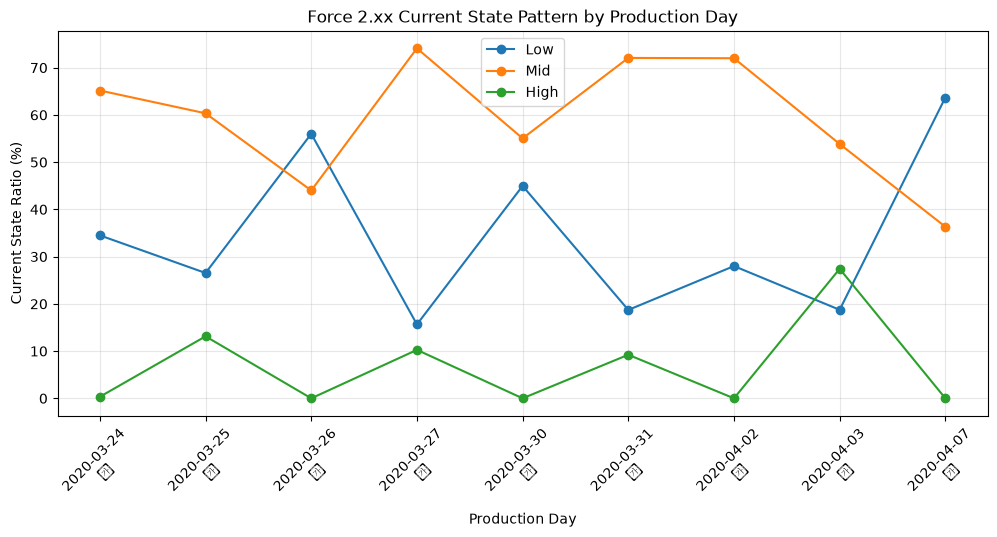


=== Force 7~8 등장 순서 ===
X → O → X → O → X → O → X → O → X

=== 생산일별 요약 ===


,Production_Day,Date,Weekday,Gap_Days,Force_7_8,Dominant_Current,Low,Mid,High
0,1,2020-03-24,화,NaN,X,Mid,34.50,65.17,0.33
1,2,2020-03-25,수,1.0,O,Mid,26.53,60.34,13.13
2,3,2020-03-26,목,1.0,X,Low,56.00,44.00,0.00
3,4,2020-03-27,금,1.0,O,Mid,15.65,74.10,10.26
4,5,2020-03-30,월,3.0,X,Mid,44.97,55.03,0.00
5,6,2020-03-31,화,1.0,O,Mid,18.71,72.06,9.22
6,7,2020-04-02,목,2.0,X,Mid,28.00,72.00,0.00
7,8,2020-04-03,금,1.0,O,Mid,18.74,53.85,27.42
8,9,2020-04-07,화,4.0,X,Low,63.68,36.32,0.00


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# 1. 날짜별 Force 7~8 공정 존재 여부
# =====================================================

data["Date"] = pd.to_datetime(data["working time"]).dt.date

force78_daily = (
    data.groupby("Date")
    .apply(
        lambda x: (
            (x["weld force(bar)"] >= 7) &
            (x["weld force(bar)"] < 9)
        ).any(),
        include_groups=False
    )
    .reset_index(name="Force_7_8")
)

force78_daily["Force_7_8"] = force78_daily["Force_7_8"].map({
    True: "O",
    False: "X"
})


# =====================================================
# 2. Force 2.xx의 날짜별 Low / Mid / High 비율
# temp = 앞에서 K-Means 돌린 Force 2.xx 데이터
# =====================================================

temp["Date"] = pd.to_datetime(temp["working time"]).dt.date

current_ratio = (
    temp.groupby(["Date", "Current_State"])
    .size()
    .unstack(fill_value=0)
)

current_ratio = (
    current_ratio
    .div(current_ratio.sum(axis=1), axis=0)
    * 100
)

# 컬럼 없는 경우 대비
for col in ["Low", "Mid", "High"]:
    if col not in current_ratio.columns:
        current_ratio[col] = 0

current_ratio = current_ratio[
    ["Low", "Mid", "High"]
].reset_index()


# =====================================================
# 3. 합치기
# =====================================================

daily_pattern = force78_daily.merge(
    current_ratio,
    on="Date",
    how="left"
)

daily_pattern = daily_pattern.sort_values("Date").reset_index(drop=True)

# 생산일 순번
daily_pattern["Production_Day"] = np.arange(
    1,
    len(daily_pattern) + 1
)

# 실제 날짜 간격
daily_pattern["Date_dt"] = pd.to_datetime(daily_pattern["Date"])

daily_pattern["Gap_Days"] = (
    daily_pattern["Date_dt"]
    .diff()
    .dt.days
)

# 요일
weekday_map = {
    0: "월",
    1: "화",
    2: "수",
    3: "목",
    4: "금",
    5: "토",
    6: "일"
}

daily_pattern["Weekday"] = (
    daily_pattern["Date_dt"]
    .dt.dayofweek
    .map(weekday_map)
)


# =====================================================
# 4. 결과표
# =====================================================

result = daily_pattern[
    [
        "Production_Day",
        "Date",
        "Weekday",
        "Gap_Days",
        "Force_7_8",
        "Low",
        "Mid",
        "High"
    ]
]

print("=== 생산일별 공정 패턴 ===")

display(
    result.round(2)
)


# =====================================================
# 5. 생산일 순서에 따른 Current 상태 비율
# =====================================================

plt.figure(figsize=(12, 5))

plt.plot(
    daily_pattern["Production_Day"],
    daily_pattern["Low"],
    marker="o",
    label="Low"
)

plt.plot(
    daily_pattern["Production_Day"],
    daily_pattern["Mid"],
    marker="o",
    label="Mid"
)

plt.plot(
    daily_pattern["Production_Day"],
    daily_pattern["High"],
    marker="o",
    label="High"
)

plt.xticks(
    daily_pattern["Production_Day"],
    [
        f'{d}\n{w}'
        for d, w in zip(
            daily_pattern["Date"],
            daily_pattern["Weekday"]
        )
    ],
    rotation=45
)

plt.ylabel("Current State Ratio (%)")
plt.xlabel("Production Day")
plt.title("Force 2.xx Current State Pattern by Production Day")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# =====================================================
# 6. Force 7~8 등장 여부만 순서대로 출력
# =====================================================

print("\n=== Force 7~8 등장 순서 ===")

print(
    " → ".join(
        daily_pattern["Force_7_8"].tolist()
    )
)


# =====================================================
# 7. 날짜별 대표 Current 상태
# =====================================================

daily_pattern["Dominant_Current"] = (
    daily_pattern[["Low", "Mid", "High"]]
    .idxmax(axis=1)
)

print("\n=== 생산일별 요약 ===")

display(
    daily_pattern[
        [
            "Production_Day",
            "Date",
            "Weekday",
            "Gap_Days",
            "Force_7_8",
            "Dominant_Current",
            "Low",
            "Mid",
            "High"
        ]
    ].round(2)
)

In [ ]:
# A = Force 7~8 없는 생산일
# B = Force 7~8 있는 생산일

daily_pattern["Group"] = daily_pattern["Force_7_8"].map({
    "X": "A",
    "O": "B"
})

# A/B별 Current 상태 평균 비율 비교
ab_compare = (
    daily_pattern.groupby("Group")
    [["Low", "Mid", "High"]]
    .mean()
)

print("=== A / B Current 패턴 비교 ===")
display(ab_compare.round(2))

In [3]:
import pandas as pd

# =====================================================
# 1. 지금까지 분석한 날짜별 패턴
# =====================================================

daily_pattern = pd.DataFrame({
    "Date": pd.to_datetime([
        "2020-03-24",
        "2020-03-25",
        "2020-03-26",
        "2020-03-27",
        "2020-03-30",
        "2020-03-31",
        "2020-04-02",
        "2020-04-03",
        "2020-04-07"
    ]),

    "Weekday": [
        "화", "수", "목", "금", "월",
        "화", "목", "금", "화"
    ],

    "Force_7_8": [
        "X", "O", "X", "O", "X",
        "O", "X", "O", "X"
    ],

    "Low": [
        34.50, 26.53, 56.00, 15.65, 44.97,
        18.71, 28.00, 18.74, 63.68
    ],

    "Mid": [
        65.17, 60.34, 44.00, 74.10, 55.03,
        72.06, 72.00, 53.85, 36.32
    ],

    "High": [
        0.33, 13.13, 0.00, 10.26, 0.00,
        9.22, 0.00, 27.42, 0.00
    ]
})


# =====================================================
# 2. A / B 생산 패턴 구분
#
# A = Force 7~8 공정 없음
# B = Force 7~8 공정 있음
# =====================================================

daily_pattern["Group"] = daily_pattern["Force_7_8"].map({
    "X": "A",
    "O": "B"
})


# =====================================================
# 3. 날짜별 A/B + Current 패턴 확인
# =====================================================

print("=== 날짜별 생산 패턴 ===")

display(
    daily_pattern[
        [
            "Date",
            "Weekday",
            "Group",
            "Force_7_8",
            "Low",
            "Mid",
            "High"
        ]
    ]
)


# =====================================================
# 4. A/B별 Current 평균 비교
# =====================================================

ab_current = (
    daily_pattern
    .groupby("Group")[["Low", "Mid", "High"]]
    .mean()
)

print("\n=== A/B Current 패턴 평균 ===")

display(ab_current.round(2))


# =====================================================
# 5. result 확인
# =====================================================

print("\n=== result 컬럼 ===")
print(result.columns)

print("\n=== result 앞부분 ===")
display(result.head())


# =====================================================
# 6. result 날짜 형식 변환
# =====================================================

result["Date"] = pd.to_datetime(result["Date"])


# =====================================================
# 7. 날짜별 실제 불량 개수
# =====================================================

daily_defect = (
    result
    .groupby("Date")["defect"]
    .sum()
    .reset_index(name="Defect_Count")
)


# =====================================================
# 8. A/B 데이터와 실제 불량 합치기
# =====================================================

final_compare = daily_pattern.merge(
    daily_defect,
    on="Date",
    how="left"
)


# =====================================================
# 9. 날짜별 결과
# =====================================================

print("\n=== 날짜별 A/B + Current + 실제 불량 ===")

display(
    final_compare[
        [
            "Date",
            "Weekday",
            "Group",
            "Force_7_8",
            "Low",
            "Mid",
            "High",
            "Defect_Count"
        ]
    ]
)


# =====================================================
# 10. A/B별 실제 불량 비교
# =====================================================

ab_result = (
    final_compare
    .groupby("Group")
    .agg(
        Production_Days=("Date", "count"),
        Mean_Low=("Low", "mean"),
        Mean_Mid=("Mid", "mean"),
        Mean_High=("High", "mean"),
        Total_Defect=("Defect_Count", "sum"),
        Mean_Defect=("Defect_Count", "mean")
    )
)

print("\n=== 최종 A vs B 비교 ===")

display(ab_result.round(2))

=== 날짜별 생산 패턴 ===


,Date,Weekday,Group,Force_7_8,Low,Mid,High
0,2020-03-24,화,A,X,34.50,65.17,0.33
1,2020-03-25,수,B,O,26.53,60.34,13.13
2,2020-03-26,목,A,X,56.00,44.00,0.00
3,2020-03-27,금,B,O,15.65,74.10,10.26
4,2020-03-30,월,A,X,44.97,55.03,0.00
5,2020-03-31,화,B,O,18.71,72.06,9.22
6,2020-04-02,목,A,X,28.00,72.00,0.00
7,2020-04-03,금,B,O,18.74,53.85,27.42
8,2020-04-07,화,A,X,63.68,36.32,0.00



=== A/B Current 패턴 평균 ===


,Low,Mid,High
Group,,,
A,45.43,54.50,0.07
B,19.91,65.09,15.01



=== result 컬럼 ===


NameError: name 'result' is not defined

In [4]:
# 현재 메모리에 존재하는 변수 확인
%whos

Variable        Type         Data/Info
--------------------------------------
ab_current      DataFrame    Shape: (2, 3)
daily_pattern   DataFrame    Shape: (9, 7)
pd              module       <module 'pandas' from 'c:<...>es\\pandas\\__init__.py'>


In [5]:
print("=== A / B Current 패턴 비교 ===")
display(ab_current.round(2))

print("\n=== 날짜별 A / B 패턴 ===")
display(daily_pattern.round(2))

=== A / B Current 패턴 비교 ===


,Low,Mid,High
Group,,,
A,45.43,54.50,0.07
B,19.91,65.09,15.01



=== 날짜별 A / B 패턴 ===


C:\Users\sj789\AppData\Local\Temp\ipykernel_2972\785609270.py:5: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(daily_pattern.round(2))


,Date,Weekday,Force_7_8,Low,Mid,High,Group
0,2020-03-24,화,X,34.50,65.17,0.33,A
1,2020-03-25,수,O,26.53,60.34,13.13,B
2,2020-03-26,목,X,56.00,44.00,0.00,A
3,2020-03-27,금,O,15.65,74.10,10.26,B
4,2020-03-30,월,X,44.97,55.03,0.00,A
5,2020-03-31,화,O,18.71,72.06,9.22,B
6,2020-04-02,목,X,28.00,72.00,0.00,A
7,2020-04-03,금,O,18.74,53.85,27.42,B
8,2020-04-07,화,X,63.68,36.32,0.00,A


=== Current 중심값 ===
Low : 14.586 kA
Mid : 14.738 kA
High : 14.893 kA

=== 날짜별 전류 상태 전환 횟수 ===


,Date,Group,Total_Rows,Transition_Count,Transition_Rate
0,2020-03-24,A,1200,17,1.42
1,2020-03-25,B,1059,30,2.83
2,2020-03-26,A,1000,20,2.00
3,2020-03-27,B,1355,22,1.62
4,2020-03-30,A,1470,39,2.65
5,2020-03-31,B,1507,31,2.06
6,2020-04-02,A,2000,32,1.60
7,2020-04-03,B,507,20,3.94
8,2020-04-07,A,669,26,3.89



=== A vs B 전환 비교 ===


,Days,Mean_Transitions,Mean_Transition_Rate
Group,,,
A,5,26.80,2.31
B,4,25.75,2.61



=== A/B별 전환 종류 ===


Transition,High → Low,High → Mid,Low → Mid,Mid → High,Mid → Low
Group,,,,,
A,0,2,66,2,64
B,4,36,12,40,11



=== 날짜별 전환 종류 ===


,Transition,High → Low,High → Mid,Low → Mid,Mid → High,Mid → Low
Date,Group,,,,,
2020-03-24,A,0,2,7,2,6
2020-03-25,B,1,9,5,10,5
2020-03-26,A,0,0,10,0,10
2020-03-27,B,1,9,1,10,1
2020-03-30,A,0,0,20,0,19
2020-03-31,B,1,9,6,10,5
2020-04-02,A,0,0,16,0,16
2020-04-03,B,1,9,0,10,0
2020-04-07,A,0,0,13,0,13


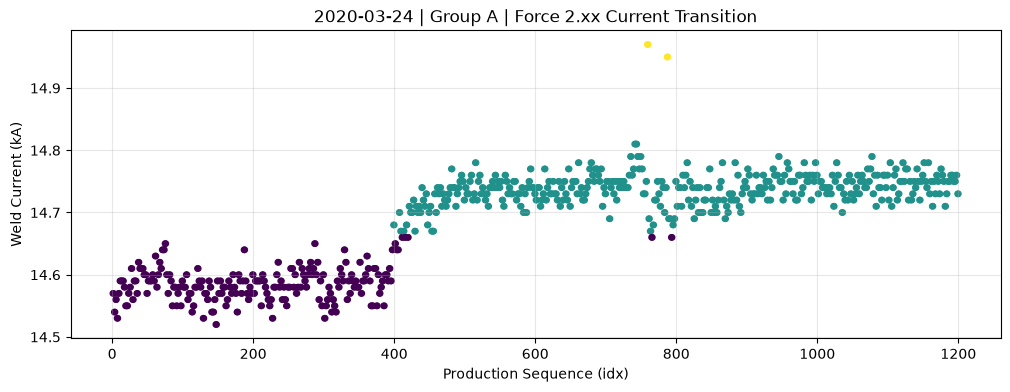

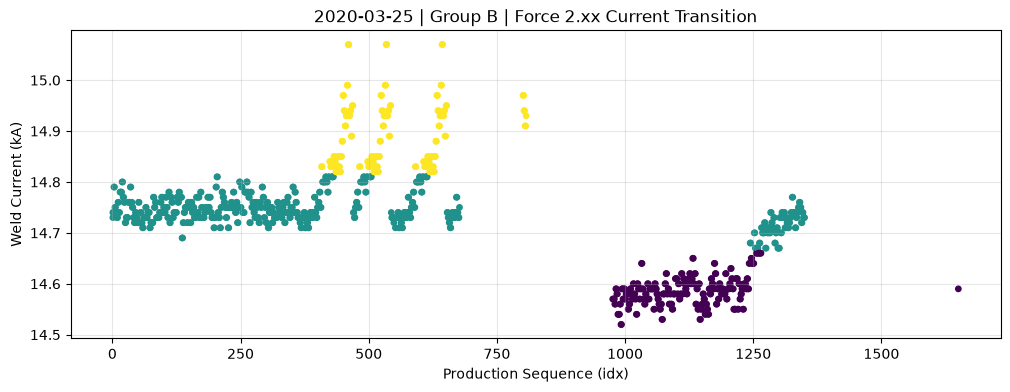

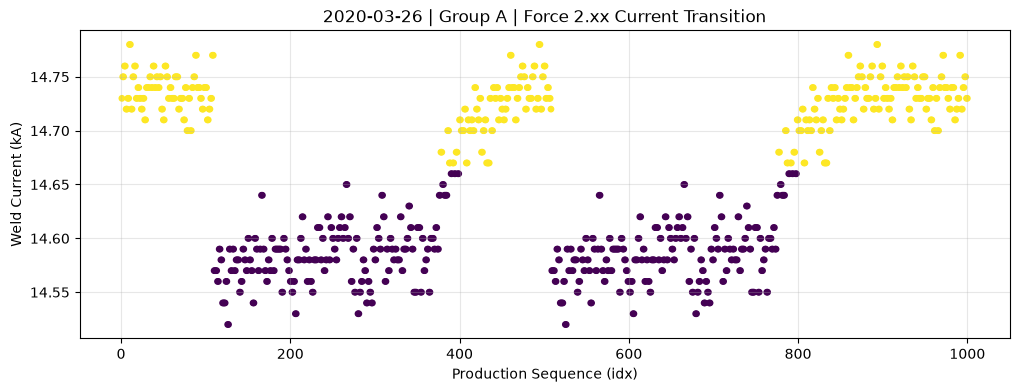

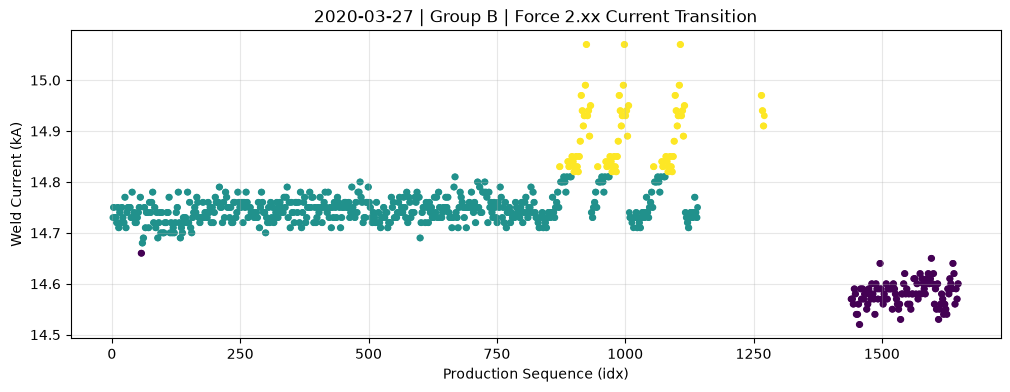

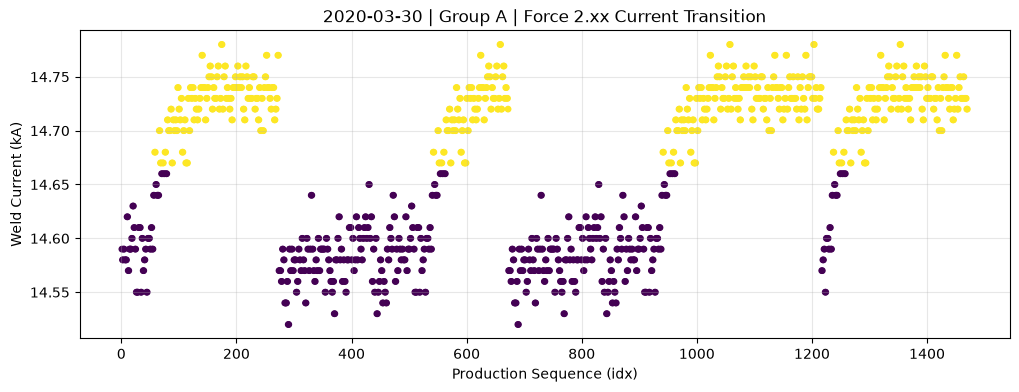

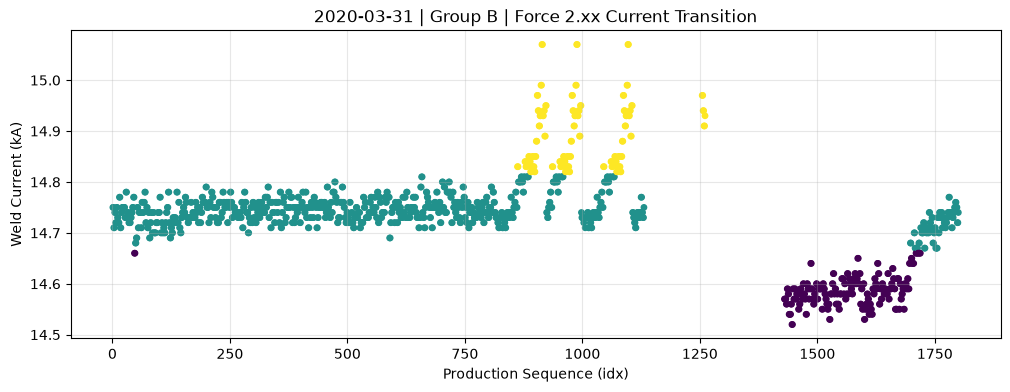

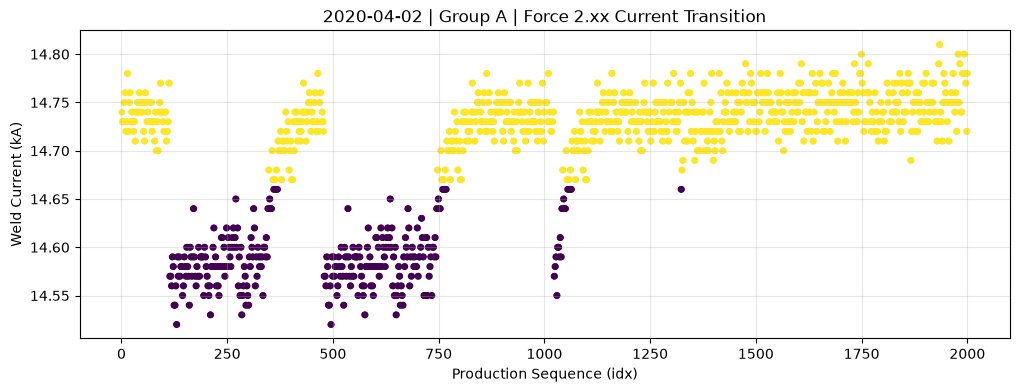

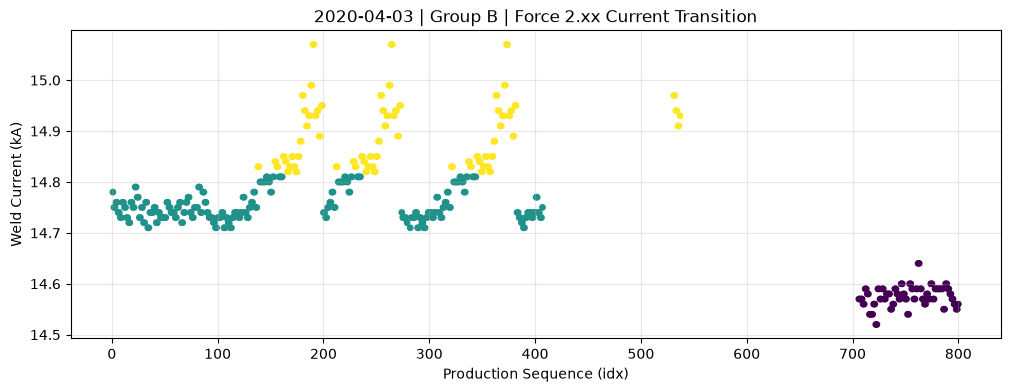

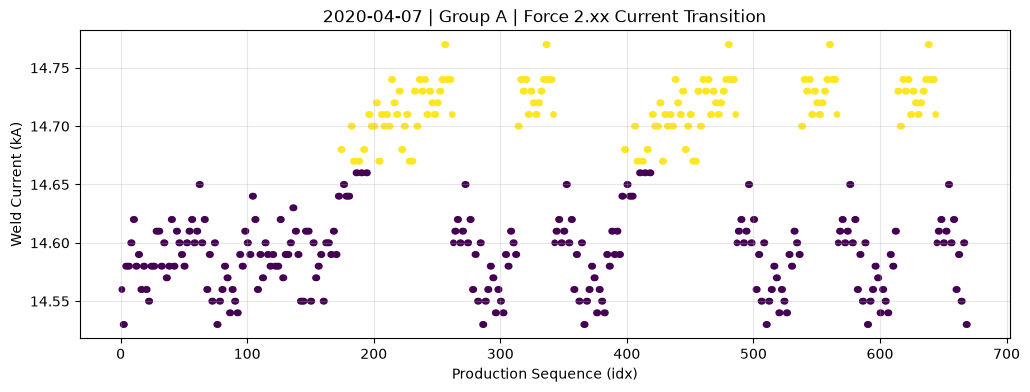

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# =====================================================
# 1. 원본 데이터 불러오기
# =====================================================

file_path = "../YSJ-001/Welding Data Set_01.xlsx"

df = pd.read_excel(file_path)

# 날짜 생성
df["Date"] = pd.to_datetime(df["working time"]).dt.date


# =====================================================
# 2. A / B 날짜 정의
#
# A = Force 7~8 공정 없는 날
# B = Force 7~8 공정 있는 날
# =====================================================

B_dates = pd.to_datetime([
    "2020-03-25",
    "2020-03-27",
    "2020-03-31",
    "2020-04-03"
]).date

df["Group"] = np.where(
    df["Date"].isin(B_dates),
    "B",
    "A"
)


# =====================================================
# 3. Force 2.xx 데이터만 선택
# =====================================================

force2 = df[
    (df["weld force(bar)"] >= 2.0) &
    (df["weld force(bar)"] < 3.0)
].copy()

force2 = force2.sort_values(["Date", "idx"])


# =====================================================
# 4. Current를 Low / Mid / High 3개 상태로 K-Means
# =====================================================

X = force2[["weld current(kA)"]]

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

force2["cluster"] = kmeans.fit_predict(X)

# cluster 중심값이 낮은 순서대로 Low / Mid / High 지정
centers = kmeans.cluster_centers_.flatten()

order = np.argsort(centers)

state_map = {
    order[0]: "Low",
    order[1]: "Mid",
    order[2]: "High"
}

force2["Current_State"] = force2["cluster"].map(state_map)

print("=== Current 중심값 ===")

for cluster_num, state in state_map.items():
    print(
        state,
        ":",
        round(centers[cluster_num], 3),
        "kA"
    )


# =====================================================
# 5. 날짜별 상태 전환 계산
# =====================================================

transition_results = []

for date, day in force2.groupby("Date"):

    day = day.sort_values("idx").copy()

    # 이전 상태
    day["Previous_State"] = day["Current_State"].shift(1)

    # 상태가 실제로 바뀐 행만
    changes = day[
        day["Current_State"] != day["Previous_State"]
    ].copy()

    # 첫 행 제외
    changes = changes.iloc[1:]

    group = day["Group"].iloc[0]

    transition_results.append({
        "Date": date,
        "Group": group,
        "Total_Rows": len(day),
        "Transition_Count": len(changes),
        "Transition_Rate": len(changes) / len(day) * 100
    })


transition_summary = pd.DataFrame(transition_results)

print("\n=== 날짜별 전류 상태 전환 횟수 ===")

display(
    transition_summary.round(2)
)


# =====================================================
# 6. A / B 평균 전환 횟수 비교
# =====================================================

ab_transition = (
    transition_summary
    .groupby("Group")
    .agg(
        Days=("Date", "count"),
        Mean_Transitions=("Transition_Count", "mean"),
        Mean_Transition_Rate=("Transition_Rate", "mean")
    )
)

print("\n=== A vs B 전환 비교 ===")

display(
    ab_transition.round(2)
)


# =====================================================
# 7. 실제 전환 종류 계산
# 예: Low → Mid / Mid → High 등
# =====================================================

transition_list = []

for (date, group), day in force2.groupby(["Date", "Group"]):

    day = day.sort_values("idx").copy()

    previous = day["Current_State"].shift(1)

    mask = (
        previous.notna() &
        (previous != day["Current_State"])
    )

    temp = pd.DataFrame({
        "Date": date,
        "Group": group,
        "From": previous[mask],
        "To": day.loc[mask, "Current_State"]
    })

    transition_list.append(temp)


transitions = pd.concat(
    transition_list,
    ignore_index=True
)

transitions["Transition"] = (
    transitions["From"] +
    " → " +
    transitions["To"]
)


# =====================================================
# 8. A/B별 어떤 전환이 많이 발생하는지
# =====================================================

transition_counts = (
    transitions
    .groupby(["Group", "Transition"])
    .size()
    .unstack(fill_value=0)
)

print("\n=== A/B별 전환 종류 ===")

display(transition_counts)


# =====================================================
# 9. 날짜별 전환 종류
# =====================================================

daily_transition_counts = (
    transitions
    .groupby(["Date", "Group", "Transition"])
    .size()
    .unstack(fill_value=0)
)

print("\n=== 날짜별 전환 종류 ===")

display(daily_transition_counts)


# =====================================================
# 10. 날짜별 Current 패턴 그래프
# =====================================================

state_color = {
    "Low": 0,
    "Mid": 1,
    "High": 2
}

for date, day in force2.groupby("Date"):

    day = day.sort_values("idx")

    group = day["Group"].iloc[0]

    plt.figure(figsize=(12, 4))

    plt.scatter(
        day["idx"],
        day["weld current(kA)"],
        c=day["Current_State"].map(state_color),
        s=15
    )

    plt.title(
        f"{date} | Group {group} | Force 2.xx Current Transition"
    )

    plt.xlabel("Production Sequence (idx)")
    plt.ylabel("Weld Current (kA)")
    plt.grid(alpha=0.3)

    plt.show()


========== Group A ==========


C:\Users\sj789\AppData\Local\Temp\ipykernel_2972\2506933528.py:112: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


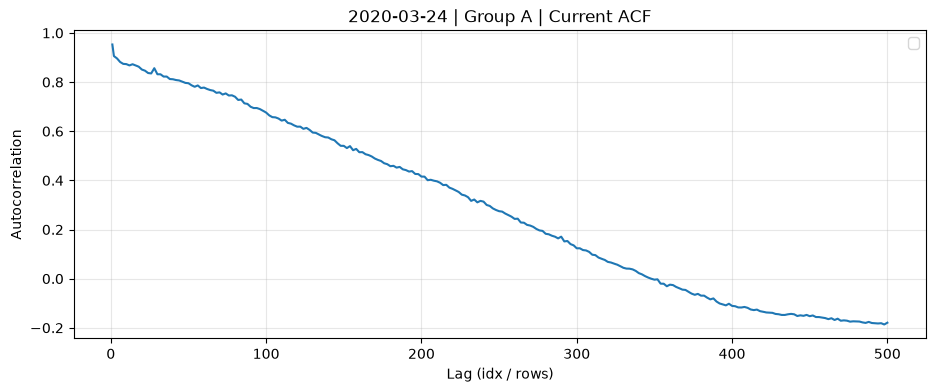

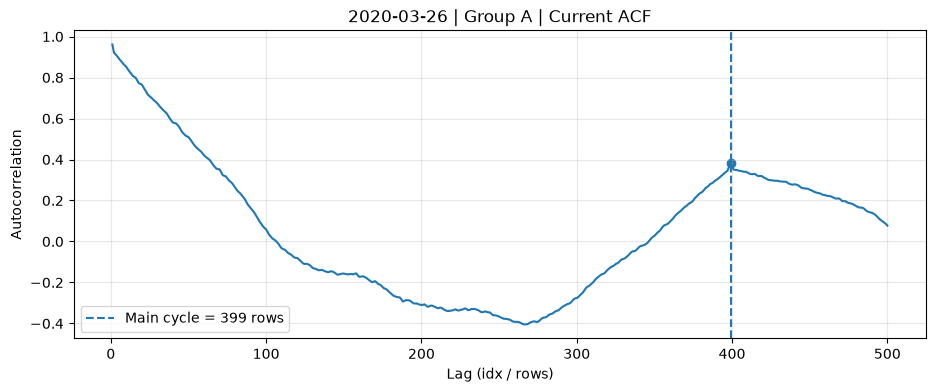

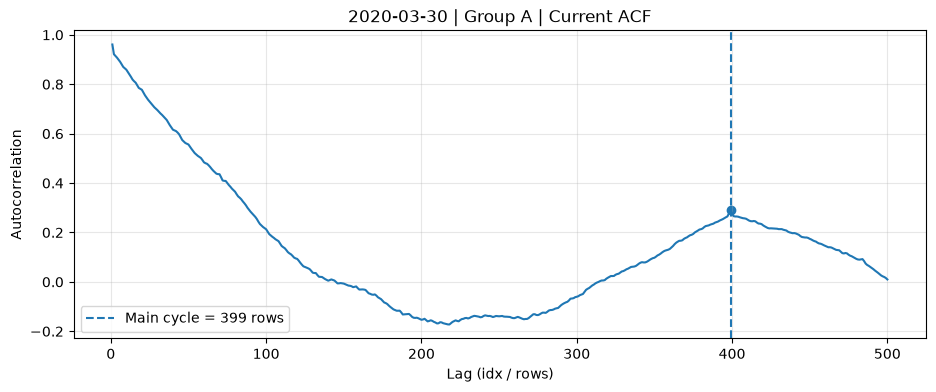

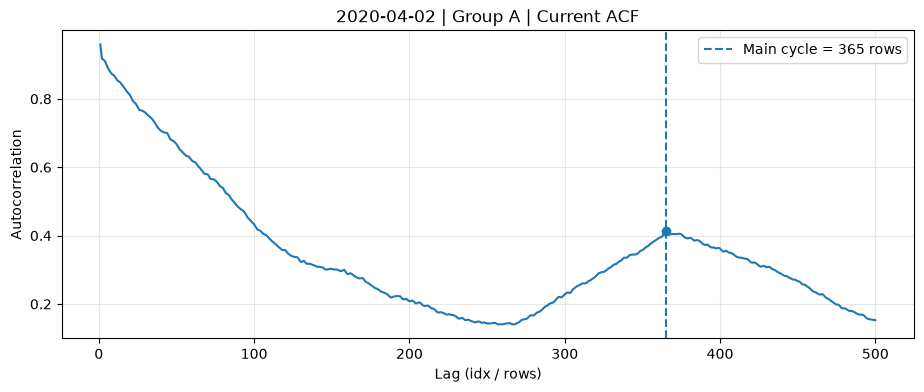

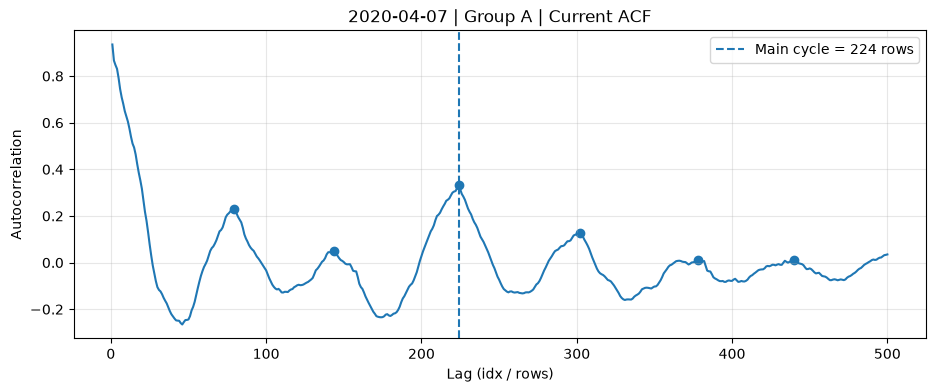


========== Group B ==========


C:\Users\sj789\AppData\Local\Temp\ipykernel_2972\2506933528.py:112: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


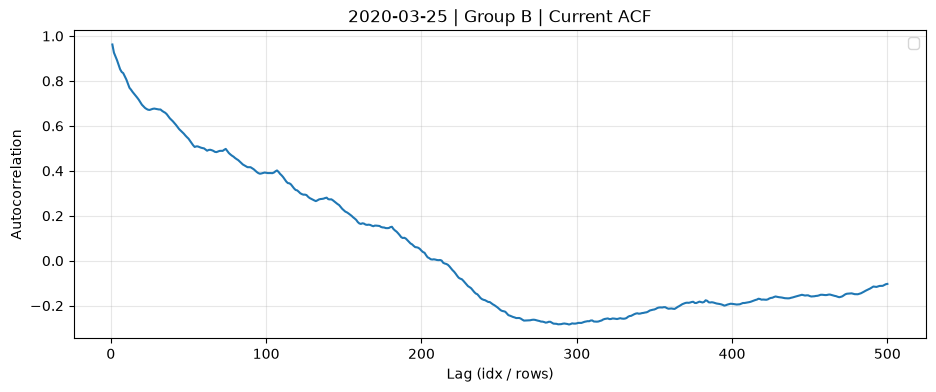

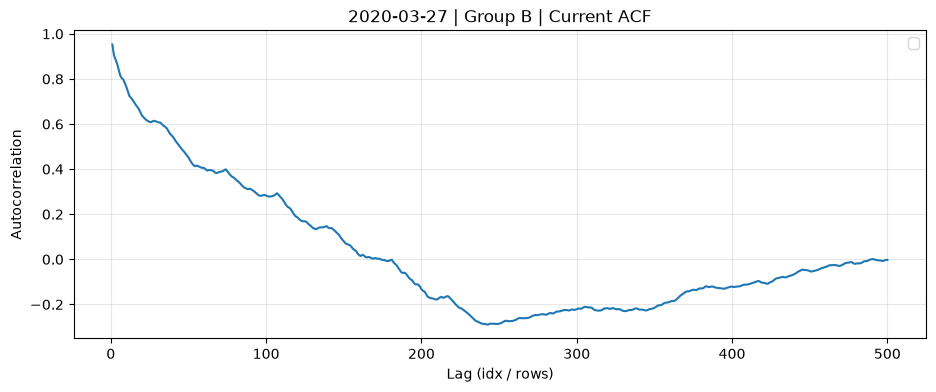

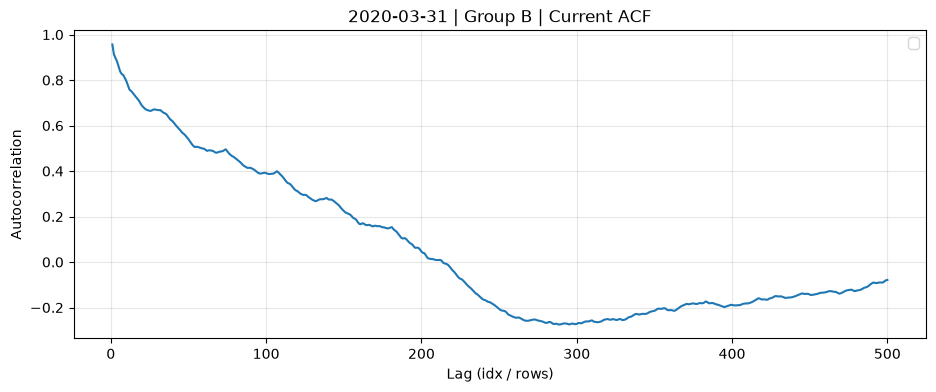

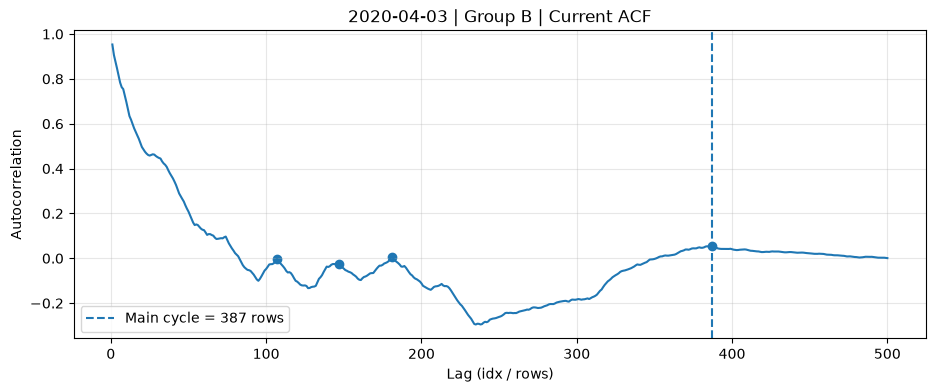


=== 날짜별 반복 주기 ===


,Date,Group,Rows,Cycle_idx,Autocorrelation
0,2020-03-24,A,1200,NaN,NaN
1,2020-03-26,A,1000,399.0,0.381
2,2020-03-30,A,1470,399.0,0.289
3,2020-04-02,A,2000,365.0,0.413
4,2020-04-07,A,669,224.0,0.333
5,2020-03-25,B,1059,NaN,NaN
6,2020-03-27,B,1355,NaN,NaN
7,2020-03-31,B,1507,NaN,NaN
8,2020-04-03,B,507,387.0,0.054



=== A/B 반복 주기 요약 ===


,count,mean,median,std
Group,,,,
A,4,346.75,382.0,83.39
B,1,387.00,387.0,NaN


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# =====================================================
# A/B 각각 idx 기준 반복 주기 분석
# force2는 앞에서 만든 Force 2.xx 데이터 사용
# =====================================================

def find_idx_cycle(data, group_name, max_lag=500):

    # 해당 그룹만
    g = data[data["Group"] == group_name].copy()

    results = []

    print(f"\n========== Group {group_name} ==========")

    # 날짜별 따로 분석
    for date, day in g.groupby("Date"):

        day = day.sort_values("idx").copy()

        current = day["weld current(kA)"].to_numpy()

        # 데이터가 너무 짧으면 제외
        if len(current) < 50:
            continue

        # 평균 제거
        x = current - current.mean()

        # 자기상관
        acf = np.correlate(x, x, mode="full")
        acf = acf[len(acf)//2:]

        # 정규화
        acf = acf / acf[0]

        # 최대 lag 제한
        max_use = min(max_lag, len(acf) - 1)

        lags = np.arange(1, max_use + 1)
        values = acf[1:max_use + 1]

        # -------------------------------------------------
        # 자기상관 peak 찾기
        # 너무 가까운 작은 peak 제거
        # -------------------------------------------------

        peaks, properties = find_peaks(
            values,
            prominence=0.05,
            distance=10
        )

        if len(peaks) > 0:

            peak_lags = lags[peaks]
            peak_values = values[peaks]

            # 자기상관이 가장 강한 peak
            best = np.argmax(peak_values)

            cycle = peak_lags[best]
            strength = peak_values[best]

        else:
            cycle = np.nan
            strength = np.nan

        results.append({
            "Date": date,
            "Group": group_name,
            "Rows": len(day),
            "Cycle_idx": cycle,
            "Autocorrelation": strength
        })

        # -------------------------------------------------
        # 그래프
        # -------------------------------------------------

        plt.figure(figsize=(11, 4))

        plt.plot(
            lags,
            values
        )

        if len(peaks) > 0:
            plt.scatter(
                peak_lags,
                peak_values
            )

        if not np.isnan(cycle):
            plt.axvline(
                cycle,
                linestyle="--",
                label=f"Main cycle = {cycle} rows"
            )

        plt.title(
            f"{date} | Group {group_name} | Current ACF"
        )

        plt.xlabel("Lag (idx / rows)")
        plt.ylabel("Autocorrelation")

        plt.legend()
        plt.grid(alpha=0.3)

        plt.show()

    return pd.DataFrame(results)


# =====================================================
# A 분석
# =====================================================

cycle_A = find_idx_cycle(
    force2,
    "A",
    max_lag=500
)


# =====================================================
# B 분석
# =====================================================

cycle_B = find_idx_cycle(
    force2,
    "B",
    max_lag=500
)


# =====================================================
# 결과 합치기
# =====================================================

cycle_result = pd.concat(
    [cycle_A, cycle_B],
    ignore_index=True
)

print("\n=== 날짜별 반복 주기 ===")

display(
    cycle_result.round(3)
)


# =====================================================
# A/B별 주기 요약
# =====================================================

print("\n=== A/B 반복 주기 요약 ===")

display(
    cycle_result
    .groupby("Group")["Cycle_idx"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

=== A / B Force 2.xx 공정 비교 ===


weld force(bar)                                    weld Voltage(v)  \
                count    mean median     std   min   max           count   
Group                                                                      
A                6339  2.3397   2.34  0.0287  2.16  2.40            6339   
B                4428  2.3375   2.31  0.0721  2.21  2.94            4428   

                                          weld time(ms)                  \
        mean median     std    min    max         count     mean median   
Group                                                                     
A      2.702  2.701  0.0042  2.689  2.717          6339  71.7295   72.0   
B      2.702  2.702  0.0131  2.481  2.761          4428  71.7202   72.0   

                           
          std   min   max  
Group                      
A      0.6307  70.0  73.0  
B      0.6358  70.0  73.0


=== 날짜별 비교 ===


weld force(bar)         weld Voltage(v)          \
                            mean     std            mean     std   
Date       Group                                                   
2020-03-24 A              2.3298  0.0357          2.7021  0.0043   
2020-03-25 B              2.3414  0.0739          2.7020  0.0134   
2020-03-26 A              2.3514  0.0213          2.7020  0.0041   
2020-03-27 B              2.3306  0.0669          2.7022  0.0121   
2020-03-30 A              2.3472  0.0213          2.7018  0.0038   
2020-03-31 B              2.3323  0.0639          2.7021  0.0115   
2020-04-02 A              2.3310  0.0296          2.7022  0.0043   
2020-04-03 B              2.3634  0.0951          2.7012  0.0187   
2020-04-07 A              2.3491  0.0198          2.7020  0.0045   

                 weld time(ms)          
                          mean     std  
Date       Group                        
2020-03-24 A           71.7286  0.6312  
2020-03-25 B           71.7227  0.6350  
2020-03-26 A           71.7496  0.6219  
2020-03-27 B           71.7161  0.6361  
2020-03-30 A           71.7385  0.6265  
2020-03-31 B           71.7202  0.6354  
2020-04-02 A           71.7283  0.6296  
2020-04-03 B           71.7264  0.6398  
2020-04-07 A           71.6846  0.6548

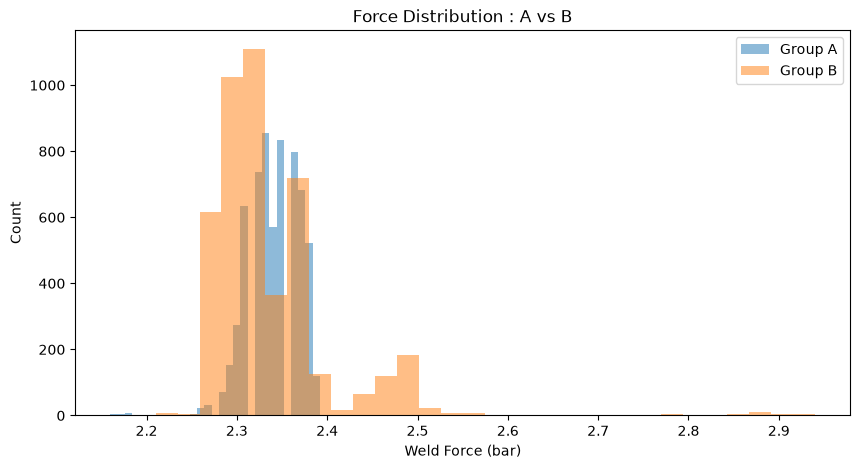

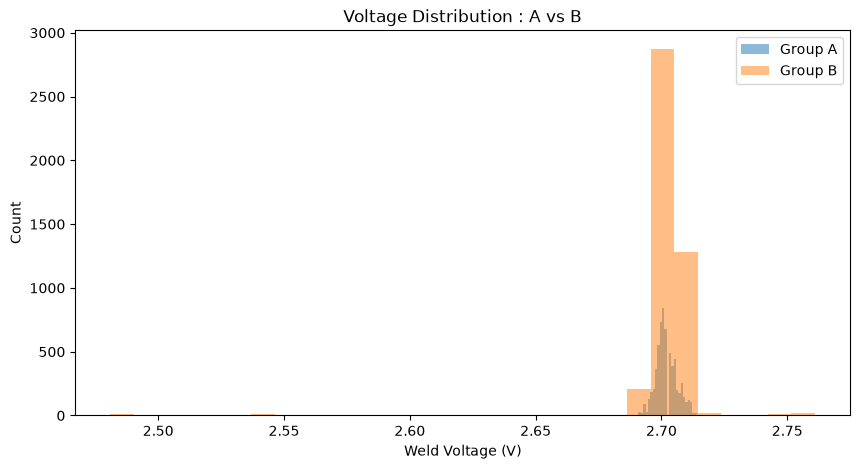

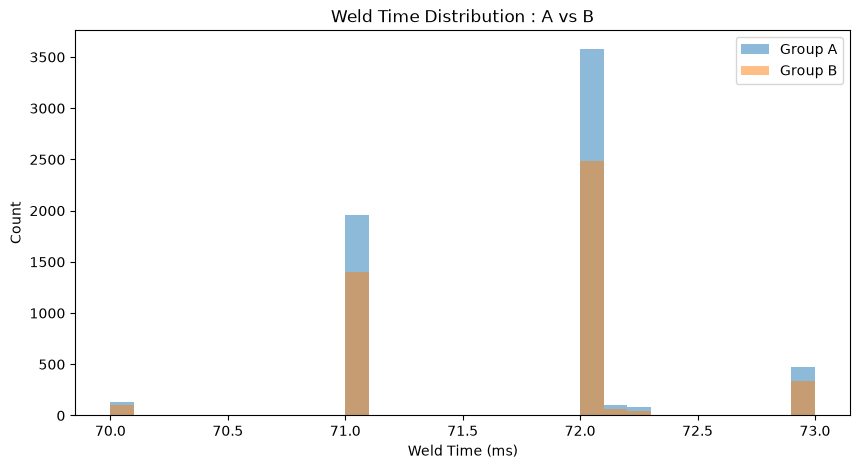


=== 날짜별 평균 ===


,Date,Group,weld force(bar),weld Voltage(v),weld time(ms)
0,2020-03-24,A,2.3298,2.7021,71.7286
1,2020-03-25,B,2.3414,2.7020,71.7227
2,2020-03-26,A,2.3514,2.7020,71.7496
3,2020-03-27,B,2.3306,2.7022,71.7161
4,2020-03-30,A,2.3472,2.7018,71.7385
5,2020-03-31,B,2.3323,2.7021,71.7202
6,2020-04-02,A,2.3310,2.7022,71.7283
7,2020-04-03,B,2.3634,2.7012,71.7264
8,2020-04-07,A,2.3491,2.7020,71.6846


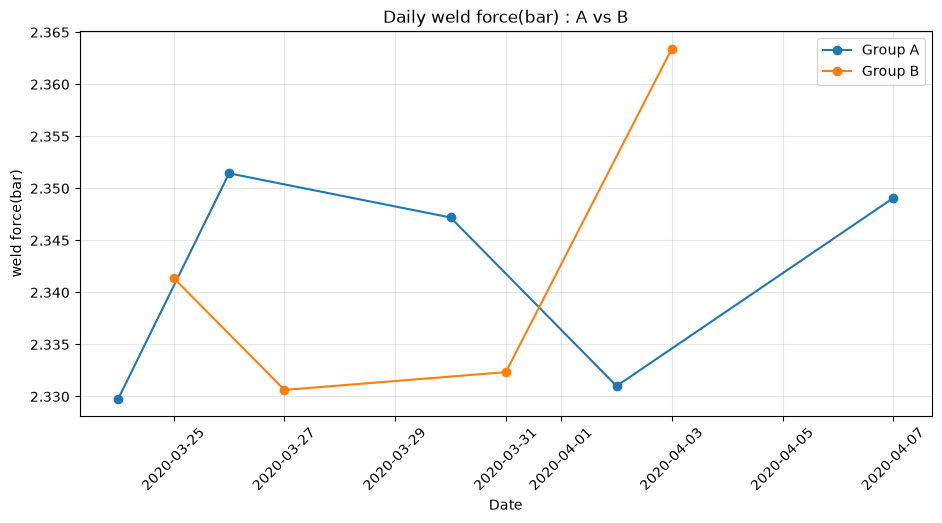

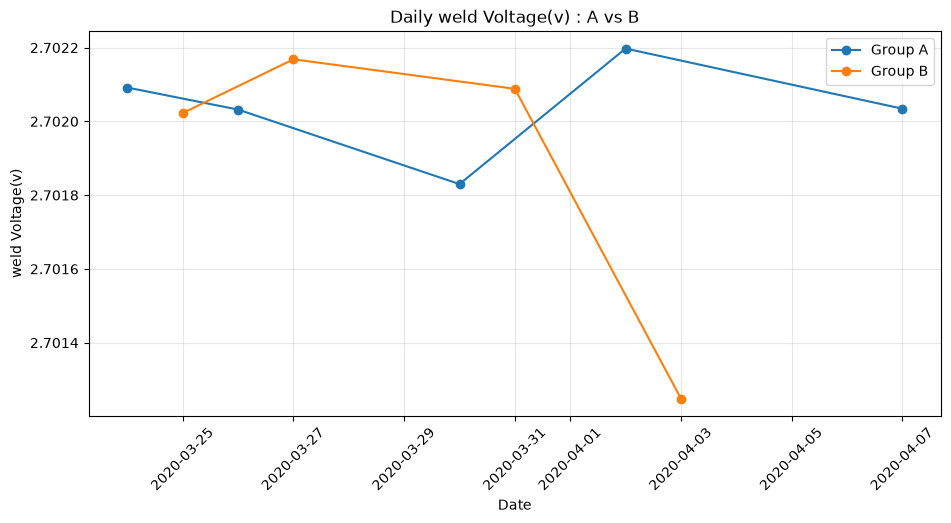

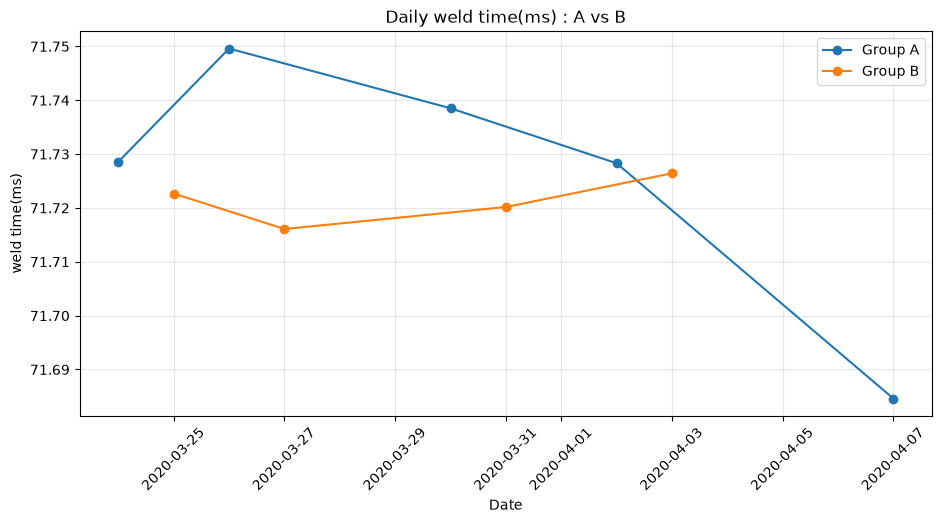

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# Force 2.xx 구간에서 A / B 비교
# =====================================================

cols = [
    "weld force(bar)",
    "weld Voltage(v)",
    "weld time(ms)"
]

# 필요한 데이터만
compare = force2[
    ["Date", "idx", "Group"] + cols
].copy()


# =====================================================
# 1. A / B 기본 통계 비교
# =====================================================

summary = (
    compare
    .groupby("Group")[cols]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

print("=== A / B Force 2.xx 공정 비교 ===")
display(summary.round(4))


# =====================================================
# 2. 날짜별 평균 비교
# =====================================================

daily = (
    compare
    .groupby(["Date", "Group"])[cols]
    .agg(["mean", "std"])
    .round(4)
)

print("\n=== 날짜별 비교 ===")
display(daily)


# =====================================================
# 3. Force 분포
# =====================================================

plt.figure(figsize=(10, 5))

for group in ["A", "B"]:
    temp = compare[compare["Group"] == group]

    plt.hist(
        temp["weld force(bar)"],
        bins=30,
        alpha=0.5,
        label=f"Group {group}"
    )

plt.title("Force Distribution : A vs B")
plt.xlabel("Weld Force (bar)")
plt.ylabel("Count")
plt.legend()
plt.show()


# =====================================================
# 4. Voltage 분포
# =====================================================

plt.figure(figsize=(10, 5))

for group in ["A", "B"]:
    temp = compare[compare["Group"] == group]

    plt.hist(
        temp["weld Voltage(v)"],
        bins=30,
        alpha=0.5,
        label=f"Group {group}"
    )

plt.title("Voltage Distribution : A vs B")
plt.xlabel("Weld Voltage (V)")
plt.ylabel("Count")
plt.legend()
plt.show()


# =====================================================
# 5. Weld Time 분포
# =====================================================

plt.figure(figsize=(10, 5))

for group in ["A", "B"]:
    temp = compare[compare["Group"] == group]

    plt.hist(
        temp["weld time(ms)"],
        bins=30,
        alpha=0.5,
        label=f"Group {group}"
    )

plt.title("Weld Time Distribution : A vs B")
plt.xlabel("Weld Time (ms)")
plt.ylabel("Count")
plt.legend()
plt.show()


# =====================================================
# 6. 날짜별 평균값
# =====================================================

daily_mean = (
    compare
    .groupby(["Date", "Group"])[cols]
    .mean()
    .reset_index()
)

print("\n=== 날짜별 평균 ===")
display(daily_mean.round(4))


# =====================================================
# 7. 날짜 순서에 따른 변화
# =====================================================

for col in cols:

    plt.figure(figsize=(11, 5))

    for group in ["A", "B"]:

        temp = daily_mean[
            daily_mean["Group"] == group
        ]

        plt.plot(
            temp["Date"],
            temp[col],
            marker="o",
            label=f"Group {group}"
        )

    plt.title(f"Daily {col} : A vs B")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


Group A
Rows : 6339
Threshold : 1.70747
Anomaly rows : 317
Anomaly rate : 5.0 %

Group B
Rows : 4428
Threshold : 1.43337
Anomaly rows : 220
Anomaly rate : 4.97 %

=== 날짜별 공정 이상률 ===


C:\Users\sj789\AppData\Local\Temp\ipykernel_2972\1439266631.py:212: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  daily_anomaly.round(4)


,Date,Group,Total_Rows,Anomaly_Count,Mean_Error,Max_Error,Anomaly_Rate
0,2020-03-24,A,1200,89,0.6824,7.1461,7.4167
1,2020-03-25,B,1059,56,0.7838,71.8297,5.2880
2,2020-03-26,A,1000,33,0.5189,3.0091,3.3000
3,2020-03-27,B,1355,55,0.6601,71.8297,4.0590
4,2020-03-30,A,1470,46,0.4947,3.0091,3.1293
5,2020-03-31,B,1507,56,0.6200,71.8297,3.7160
6,2020-04-02,A,2000,118,0.5832,3.7206,5.9000
7,2020-04-03,B,507,53,1.2756,71.8297,10.4536
8,2020-04-07,A,669,31,0.5960,3.0091,4.6338


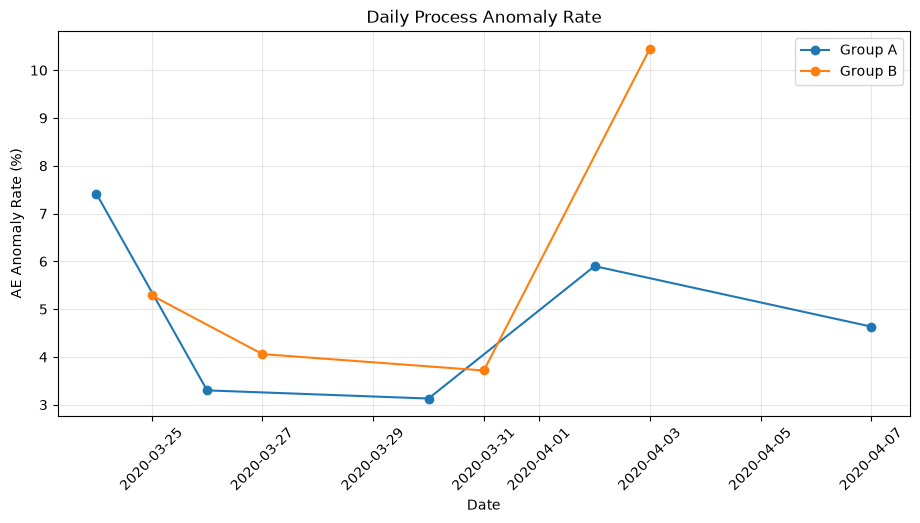

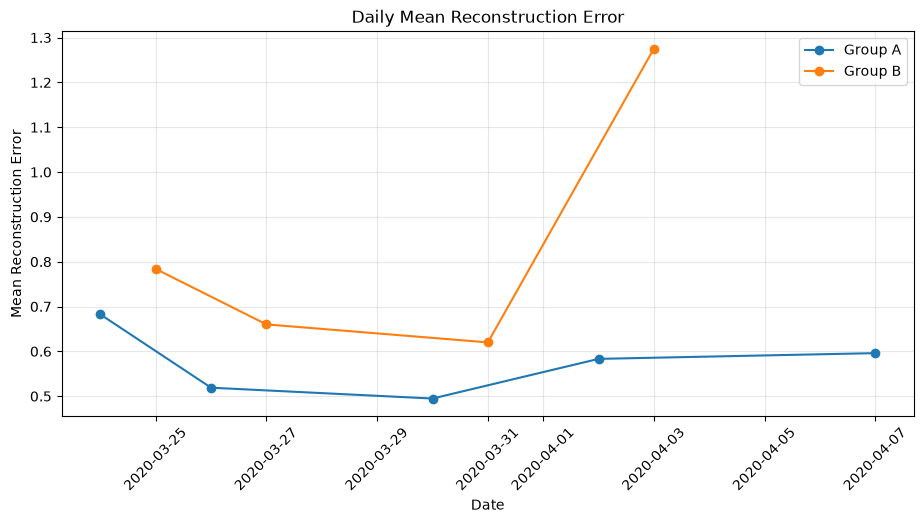


=== Reconstruction Error 상위 30개 ===


C:\Users\sj789\AppData\Local\Temp\ipykernel_2972\1439266631.py:309: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  top_anomaly.round(4)


,Date,idx,Group,weld force(bar),weld current(kA),weld Voltage(v),weld time(ms),Reconstruction_Error,Anomaly
9880,2020-03-31,1130,B,2.49,14.73,2.481,71.0,71.8297,True
10663,2020-04-03,406,B,2.49,14.73,2.481,71.0,71.8297,True
7013,2020-03-25,676,B,2.49,14.73,2.481,71.0,71.8297,True
8534,2020-03-27,1140,B,2.49,14.73,2.481,71.0,71.8297,True
10664,2020-04-03,407,B,2.49,14.75,2.481,72.0,71.7765,True
7014,2020-03-25,677,B,2.49,14.75,2.481,72.0,71.7765,True
9881,2020-03-31,1131,B,2.49,14.75,2.481,72.0,71.7765,True
8535,2020-03-27,1141,B,2.49,14.75,2.481,72.0,71.7765,True
10661,2020-04-03,404,B,2.49,14.74,2.542,73.0,38.8276,True
7011,2020-03-25,674,B,2.49,14.74,2.542,73.0,38.8276,True


In [9]:
# ============================================================
# A/B 공정별 AutoEncoder 이상탐지
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor


# ============================================================
# 1. 사용할 변수
# ============================================================

features = [
    "weld force(bar)",
    "weld current(kA)",
    "weld Voltage(v)",
    "weld time(ms)"
]

data = force2.copy()

data["Date"] = pd.to_datetime(data["Date"])

data = data.dropna(
    subset=features + ["Group"]
).copy()


# ============================================================
# 2. A/B별 AutoEncoder 학습 함수
# ============================================================

def train_autoencoder(group_data, group_name):

    temp = group_data.copy()

    X = temp[features].values


    # -----------------------------
    # Scaling
    # -----------------------------

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)


    # -----------------------------
    # AutoEncoder
    #
    # 4 → 3 → 2 → 3 → 4
    # -----------------------------

    model = MLPRegressor(
        hidden_layer_sizes=(3, 2, 3),
        activation="relu",
        solver="adam",

        max_iter=1000,

        random_state=42
    )


    # 입력값을 다시 입력값으로 복원
    model.fit(
        X_scaled,
        X_scaled
    )


    # -----------------------------
    # Reconstruction
    # -----------------------------

    X_pred = model.predict(X_scaled)


    # 행별 Reconstruction Error
    error = np.mean(
        (X_scaled - X_pred) ** 2,
        axis=1
    )


    temp["Reconstruction_Error"] = error


    # -----------------------------
    # Threshold
    #
    # 상위 5%를 이상 후보로 설정
    # -----------------------------

    threshold = np.percentile(
        error,
        95
    )


    temp["Anomaly"] = (
        temp["Reconstruction_Error"]
        > threshold
    )


    print("\n================================")
    print(f"Group {group_name}")
    print("================================")

    print(
        "Rows :",
        len(temp)
    )

    print(
        "Threshold :",
        round(threshold, 5)
    )

    print(
        "Anomaly rows :",
        temp["Anomaly"].sum()
    )

    print(
        "Anomaly rate :",
        round(
            temp["Anomaly"].mean() * 100,
            2
        ),
        "%"
    )


    return temp, model, scaler, threshold


# ============================================================
# 3. Group A
# ============================================================

A_data = data[
    data["Group"] == "A"
].copy()

A_result, A_model, A_scaler, A_threshold = train_autoencoder(
    A_data,
    "A"
)


# ============================================================
# 4. Group B
# ============================================================

B_data = data[
    data["Group"] == "B"
].copy()

B_result, B_model, B_scaler, B_threshold = train_autoencoder(
    B_data,
    "B"
)


# ============================================================
# 5. A/B 다시 합치기
# ============================================================

ae_result = pd.concat(
    [
        A_result,
        B_result
    ],
    ignore_index=True
)


# ============================================================
# 6. 날짜별 AE 이상률
# ============================================================

daily_anomaly = (
    ae_result
    .groupby(["Date", "Group"])
    .agg(
        Total_Rows=("Anomaly", "size"),
        Anomaly_Count=("Anomaly", "sum"),
        Mean_Error=("Reconstruction_Error", "mean"),
        Max_Error=("Reconstruction_Error", "max")
    )
    .reset_index()
)


daily_anomaly["Anomaly_Rate"] = (
    daily_anomaly["Anomaly_Count"]
    / daily_anomaly["Total_Rows"]
    * 100
)


print("\n=== 날짜별 공정 이상률 ===")

display(
    daily_anomaly.round(4)
)


# ============================================================
# 7. 날짜별 이상률 그래프
# ============================================================

plt.figure(figsize=(11, 5))

for group in ["A", "B"]:

    temp = daily_anomaly[
        daily_anomaly["Group"] == group
    ]

    plt.plot(
        temp["Date"],
        temp["Anomaly_Rate"],
        marker="o",
        label=f"Group {group}"
    )


plt.title("Daily Process Anomaly Rate")
plt.xlabel("Date")
plt.ylabel("AE Anomaly Rate (%)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.legend()

plt.show()


# ============================================================
# 8. 날짜별 평균 Reconstruction Error
# ============================================================

plt.figure(figsize=(11, 5))

for group in ["A", "B"]:

    temp = daily_anomaly[
        daily_anomaly["Group"] == group
    ]

    plt.plot(
        temp["Date"],
        temp["Mean_Error"],
        marker="o",
        label=f"Group {group}"
    )


plt.title("Daily Mean Reconstruction Error")

plt.xlabel("Date")
plt.ylabel("Mean Reconstruction Error")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.legend()

plt.show()


# ============================================================
# 9. 이상도가 가장 높은 행 확인
# ============================================================

top_anomaly = (
    ae_result[
        [
            "Date",
            "idx",
            "Group",
            *features,
            "Reconstruction_Error",
            "Anomaly"
        ]
    ]
    .sort_values(
        "Reconstruction_Error",
        ascending=False
    )
    .head(30)
)


print("\n=== Reconstruction Error 상위 30개 ===")

display(
    top_anomaly.round(4)
)


=== 날짜별 A/B 공정 이상 ===


C:\Users\sj789\AppData\Local\Temp\ipykernel_2972\3007116135.py:98: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  daily.round(4)


,Date,Group,Total_Rows,Anomaly_Count,Mean_Anomaly_Score,Max_Anomaly_Score,Anomaly_Rate
0,2020-03-24,A,1200,74,0.4683,0.6841,6.1667
1,2020-03-25,B,1059,59,0.4428,0.7582,5.5713
2,2020-03-26,A,1000,40,0.4587,0.6521,4.0000
3,2020-03-27,B,1355,58,0.4308,0.7582,4.2804
4,2020-03-30,A,1470,51,0.4527,0.6521,3.4694
5,2020-03-31,B,1507,60,0.4303,0.7582,3.9814
6,2020-04-02,A,2000,109,0.4649,0.6566,5.4500
7,2020-04-03,B,507,45,0.4599,0.7582,8.8757
8,2020-04-07,A,669,42,0.4642,0.6521,6.2780



=== 가장 이상한 공정 조건 30개 ===


C:\Users\sj789\AppData\Local\Temp\ipykernel_2972\3007116135.py:127: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(top_anomaly.round(4))


,Date,idx,Group,weld force(bar),weld current(kA),weld Voltage(v),weld time(ms),Anomaly_Score,Anomaly
2000,2020-03-25,801,B,2.91,14.97,2.761,71.0,0.7582,True
7924,2020-03-31,1255,B,2.91,14.97,2.761,71.0,0.7582,True
4814,2020-03-27,1265,B,2.91,14.97,2.761,71.0,0.7582,True
11000,2020-04-03,531,B,2.91,14.97,2.761,71.0,0.7582,True
7928,2020-03-31,1259,B,2.79,14.91,2.747,73.0,0.7483,True
4818,2020-03-27,1269,B,2.79,14.91,2.747,73.0,0.7483,True
11004,2020-04-03,535,B,2.79,14.91,2.747,73.0,0.7483,True
2004,2020-03-25,805,B,2.79,14.91,2.747,73.0,0.7483,True
7925,2020-03-31,1256,B,2.88,14.97,2.755,72.0,0.7455,True
2001,2020-03-25,802,B,2.88,14.97,2.755,72.0,0.7455,True


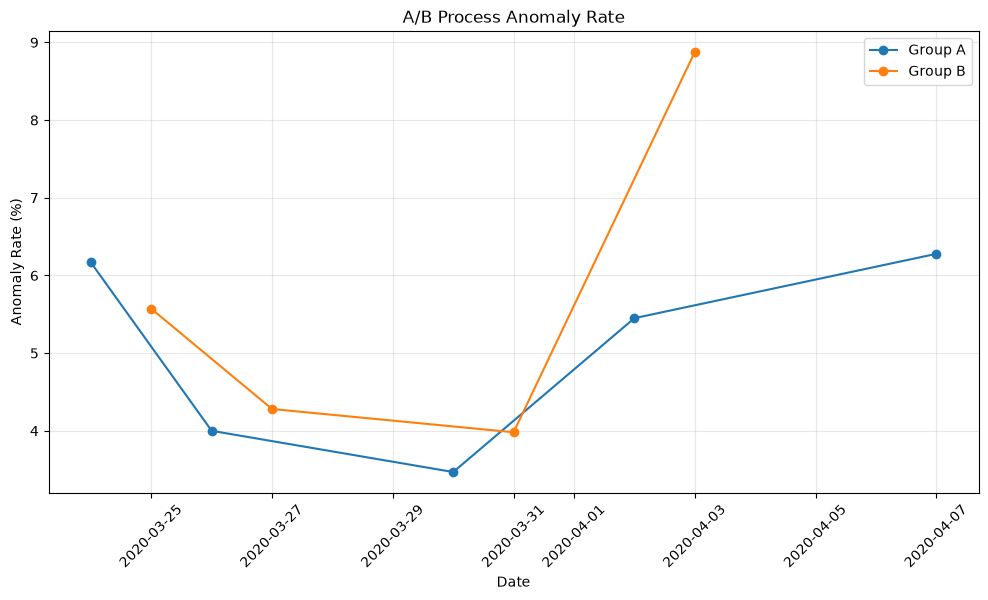

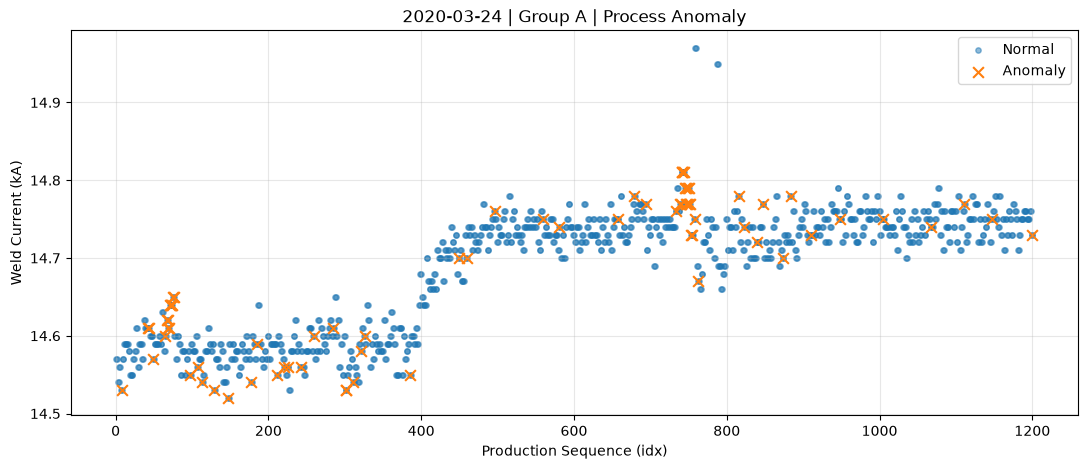

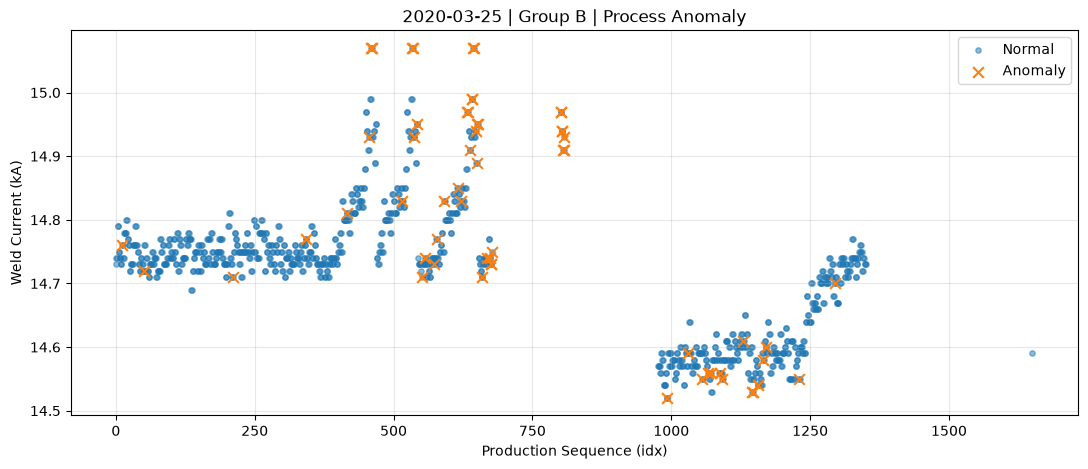

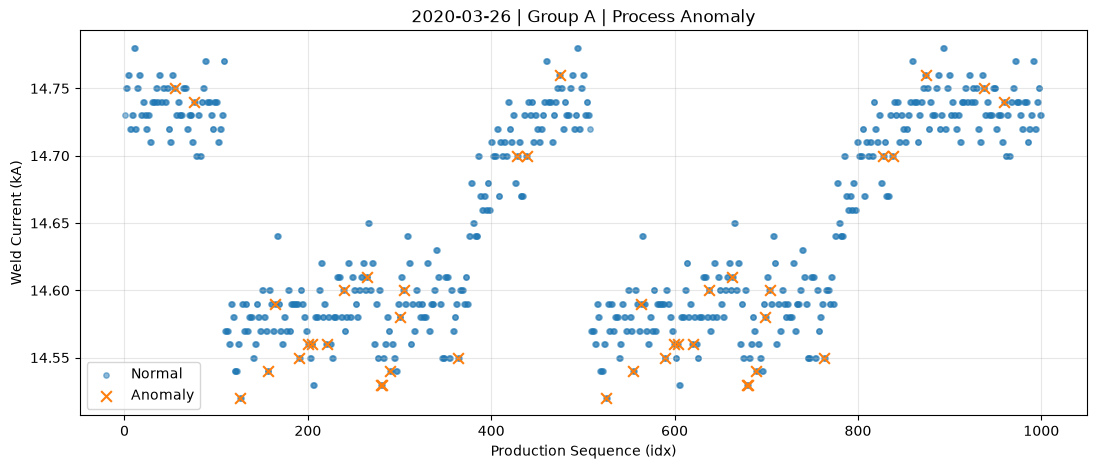

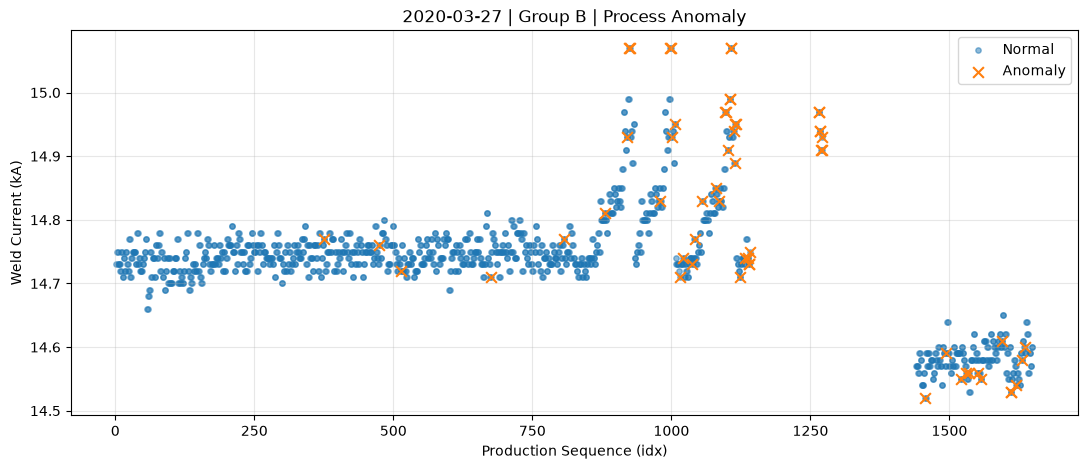

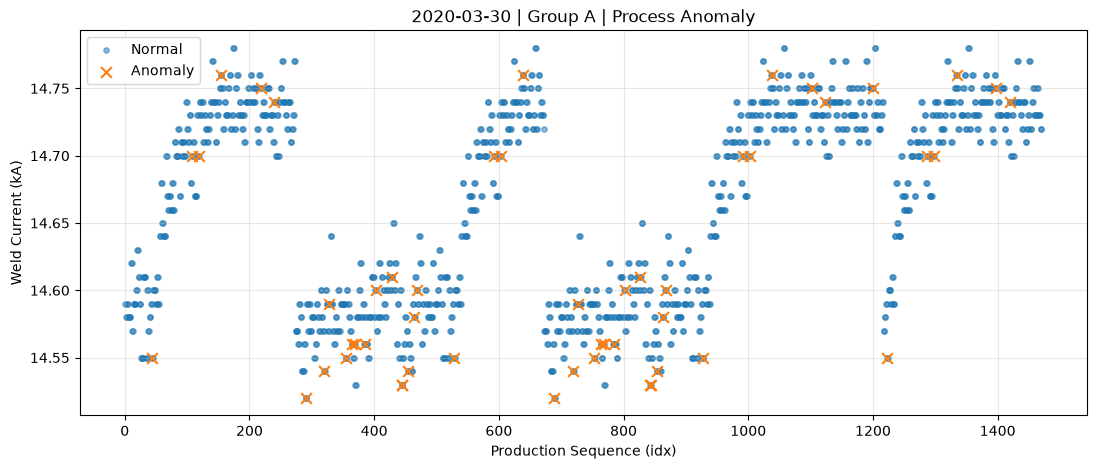

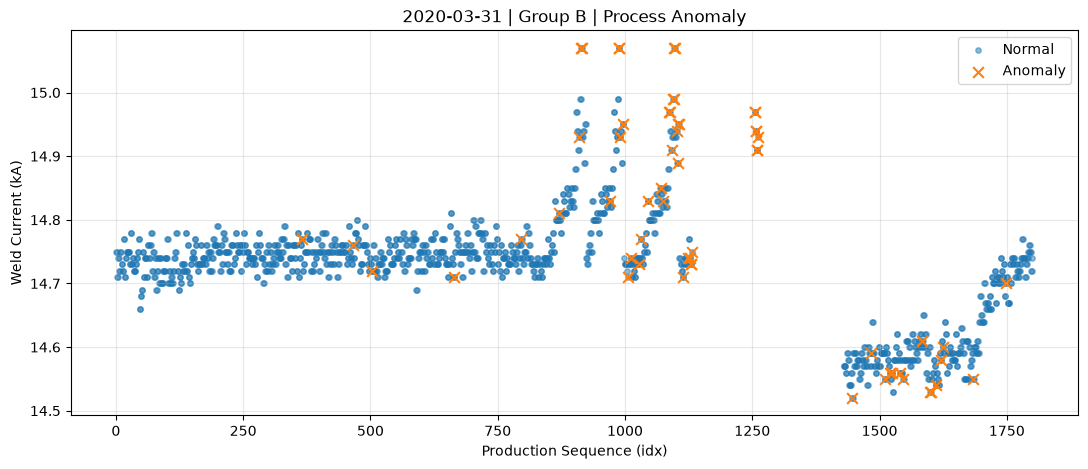

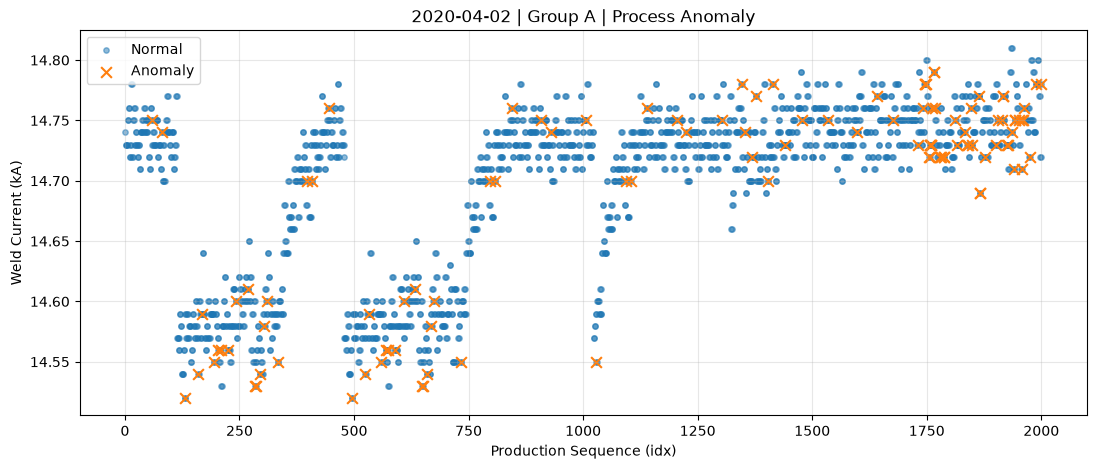

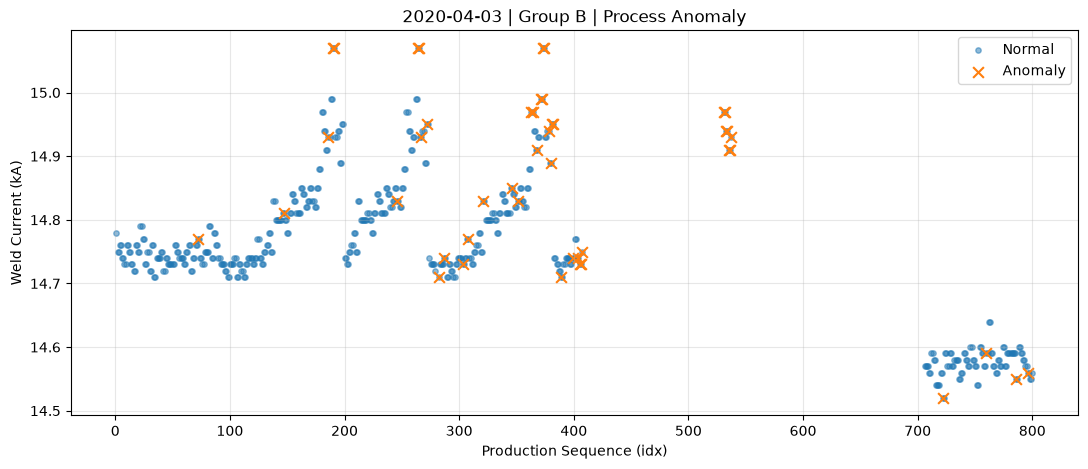

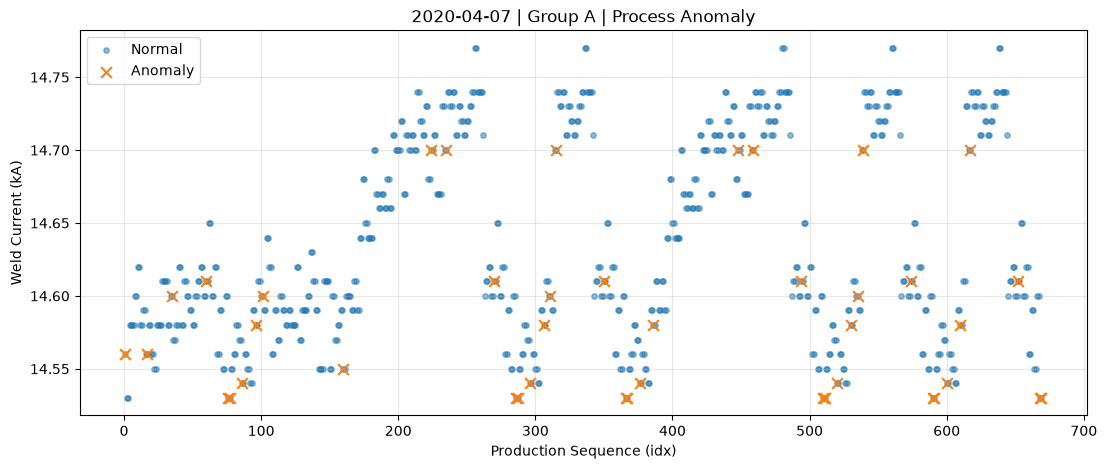


=== A/B : 정상 vs 이상 공정조건 ===


weld force(bar)                weld current(kA)                 \
                         mean     std median             mean     std median   
Group Anomaly                                                                  
A     False            2.3406  0.0264   2.34          14.6734  0.0752  14.71   
      True             2.3225  0.0540   2.33          14.6516  0.0933  14.64   
B     False            2.3309  0.0537   2.31          14.7279  0.0864  14.74   
      True             2.4632  0.1803   2.46          14.8162  0.1681  14.83   

              weld Voltage(v)                weld time(ms)                 
                         mean     std median          mean     std median  
Group Anomaly                                                              
A     False            2.7019  0.0040  2.701       71.7484  0.5683   72.0  
      True             2.7041  0.0062  2.704       71.3679  1.3008   71.0  
B     False            2.7024  0.0046  2.702       71.7214  0.5946   72.0  
      True             2.6949  0.0548  2.702       71.6982  1.1705   72.0

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest


# =========================================================
# 1. 사용할 변수
# =========================================================

features = [
    "weld force(bar)",
    "weld current(kA)",
    "weld Voltage(v)",
    "weld time(ms)"
]

df["Date"] = pd.to_datetime(df["Date"])

# Force 2.xx 공정만 사용
data = df[
    (df["weld force(bar)"] >= 2.0) &
    (df["weld force(bar)"] < 3.0)
].copy()

data = data.dropna(subset=features + ["Group"])


# =========================================================
# 2. A / B 각각 따로 이상 탐지
# =========================================================

results = []

for group in ["A", "B"]:

    g = data[data["Group"] == group].copy()

    # -------------------------
    # Scaling
    # -------------------------
    scaler = StandardScaler()

    X = scaler.fit_transform(g[features])


    # -------------------------
    # Isolation Forest
    # -------------------------
    model = IsolationForest(
        n_estimators=300,
        contamination=0.05,
        random_state=42
    )

    prediction = model.fit_predict(X)

    # -1 = 이상
    #  1 = 정상
    g["Anomaly"] = prediction == -1

    # 값이 클수록 이상하도록 변환
    g["Anomaly_Score"] = -model.score_samples(X)

    results.append(g)


result_df = pd.concat(results).sort_index()


# =========================================================
# 3. 날짜별 이상률
# =========================================================

daily = (
    result_df
    .groupby(["Date", "Group"])
    .agg(
        Total_Rows=("Anomaly", "size"),
        Anomaly_Count=("Anomaly", "sum"),
        Mean_Anomaly_Score=("Anomaly_Score", "mean"),
        Max_Anomaly_Score=("Anomaly_Score", "max")
    )
    .reset_index()
)

daily["Anomaly_Rate"] = (
    daily["Anomaly_Count"]
    / daily["Total_Rows"]
    * 100
)

print("\n=== 날짜별 A/B 공정 이상 ===")

display(
    daily.round(4)
)


# =========================================================
# 4. 가장 이상한 행 확인
# =========================================================

top_anomaly = (
    result_df
    .sort_values("Anomaly_Score", ascending=False)
    [
        [
            "Date",
            "idx",
            "Group",
            "weld force(bar)",
            "weld current(kA)",
            "weld Voltage(v)",
            "weld time(ms)",
            "Anomaly_Score",
            "Anomaly"
        ]
    ]
    .head(30)
)

print("\n=== 가장 이상한 공정 조건 30개 ===")

display(top_anomaly.round(4))


# =========================================================
# 5. 날짜별 이상률 그래프
# =========================================================

plt.figure(figsize=(12, 6))

for group in ["A", "B"]:

    temp = daily[daily["Group"] == group]

    plt.plot(
        temp["Date"],
        temp["Anomaly_Rate"],
        marker="o",
        label=f"Group {group}"
    )

plt.xlabel("Date")
plt.ylabel("Anomaly Rate (%)")
plt.title("A/B Process Anomaly Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.show()


# =========================================================
# 6. 핵심: idx 위치에 이상치 표시
# =========================================================

for date in sorted(result_df["Date"].unique()):

    temp = (
        result_df[result_df["Date"] == date]
        .sort_values("idx")
    )

    group = temp["Group"].iloc[0]

    plt.figure(figsize=(13, 5))

    # 전체 Current
    plt.scatter(
        temp["idx"],
        temp["weld current(kA)"],
        s=15,
        alpha=0.5,
        label="Normal"
    )

    # 이상치
    anomaly = temp[temp["Anomaly"]]

    plt.scatter(
        anomaly["idx"],
        anomaly["weld current(kA)"],
        s=60,
        marker="x",
        label="Anomaly"
    )

    plt.title(
        f"{pd.Timestamp(date).date()} | Group {group} | Process Anomaly"
    )

    plt.xlabel("Production Sequence (idx)")
    plt.ylabel("Weld Current (kA)")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()


# =========================================================
# 7. 이상치 vs 정상값 평균 비교
# =========================================================

comparison = (
    result_df
    .groupby(["Group", "Anomaly"])[features]
    .agg(["mean", "std", "median"])
)

print("\n=== A/B : 정상 vs 이상 공정조건 ===")

display(comparison.round(4))

In [5]:
import pandas as pd
import numpy as np

# 엑셀 불러오기
file_path = "../YSJ-001/Welding Data Set_01.xlsx"
df = pd.read_excel(file_path)

# 실제 컬럼명 확인
print(df.columns.tolist())

# 데이터 확인
display(df.head())

['idx', 'Machine_Name', 'Item No', 'working time', 'Thickness 1(mm)', 'Thickness 2(mm)', 'weld force(bar)', 'weld current(kA)', 'weld Voltage(v)', 'weld time(ms)']


,idx,Machine_Name,Item No,working time,Thickness 1(mm),Thickness 2(mm),weld force(bar),weld current(kA),weld Voltage(v),weld time(ms)
0,1,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.33,14.57,2.701,72.0
1,2,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.57,2.701,72.0
2,3,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,71.0
3,4,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,72.0
4,5,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.56,2.704,72.0


In [13]:
import pandas as pd

file_path = "../YSJ-002/Welding Data Set_01.xlsx"

df = pd.read_excel(file_path)

df["Date"] = pd.to_datetime(df["working time"])

print("로드 성공:", df.shape)
print(df.columns.tolist())
display(df.head())

로드 성공: (11939, 11)
['idx', 'Machine_Name', 'Item No', 'working time', 'Thickness 1(mm)', 'Thickness 2(mm)', 'weld force(bar)', 'weld current(kA)', 'weld Voltage(v)', 'weld time(ms)', 'Date']


,idx,Machine_Name,Item No,working time,Thickness 1(mm),Thickness 2(mm),weld force(bar),weld current(kA),weld Voltage(v),weld time(ms),Date
0,1,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.33,14.57,2.701,72.0,2020-03-24
1,2,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.57,2.701,72.0,2020-03-24
2,3,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,71.0,2020-03-24
3,4,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,72.0,2020-03-24
4,5,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.56,2.704,72.0,2020-03-24


데이터 로드 성공
전체 행: 11939

=== A/B 데이터 ===
Group
A    6339
B    5600
Name: count, dtype: int64

Group A
전체 : 6339
Threshold : 1.7075
AE 이상 : 317
이상 비율 : 5.0 %

Group B
전체 : 5600
Threshold : 2.7719
AE 이상 : 278
이상 비율 : 4.96 %

전체 AE 결과
전체 데이터 : 11939
AE 이상 : 595
AE 이상 데이터 개수 : 595

실루엣 점수


,K,Silhouette_Score
0,2,0.4188
1,3,0.4882
2,4,0.5234
3,5,0.5011
4,6,0.5239



4개 이상 패턴 개수


,Count
Cluster,
1,188
2,173
3,162
4,72



정상 vs AE 이상 Cluster 1~4


...

Group,A,B
Cluster,,
1,90.43,9.57
2,0.58,99.42
3,90.12,9.88
4,0.00,100.00



날짜별 Cluster 발생 개수


Cluster,1,2,3,4
Date,,,,
2020-03-24,39,1,49,0
2020-03-25,5,43,4,18
2020-03-26,20,0,13,0
2020-03-27,4,43,4,18
2020-03-30,31,0,15,0
2020-03-31,5,43,4,18
2020-04-02,61,0,57,0
2020-04-03,4,43,4,18
2020-04-07,19,0,12,0



Cluster별 Reconstruction Error


,count,mean,median,max
Cluster,,,,
1,188,2.3341,2.1429,6.4331
2,173,3.7068,3.5417,6.1172
3,162,2.8648,2.3603,7.1461
4,72,11.2953,12.9416,14.0838


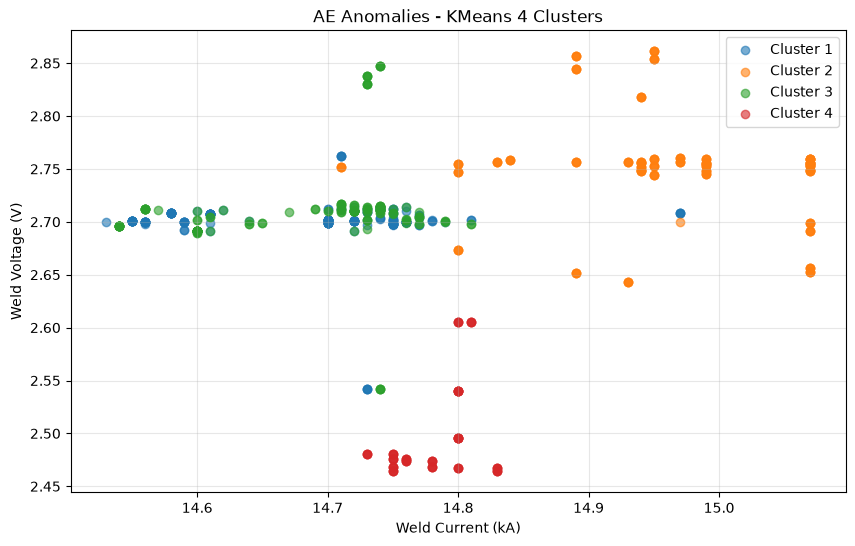

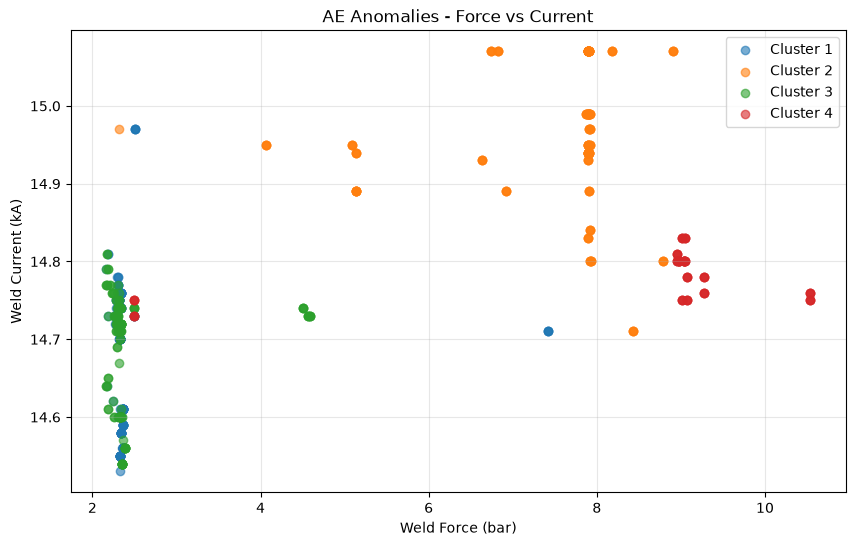


최종 결과
AE 이상치 → 4개 Cluster


,Date,idx,Group,weld force(bar),weld current(kA),weld Voltage(v),weld time(ms),Reconstruction_Error,Cluster
70,2020-03-24,71,A,2.17,14.64,2.701,71.0,6.433115,1
745,2020-03-24,746,A,2.16,14.79,2.700,71.0,6.406835,1
7013,2020-03-25,675,B,2.49,14.73,2.542,71.0,5.713526,1
8827,2020-03-27,1139,B,2.49,14.73,2.542,71.0,5.713526,1
10467,2020-03-31,1129,B,2.49,14.73,2.542,71.0,5.713526,1
...,...,...,...,...,...,...,...,...,...
11561,2020-04-03,423,B,8.95,14.81,2.605,71.0,4.419683,4
7030,2020-03-25,692,B,8.95,14.80,2.605,72.0,4.124798,4
8844,2020-03-27,1156,B,8.95,14.80,2.605,72.0,4.124798,4
10484,2020-03-31,1146,B,8.95,14.80,2.605,72.0,4.124798,4


In [16]:
# ============================================================
# 전체 코드
# 데이터 로드 → A/B 분류 → AutoEncoder → 이상치 → K-Means 4분류
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# ============================================================
# 1. 데이터 불러오기
# A.ipynb와 Excel 파일이 같은 폴더
# ============================================================

file_path = "Welding Data Set_01.xlsx"

df = pd.read_excel(file_path)

# working time을 날짜로 사용
df["Date"] = pd.to_datetime(df["working time"])


# ============================================================
# 2. 사용할 4개 공정 변수
# ============================================================

features = [
    "weld force(bar)",
    "weld current(kA)",
    "weld Voltage(v)",
    "weld time(ms)"
]

df = df.dropna(subset=features).copy()

print("데이터 로드 성공")
print("전체 행:", len(df))


# ============================================================
# 3. 지금까지 확인한 A/B 공정 구분
#
# A = Force 7~8 공정이 없는 생산일
# B = Force 7~8 공정이 있는 생산일
# ============================================================

B_dates = pd.to_datetime([
    "2020-03-25",
    "2020-03-27",
    "2020-03-31",
    "2020-04-03"
])

df["Group"] = np.where(
    df["Date"].isin(B_dates),
    "B",
    "A"
)

print("\n=== A/B 데이터 ===")
print(df["Group"].value_counts())


# ============================================================
# 4. A/B 각각 AutoEncoder
# ============================================================

result_list = []

for group in ["A", "B"]:

    g = df[df["Group"] == group].copy()

    X = g[features].values

    # 표준화
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # AutoEncoder 형태
    # 4 → 3 → 2 → 3 → 4
    ae = MLPRegressor(
        hidden_layer_sizes=(3, 2, 3),
        activation="relu",
        solver="adam",
        max_iter=1000,
        random_state=42
    )

    # 입력값을 자기 자신으로 복원
    ae.fit(X_scaled, X_scaled)

    # 복원
    X_pred = ae.predict(X_scaled)

    # Reconstruction Error
    error = np.mean(
        (X_scaled - X_pred) ** 2,
        axis=1
    )

    g["Reconstruction_Error"] = error

    # 상위 5%를 AE 이상 후보로 설정
    threshold = np.percentile(error, 95)

    g["Anomaly"] = (
        g["Reconstruction_Error"] > threshold
    )

    print("\n============================")
    print("Group", group)
    print("============================")
    print("전체 :", len(g))
    print("Threshold :", round(threshold, 4))
    print("AE 이상 :", g["Anomaly"].sum())
    print(
        "이상 비율 :",
        round(g["Anomaly"].mean() * 100, 2),
        "%"
    )

    result_list.append(g)


# ============================================================
# 5. A/B AE 결과 합치기
# ============================================================

result = pd.concat(
    result_list,
    ignore_index=True
)

print("\n============================")
print("전체 AE 결과")
print("============================")

print("전체 데이터 :", len(result))
print("AE 이상 :", result["Anomaly"].sum())


# ============================================================
# 6. AE 이상치만 추출
# ============================================================

anomaly = result[
    result["Anomaly"] == True
].copy()

print("AE 이상 데이터 개수 :", len(anomaly))


# ============================================================
# 7. 이상치만 다시 표준화
# ============================================================

cluster_scaler = StandardScaler()

X_anomaly = cluster_scaler.fit_transform(
    anomaly[features]
)


# ============================================================
# 8. K=2~6 실루엣 점수
# 실제로 몇 군집이 자연스러운지도 확인
# ============================================================

silhouette_results = []

for k in range(2, 7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_anomaly)

    score = silhouette_score(
        X_anomaly,
        labels
    )

    silhouette_results.append(
        [k, score]
    )

silhouette_df = pd.DataFrame(
    silhouette_results,
    columns=["K", "Silhouette_Score"]
)

print("\n============================")
print("실루엣 점수")
print("============================")

display(silhouette_df.round(4))


# ============================================================
# 9. 이상치를 K-Means로 4개 군집으로 분류
# ============================================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

anomaly["Cluster"] = (
    kmeans.fit_predict(X_anomaly) + 1
)


# ============================================================
# 10. 각 Cluster 개수
# ============================================================

cluster_count = (
    anomaly["Cluster"]
    .value_counts()
    .sort_index()
)

print("\n============================")
print("4개 이상 패턴 개수")
print("============================")

display(
    cluster_count
    .rename("Count")
    .to_frame()
)


# ============================================================
# 11. 정상 vs Cluster 1~4 평균 비교
# 가장 중요한 표
# ============================================================

normal = result[
    result["Anomaly"] == False
].copy()

normal_mean = (
    normal[features]
    .mean()
    .to_frame()
    .T
)

normal_mean.index = ["Normal"]

cluster_mean = (
    anomaly
    .groupby("Cluster")[features]
    .mean()
)

cluster_mean.index = [
    f"Cluster {i}"
    for i in cluster_mean.index
]

comparison = pd.concat(
    [normal_mean, cluster_mean]
)

print("\n==============================================")
print("정상 vs AE 이상 Cluster 1~4")
print("==============================================")

display(comparison.round(4))


# ============================================================
# 12. 정상에서 얼마나 벗어났는지
# ============================================================

normal_values = normal[features].mean()

difference = (
    anomaly
    .groupby("Cluster")[features]
    .mean()
    - normal_values
)

difference.index = [
    f"Cluster {i}"
    for i in difference.index
]

print("\n==============================================")
print("정상 평균 대비 각 Cluster 차이")
print(" + = 정상보다 높음 / - = 정상보다 낮음")
print("==============================================")

display(difference.round(4))


# ============================================================
# 13. Cluster별 상세 통계
# ============================================================

cluster_summary = (
    anomaly
    .groupby("Cluster")[features]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)

print("\n==============================================")
print("Cluster별 상세 공정 조건")
print("==============================================")

display(cluster_summary.round(4))


# ============================================================
# 14. Cluster별 A/B 공정 개수
# ============================================================

ab_count = pd.crosstab(
    anomaly["Cluster"],
    anomaly["Group"]
)

print("\n==============================================")
print("Cluster별 A/B 공정 개수")
print("==============================================")

display(ab_count)


# ============================================================
# 15. Cluster별 A/B 비율
# ============================================================

ab_ratio = (
    pd.crosstab(
        anomaly["Cluster"],
        anomaly["Group"],
        normalize="index"
    ) * 100
)

print("\n==============================================")
print("Cluster별 A/B 공정 비율 (%)")
print("==============================================")

display(ab_ratio.round(2))


# ============================================================
# 16. 날짜별 Cluster 발생 개수
# ============================================================

daily_cluster = pd.crosstab(
    anomaly["Date"],
    anomaly["Cluster"]
)

print("\n==============================================")
print("날짜별 Cluster 발생 개수")
print("==============================================")

display(daily_cluster)


# ============================================================
# 17. Cluster별 Reconstruction Error
# ============================================================

cluster_error = (
    anomaly
    .groupby("Cluster")["Reconstruction_Error"]
    .agg([
        "count",
        "mean",
        "median",
        "max"
    ])
)

print("\n==============================================")
print("Cluster별 Reconstruction Error")
print("==============================================")

display(cluster_error.round(4))


# ============================================================
# 18. Current vs Voltage 시각화
# ============================================================

plt.figure(figsize=(10, 6))

for c in sorted(anomaly["Cluster"].unique()):

    temp = anomaly[
        anomaly["Cluster"] == c
    ]

    plt.scatter(
        temp["weld current(kA)"],
        temp["weld Voltage(v)"],
        label=f"Cluster {c}",
        alpha=0.6
    )

plt.xlabel("Weld Current (kA)")
plt.ylabel("Weld Voltage (V)")
plt.title("AE Anomalies - KMeans 4 Clusters")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ============================================================
# 19. Force vs Current 시각화
# ============================================================

plt.figure(figsize=(10, 6))

for c in sorted(anomaly["Cluster"].unique()):

    temp = anomaly[
        anomaly["Cluster"] == c
    ]

    plt.scatter(
        temp["weld force(bar)"],
        temp["weld current(kA)"],
        label=f"Cluster {c}",
        alpha=0.6
    )

plt.xlabel("Weld Force (bar)")
plt.ylabel("Weld Current (kA)")
plt.title("AE Anomalies - Force vs Current")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ============================================================
# 20. 최종 결과
# ============================================================

final_cols = [
    "Date",
    "idx",
    "Group",
    "weld force(bar)",
    "weld current(kA)",
    "weld Voltage(v)",
    "weld time(ms)",
    "Reconstruction_Error",
    "Cluster"
]

final_result = anomaly[
    final_cols
].sort_values(
    ["Cluster", "Reconstruction_Error"],
    ascending=[True, False]
)

print("\n==============================================")
print("최종 결과")
print("AE 이상치 → 4개 Cluster")
print("==============================================")

display(final_result)

=== 날짜별 / Cluster별 IDX 발생 구간 ===


C:\Users\sj789\AppData\Local\Temp\ipykernel_9864\2915870485.py:20: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(idx_summary.round(1))


,Date,Group,Cluster,Count,Min_idx,Max_idx,Mean_idx
0,2020-03-24,A,1,39,8,1147,558.4
1,2020-03-24,A,2,1,759,759,759.0
2,2020-03-24,A,3,49,41,1200,539.0
3,2020-03-25,B,1,5,633,1230,888.2
4,2020-03-25,B,2,43,695,971,887.5
5,2020-03-25,B,3,4,674,823,785.0
6,2020-03-25,B,4,18,676,693,684.5
7,2020-03-26,A,1,20,55,988,527.3
8,2020-03-26,A,3,13,12,959,480.2
9,2020-03-27,B,1,4,1097,1530,1266.8


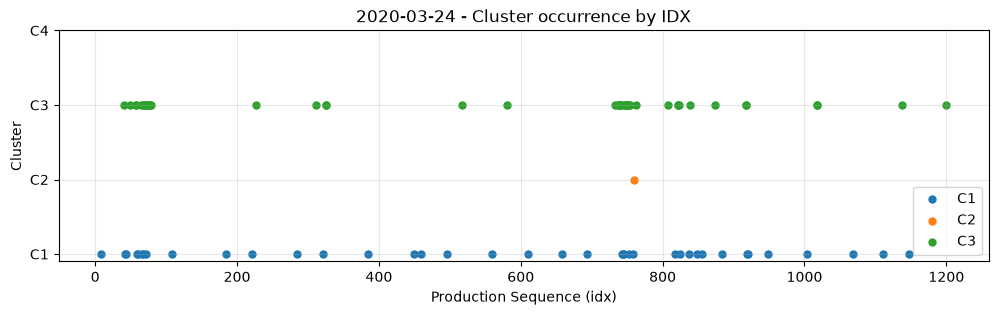

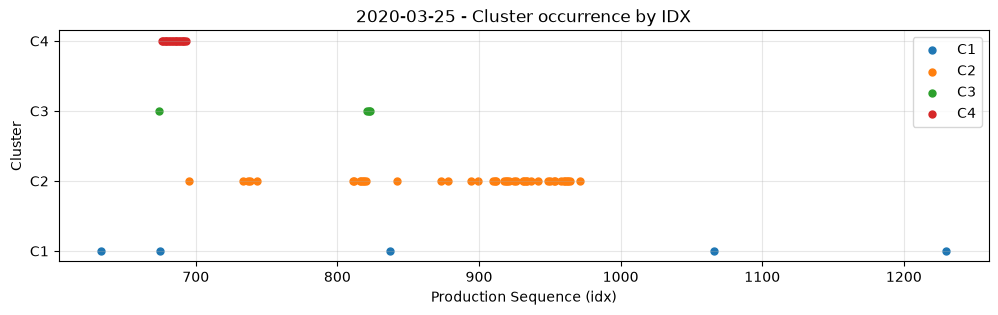

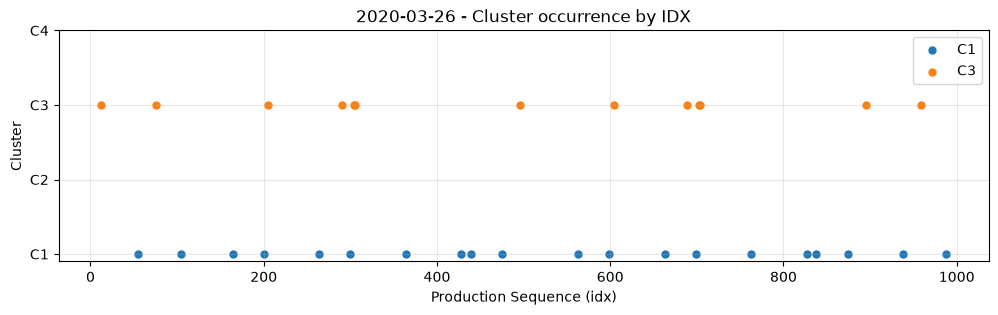

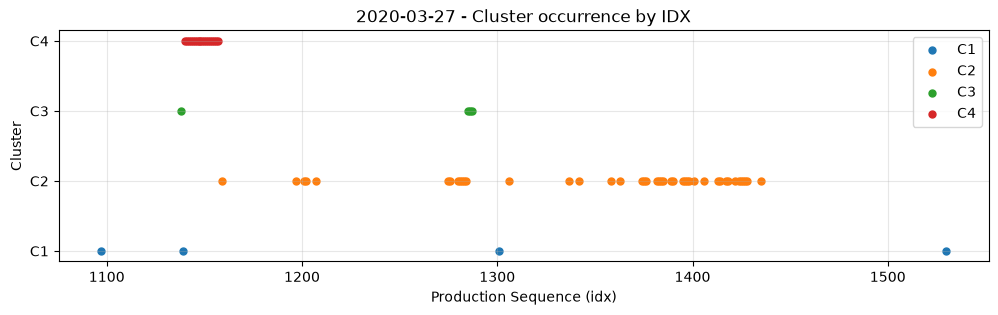

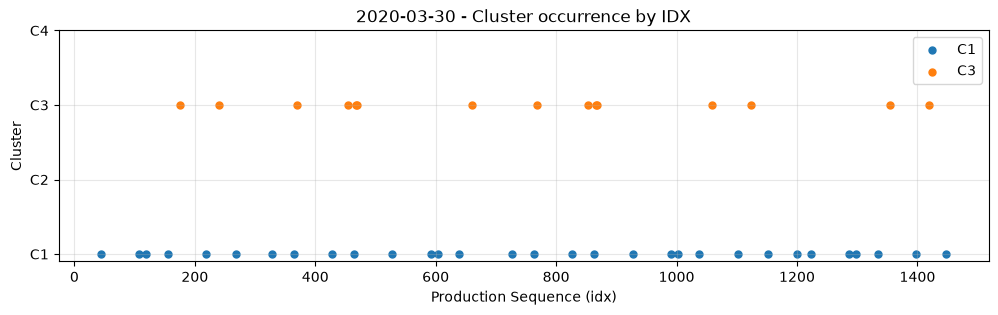

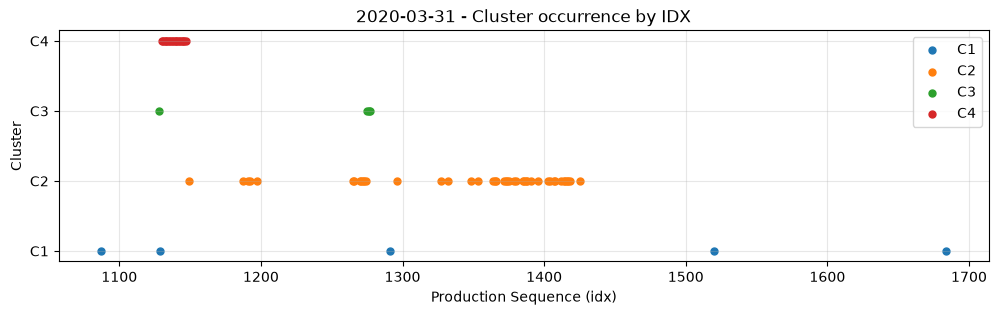

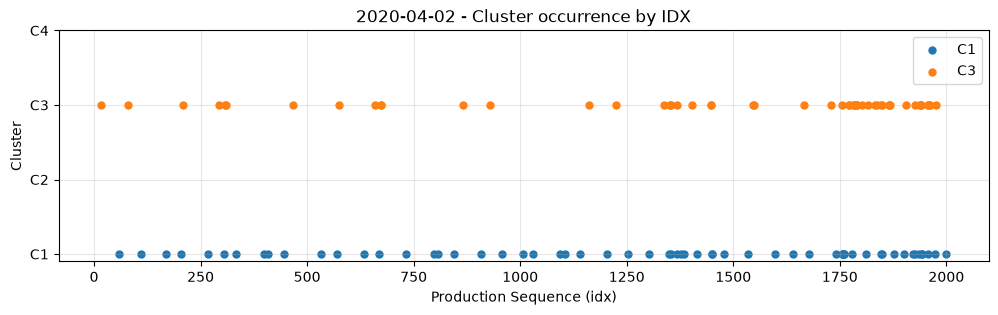

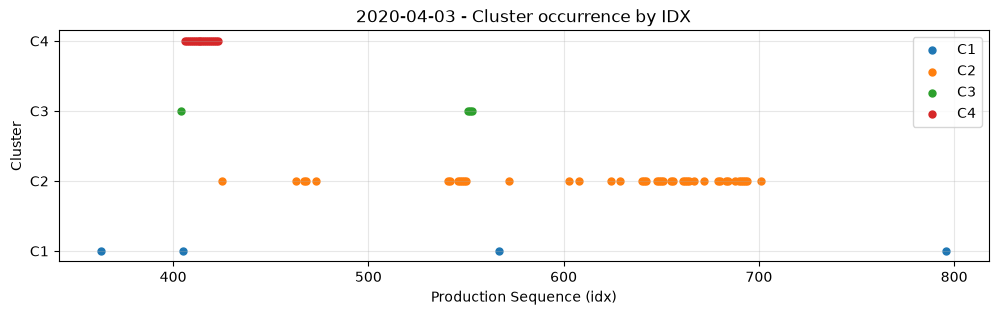

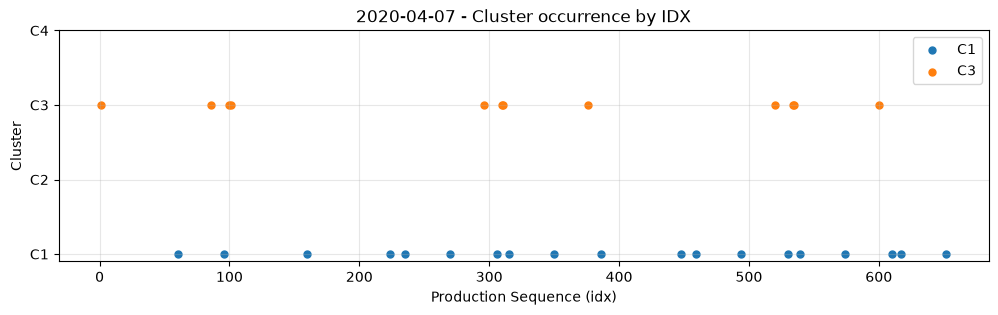

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Cluster 이상치만 사용
x = final_result.copy()

# 날짜별 + Cluster별 idx 범위
idx_summary = (
    x.groupby(["Date", "Group", "Cluster"])
     .agg(
         Count=("idx", "size"),
         Min_idx=("idx", "min"),
         Max_idx=("idx", "max"),
         Mean_idx=("idx", "mean")
     )
     .reset_index()
)

print("=== 날짜별 / Cluster별 IDX 발생 구간 ===")
display(idx_summary.round(1))


# ==========================================
# 날짜별로 C1~C4가 어디서 발생했는지 그림
# ==========================================

dates = sorted(x["Date"].unique())

for date in dates:

    temp = x[x["Date"] == date].sort_values("idx")

    plt.figure(figsize=(12, 3))

    for c in sorted(temp["Cluster"].unique()):

        t = temp[temp["Cluster"] == c]

        plt.scatter(
            t["idx"],
            [c] * len(t),
            label=f"C{c}",
            s=25
        )

    plt.xlabel("Production Sequence (idx)")
    plt.ylabel("Cluster")
    plt.yticks([1, 2, 3, 4], ["C1", "C2", "C3", "C4"])
    plt.title(f"{pd.to_datetime(date).date()} - Cluster occurrence by IDX")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

1. 날짜별 C4 / C2 실제 IDX

DATE : 2020-03-25
C4 개수 : 18
C4 IDX : [676 677 678 679 680 681 682 683 684 685 686 687 688 689 690 691 692 693]

C2 개수 : 43
C2 IDX : [695 733 737 738 743 811 812 816 817 818 819 820 842 873 878 894 899 910
 911 912 918 919 920 921 925 926 931 932 933 934 937 942 949 950 953 954
 958 960 961 962 963 964 971]

DATE : 2020-03-27
C4 개수 : 18
C4 IDX : [1140 1141 1142 1143 1144 1145 1146 1147 1148 1149 1150 1151 1152 1153
 1154 1155 1156 1157]

C2 개수 : 43
C2 IDX : [1159 1197 1201 1202 1207 1275 1276 1280 1281 1282 1283 1284 1306 1337
 1342 1358 1363 1374 1375 1376 1382 1383 1384 1385 1389 1390 1395 1396
 1397 1398 1401 1406 1413 1414 1417 1418 1422 1424 1425 1426 1427 1428
 1435]

DATE : 2020-03-31
C4 개수 : 18
C4 IDX : [1130 1131 1132 1133 1134 1135 1136 1137 1138 1139 1140 1141 1142 1143
 1144 1145 1146 1147]

C2 개수 : 43
C2 IDX : [1149 1187 1191 1192 1197 1265 1266 1270 1271 1272 1273 1274 1296 1327
 1332 1348 1353 1364 1365 1366 1372 1373 1374 1375 1379 1380 1385 1386


,Date,Count,Start_idx,End_idx,Span,All_Consecutive
0,2020-03-25,18,676,693,18,True
1,2020-03-27,18,1140,1157,18,True
2,2020-03-31,18,1130,1147,18,True
3,2020-04-03,18,406,423,18,True




3. C2 IDX 간격

DATE : 2020-03-25
C2 count : 43
C2 idx:
[695 733 737 738 743 811 812 816 817 818 819 820 842 873 878 894 899 910
 911 912 918 919 920 921 925 926 931 932 933 934 937 942 949 950 953 954
 958 960 961 962 963 964 971]
C2 idx diff:
[38  4  1  5 68  1  4  1  1  1  1 22 31  5 16  5 11  1  1  6  1  1  1  4
  1  5  1  1  1  3  5  7  1  3  1  4  2  1  1  1  1  7]
가장 많이 나타난 간격: [1]
평균 간격: 6.57

DATE : 2020-03-27
C2 count : 43
C2 idx:
[1159 1197 1201 1202 1207 1275 1276 1280 1281 1282 1283 1284 1306 1337
 1342 1358 1363 1374 1375 1376 1382 1383 1384 1385 1389 1390 1395 1396
 1397 1398 1401 1406 1413 1414 1417 1418 1422 1424 1425 1426 1427 1428
 1435]
C2 idx diff:
[38  4  1  5 68  1  4  1  1  1  1 22 31  5 16  5 11  1  1  6  1  1  1  4
  1  5  1  1  1  3  5  7  1  3  1  4  2  1  1  1  1  7]
가장 많이 나타난 간격: [1]
평균 간격: 6.57

DATE : 2020-03-31
C2 count : 43
C2 idx:
[1149 1187 1191 1192 1197 1265 1266 1270 1271 1272 1273 1274 1296 1327
 1332 1348 1353 1364 1365 1366 1372 1373 1374 1375 

,IDX_Difference,Count
0,1,84
1,2,4
2,3,8
3,4,16
4,5,20
5,6,4
6,7,8
7,11,4
8,16,4
9,22,4




5. C4 → C2 위치관계


,Date,C4_Start,C4_End,C4_Count,C2_Start,C2_Count,Start_Difference,Transition_Gap
0,2020-03-25,676,693,18,695,43,19,2
1,2020-03-27,1140,1157,18,1159,43,19,2
2,2020-03-31,1130,1147,18,1149,43,19,2
3,2020-04-03,406,423,18,425,43,19,2




6. C4 시작점 기준 상대 IDX

DATE : 2020-03-25
C4 Relative IDX: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
C2 Relative IDX: [ 19  57  61  62  67 135 136 140 141 142 143 144 166 197 202 218 223 234
 235 236 242 243 244 245 249 250 255 256 257 258 261 266 273 274 277 278
 282 284 285 286 287 288 295]

DATE : 2020-03-27
C4 Relative IDX: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
C2 Relative IDX: [ 19  57  61  62  67 135 136 140 141 142 143 144 166 197 202 218 223 234
 235 236 242 243 244 245 249 250 255 256 257 258 261 266 273 274 277 278
 282 284 285 286 287 288 295]

DATE : 2020-03-31
C4 Relative IDX: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
C2 Relative IDX: [ 19  57  61  62  67 135 136 140 141 142 143 144 166 197 202 218 223 234
 235 236 242 243 244 245 249 250 255 256 257 258 261 266 273 274 277 278
 282 284 285 286 287 288 295]

DATE : 2020-04-03
C4 Relative IDX: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
C2 Relative IDX: [ 19  57  61  

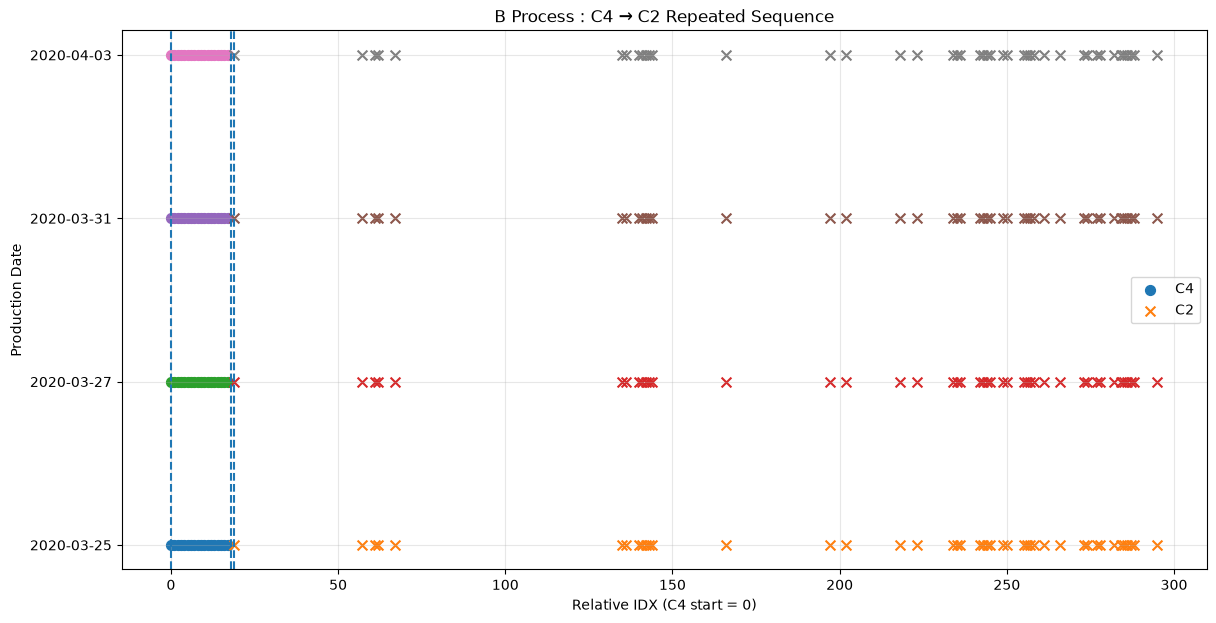



7. 날짜별 C2 상대 IDX 동일성 검사
2020-03-25 vs 2020-03-27 → 완전히 동일
2020-03-25 vs 2020-03-31 → 완전히 동일
2020-03-25 vs 2020-04-03 → 완전히 동일
2020-03-27 vs 2020-03-31 → 완전히 동일
2020-03-27 vs 2020-04-03 → 완전히 동일
2020-03-31 vs 2020-04-03 → 완전히 동일


8. 4개 날짜 모두 반복되는 상대 IDX


,Cluster,Relative_idx,Number_of_Dates
0,2,19,4
1,2,57,4
2,2,61,4
3,2,62,4
4,2,67,4
...,...,...,...
56,4,13,4
57,4,14,4
58,4,15,4
59,4,16,4




9. Cluster별 상대 IDX 반복률
C4: 18/18 = 100.0 %
C2: 43/43 = 100.0 %


In [18]:
# ============================================================
# B공정 C4 → C2 반복구조 정밀 검증
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. B공정 이상치만 추출
# ============================================================

b = anomaly[
    anomaly["Group"] == "B"
].copy()

b = b.sort_values(
    ["Date", "idx"]
)


# ============================================================
# 2. 날짜별 C4 / C2 실제 IDX 전부 출력
# ============================================================

print("=" * 70)
print("1. 날짜별 C4 / C2 실제 IDX")
print("=" * 70)

for date in sorted(b["Date"].unique()):

    temp = b[b["Date"] == date]

    c4_idx = (
        temp[temp["Cluster"] == 4]["idx"]
        .sort_values()
        .to_numpy()
    )

    c2_idx = (
        temp[temp["Cluster"] == 2]["idx"]
        .sort_values()
        .to_numpy()
    )

    print("\nDATE :", pd.to_datetime(date).date())

    print("C4 개수 :", len(c4_idx))
    print("C4 IDX :", c4_idx)

    print("\nC2 개수 :", len(c2_idx))
    print("C2 IDX :", c2_idx)


# ============================================================
# 3. C4가 진짜 연속 18개인지 확인
#
# diff = 1이면 바로 다음 생산품이라는 뜻
# ============================================================

print("\n")
print("=" * 70)
print("2. C4 연속성 검증")
print("=" * 70)

c4_results = []

for date in sorted(b["Date"].unique()):

    temp = b[
        (b["Date"] == date) &
        (b["Cluster"] == 4)
    ].sort_values("idx")

    idx = temp["idx"].to_numpy()

    diff = np.diff(idx)

    if len(idx) > 0:

        consecutive = np.all(diff == 1)

        c4_results.append({
            "Date": pd.to_datetime(date).date(),
            "Count": len(idx),
            "Start_idx": idx.min(),
            "End_idx": idx.max(),
            "Span": idx.max() - idx.min() + 1,
            "All_Consecutive": consecutive
        })

c4_table = pd.DataFrame(c4_results)

display(c4_table)


# ============================================================
# 4. C2 IDX 간격 분석
#
# 핵심:
# 43개가 어떤 간격으로 반복되는지 확인
# ============================================================

print("\n")
print("=" * 70)
print("3. C2 IDX 간격")
print("=" * 70)

all_c2_diff = []

for date in sorted(b["Date"].unique()):

    temp = b[
        (b["Date"] == date) &
        (b["Cluster"] == 2)
    ].sort_values("idx")

    idx = temp["idx"].to_numpy()

    diff = np.diff(idx)

    print("\nDATE :", pd.to_datetime(date).date())

    print("C2 count :", len(idx))

    print("C2 idx:")
    print(idx)

    print("C2 idx diff:")
    print(diff)

    if len(diff) > 0:

        print(
            "가장 많이 나타난 간격:",
            pd.Series(diff).mode().tolist()
        )

        print(
            "평균 간격:",
            round(diff.mean(), 2)
        )

        all_c2_diff.extend(diff)


# ============================================================
# 5. 전체 B 날짜에서 C2 간격 빈도
# ============================================================

print("\n")
print("=" * 70)
print("4. 전체 B공정 C2 IDX 간격 빈도")
print("=" * 70)

diff_frequency = (
    pd.Series(all_c2_diff)
    .value_counts()
    .sort_index()
    .rename_axis("IDX_Difference")
    .reset_index(name="Count")
)

display(diff_frequency)


# ============================================================
# 6. 날짜별 C4 → C2 위치관계
# ============================================================

print("\n")
print("=" * 70)
print("5. C4 → C2 위치관계")
print("=" * 70)

transition_results = []

for date in sorted(b["Date"].unique()):

    temp = b[b["Date"] == date]

    c4 = (
        temp[temp["Cluster"] == 4]["idx"]
        .sort_values()
        .to_numpy()
    )

    c2 = (
        temp[temp["Cluster"] == 2]["idx"]
        .sort_values()
        .to_numpy()
    )

    if len(c4) > 0 and len(c2) > 0:

        transition_results.append({

            "Date":
                pd.to_datetime(date).date(),

            "C4_Start":
                c4.min(),

            "C4_End":
                c4.max(),

            "C4_Count":
                len(c4),

            "C2_Start":
                c2.min(),

            "C2_Count":
                len(c2),

            # C4 시작 → C2 시작
            "Start_Difference":
                c2.min() - c4.min(),

            # C4 종료 → C2 시작
            "Transition_Gap":
                c2.min() - c4.max()
        })

transition_table = pd.DataFrame(
    transition_results
)

display(transition_table)


# ============================================================
# 7. C4 시작점을 0으로 정렬
#
# 날짜가 달라도 같은 상대 위치에서
# C2가 발생하는지 확인
# ============================================================

print("\n")
print("=" * 70)
print("6. C4 시작점 기준 상대 IDX")
print("=" * 70)

aligned_list = []

for date in sorted(b["Date"].unique()):

    temp = b[b["Date"] == date].copy()

    c4 = temp[
        temp["Cluster"] == 4
    ]

    if len(c4) == 0:
        continue

    c4_start = c4["idx"].min()

    temp["Relative_idx"] = (
        temp["idx"] - c4_start
    )

    aligned_list.append(temp)

aligned = pd.concat(
    aligned_list,
    ignore_index=True
)


# ============================================================
# 8. 날짜별 상대 IDX 출력
# ============================================================

for date in sorted(aligned["Date"].unique()):

    temp = aligned[
        aligned["Date"] == date
    ]

    print("\nDATE :", pd.to_datetime(date).date())

    for cluster in [4, 2]:

        values = (
            temp[temp["Cluster"] == cluster]
            ["Relative_idx"]
            .sort_values()
            .to_numpy()
        )

        print(
            f"C{cluster} Relative IDX:",
            values
        )


# ============================================================
# 9. 가장 중요한 그래프
#
# C4 시작점을 전부 0으로 맞춰서
# 4개 날짜를 한 그래프에 표시
# ============================================================

plt.figure(figsize=(14, 7))

dates = sorted(
    aligned["Date"].unique()
)

for i, date in enumerate(dates):

    temp = aligned[
        aligned["Date"] == date
    ]

    for cluster in [4, 2]:

        t = temp[
            temp["Cluster"] == cluster
        ]

        plt.scatter(
            t["Relative_idx"],
            [i] * len(t),
            marker="o" if cluster == 4 else "x",
            s=50,
            label=(
                f"C{cluster}"
                if i == 0
                else None
            )
        )

plt.yticks(
    range(len(dates)),
    [
        str(pd.to_datetime(d).date())
        for d in dates
    ]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.axvline(
    18,
    linestyle="--"
)

plt.axvline(
    19,
    linestyle="--"
)

plt.xlabel(
    "Relative IDX (C4 start = 0)"
)

plt.ylabel(
    "Production Date"
)

plt.title(
    "B Process : C4 → C2 Repeated Sequence"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 10. 날짜 간 C2 상대 IDX가 완전히 같은지 검사
#
# 이게 매우 중요함.
# ============================================================

print("\n")
print("=" * 70)
print("7. 날짜별 C2 상대 IDX 동일성 검사")
print("=" * 70)

c2_patterns = {}

for date in sorted(
    aligned["Date"].unique()
):

    temp = aligned[
        (aligned["Date"] == date) &
        (aligned["Cluster"] == 2)
    ]

    pattern = tuple(
        temp["Relative_idx"]
        .sort_values()
        .astype(int)
        .tolist()
    )

    c2_patterns[
        str(pd.to_datetime(date).date())
    ] = pattern


pattern_dates = list(
    c2_patterns.keys()
)

for i in range(
    len(pattern_dates)
):

    for j in range(
        i + 1,
        len(pattern_dates)
    ):

        d1 = pattern_dates[i]
        d2 = pattern_dates[j]

        same = (
            c2_patterns[d1]
            ==
            c2_patterns[d2]
        )

        print(
            d1,
            "vs",
            d2,
            "→",
            "완전히 동일" if same else "다름"
        )


# ============================================================
# 11. 각 상대 IDX가 몇 날짜에서 반복됐는지
#
# 4이면 B 4일 모두 같은 위치에서 발생
# ============================================================

repeat_position = (
    aligned[
        aligned["Cluster"].isin([2, 4])
    ]

    .groupby(
        ["Cluster", "Relative_idx"]
    )

    ["Date"]
    .nunique()

    .reset_index(
        name="Number_of_Dates"
    )
)


print("\n")
print("=" * 70)
print("8. 4개 날짜 모두 반복되는 상대 IDX")
print("=" * 70)

perfect_repeat = repeat_position[
    repeat_position["Number_of_Dates"] == 4
]

display(perfect_repeat)


# ============================================================
# 12. 반복률 계산
# ============================================================

print("\n")
print("=" * 70)
print("9. Cluster별 상대 IDX 반복률")
print("=" * 70)

for cluster in [4, 2]:

    temp = repeat_position[
        repeat_position["Cluster"]
        == cluster
    ]

    n_total = len(temp)

    n_four = (
        temp["Number_of_Dates"] == 4
    ).sum()

    if n_total > 0:

        repeat_rate = (
            n_four /
            n_total *
            100
        )

        print(
            f"C{cluster}:",
            f"{n_four}/{n_total}",
            "=",
            round(repeat_rate, 2),
            "%"
        )

1. 완전 반복 위치 개수
Cluster
2    43
4    18
dtype: int64

2. 상대 IDX별 4일간 센서값


weld force(bar)                  weld current(kA)       \
                                mean  std   min   max             mean  std   
Cluster Relative_idx                                                          
2       19                      8.79  0.0  8.79  8.79            14.80  0.0   
        57                      6.64  0.0  6.64  6.64            14.93  0.0   
        61                      6.82  0.0  6.82  6.82            15.07  0.0   
        62                      6.74  0.0  6.74  6.74            15.07  0.0   
        67                      6.92  0.0  6.92  6.92            14.89  0.0   
...                              ...  ...   ...   ...              ...  ...   
4       13                      9.04  0.0  9.04  9.04            14.80  0.0   
        14                      8.98  0.0  8.98  8.98            14.80  0.0   
        15                      8.98  0.0  8.98  8.98            14.80  0.0   
        16                      8.95  0.0  8.95  8.95            14.80  0.0   
        17                      8.95  0.0  8.95  8.95            14.81  0.0   

                                   weld Voltage(v)                     \
                        min    max            mean  std    min    max   
Cluster Relative_idx                                                    
2       19            14.80  14.80           2.673  0.0  2.673  2.673   
        57            14.93  14.93           2.643  0.0  2.643  2.643   
        61            15.07  15.07           2.656  0.0  2.656  2.656   
        62            15.07  15.07           2.653  0.0  2.653  2.653   
        67            14.89  14.89           2.652  0.0  2.652  2.652   
...                     ...    ...             ...  ...    ...    ...   
4       13            14.80  14.80           2.496  0.0  2.496  2.496   
        14            14.80  14.80           2.540  0.0  2.540  2.540   
        15            14.80  14.80           2.540  0.0  2.540  2.540   
        16            14.80  14.80           2.605  0.0  2.605  2.605   
        17            14.81  14.81           2.605  0.0  2.605  2.605   

                     weld time(ms)                   
                              mean  std   min   max  
Cluster Relative_idx                                 
2       19                    73.0  0.0  73.0  73.0  
        57                    70.0  0.0  70.0  70.0  
        61                    72.0  0.0  72.0  72.0  
        62                    71.0  0.0  71.0  71.0  
        67                    70.0  0.0  70.0  70.0  
...                            ...  ...   ...   ...  
4       13                    72.0  0.0  72.0  72.0  
        14                    73.0  0.0  73.0  73.0  
        15                    71.0  0.0  71.0  71.0  
        16                    72.0  0.0  72.0  72.0  
        17                    71.0  0.0  71.0  71.0  

[61 rows x 16 columns]


3. 동일 Relative IDX의 날짜간 CV (%)
낮을수록 4일간 공정조건이 비슷함


,Cluster,Relative_idx,weld force(bar)_CV_%,weld current(kA)_CV_%,weld Voltage(v)_CV_%,weld time(ms)_CV_%
0,2,19,0.0,0.0,0.0,0.0
1,2,57,0.0,0.0,0.0,0.0
2,2,61,0.0,0.0,0.0,0.0
3,2,62,0.0,0.0,0.0,0.0
4,2,67,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
56,4,13,0.0,0.0,0.0,0.0
57,4,14,0.0,0.0,0.0,0.0
58,4,15,0.0,0.0,0.0,0.0
59,4,16,0.0,0.0,0.0,0.0



4. C2/C4 평균 CV (%)


...

Date,2020-03-25,2020-03-27,2020-03-31,2020-04-03
Relative_idx,,,,
19,14.80,14.80,14.80,14.80
57,14.93,14.93,14.93,14.93
61,15.07,15.07,15.07,15.07
62,15.07,15.07,15.07,15.07
67,14.89,14.89,14.89,14.89
135,15.07,15.07,15.07,15.07
136,15.07,15.07,15.07,15.07
140,14.94,14.94,14.94,14.94
141,14.89,14.89,14.89,14.89



 weld Voltage(v)


Date,2020-03-25,2020-03-27,2020-03-31,2020-04-03
Relative_idx,,,,
19,2.673,2.673,2.673,2.673
57,2.643,2.643,2.643,2.643
61,2.656,2.656,2.656,2.656
62,2.653,2.653,2.653,2.653
67,2.652,2.652,2.652,2.652
135,2.699,2.699,2.699,2.699
136,2.691,2.691,2.691,2.691
140,2.818,2.818,2.818,2.818
141,2.844,2.844,2.844,2.844



 weld time(ms)


Date,2020-03-25,2020-03-27,2020-03-31,2020-04-03
Relative_idx,,,,
19,73.0,73.0,73.0,73.0
57,70.0,70.0,70.0,70.0
61,72.0,72.0,72.0,72.0
62,71.0,71.0,71.0,71.0
67,70.0,70.0,70.0,70.0
135,72.0,72.0,72.0,72.0
136,72.0,72.0,72.0,72.0
140,72.0,72.0,72.0,72.0
141,71.0,71.0,71.0,71.0


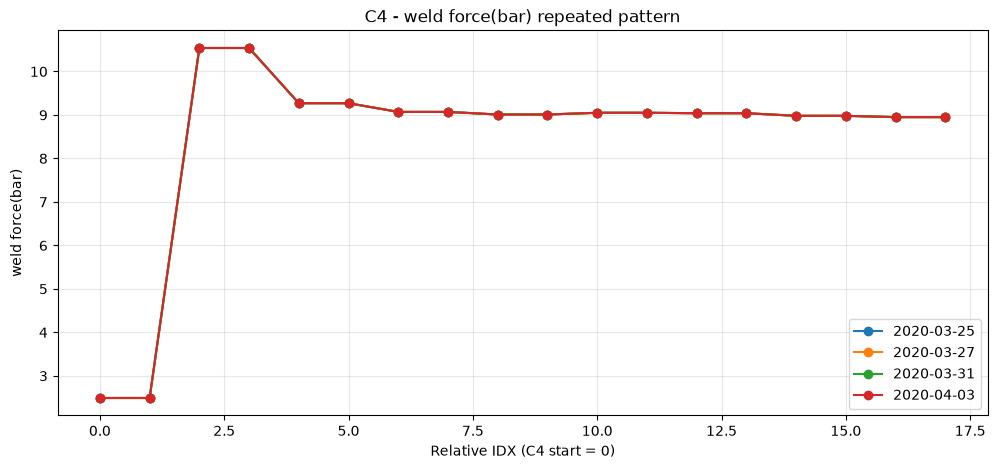

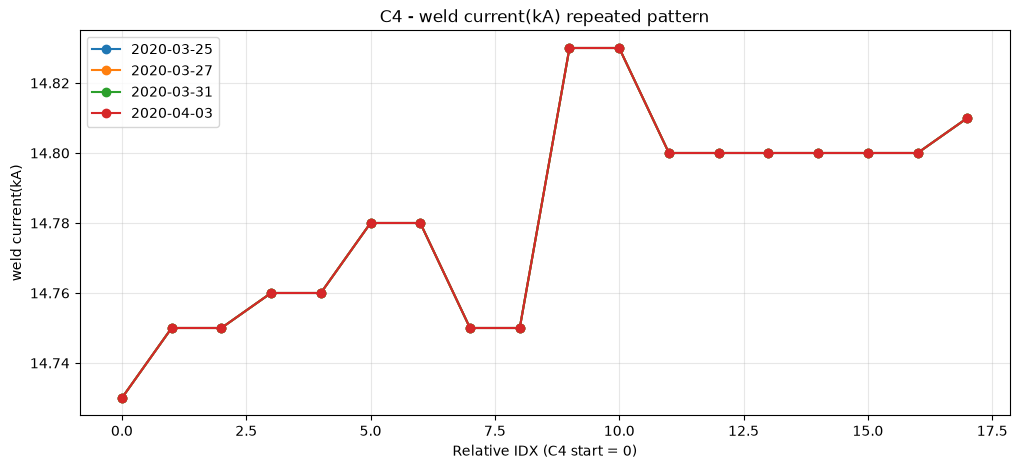

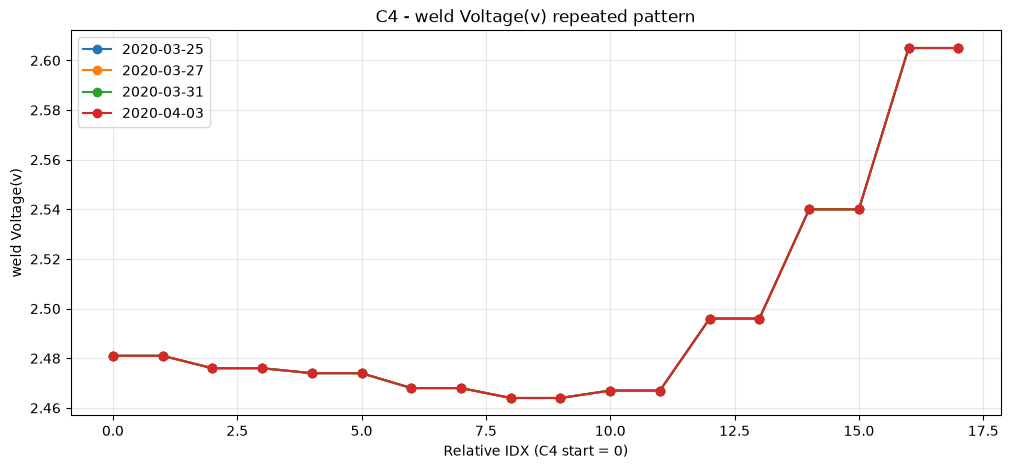

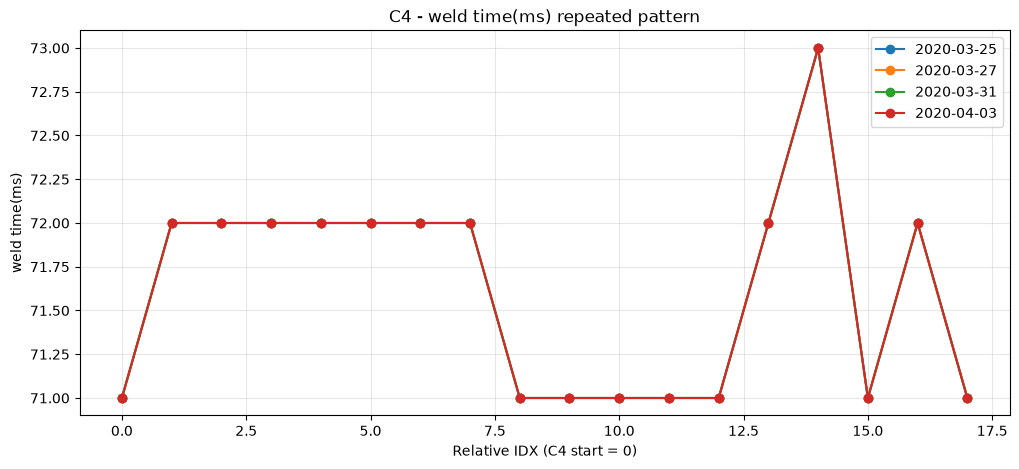

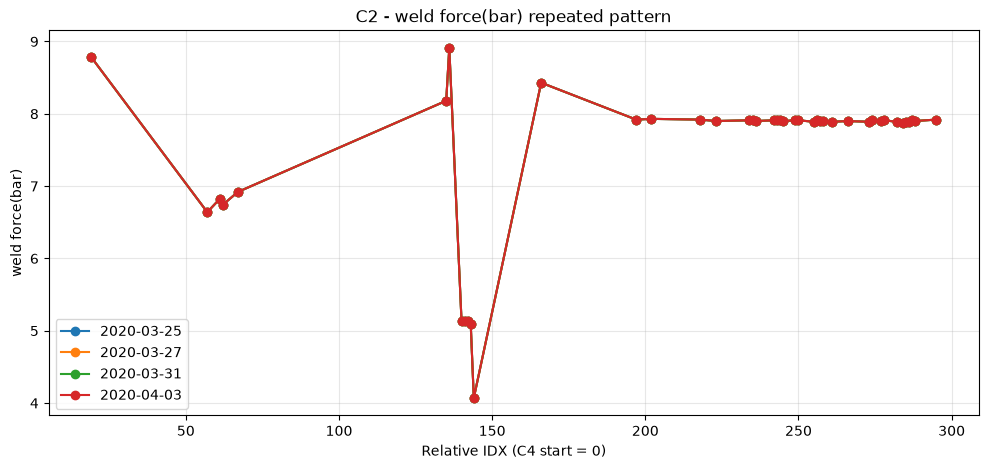

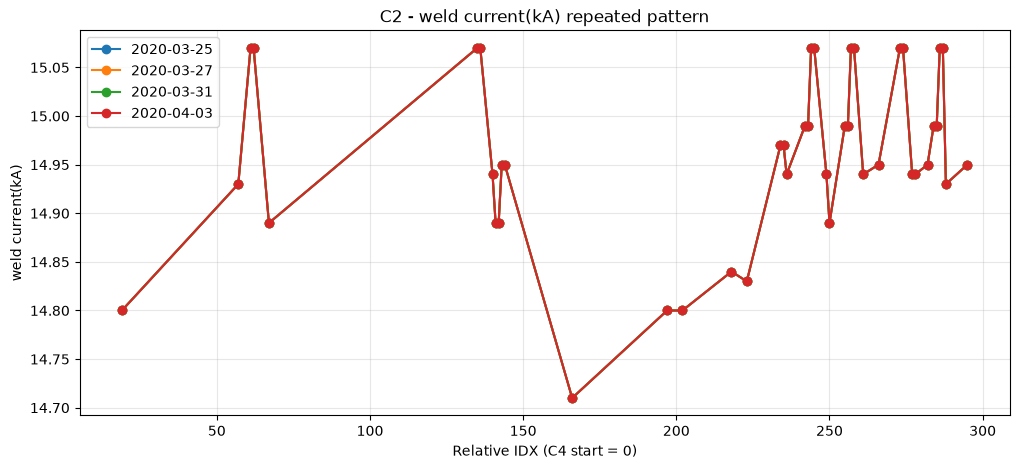

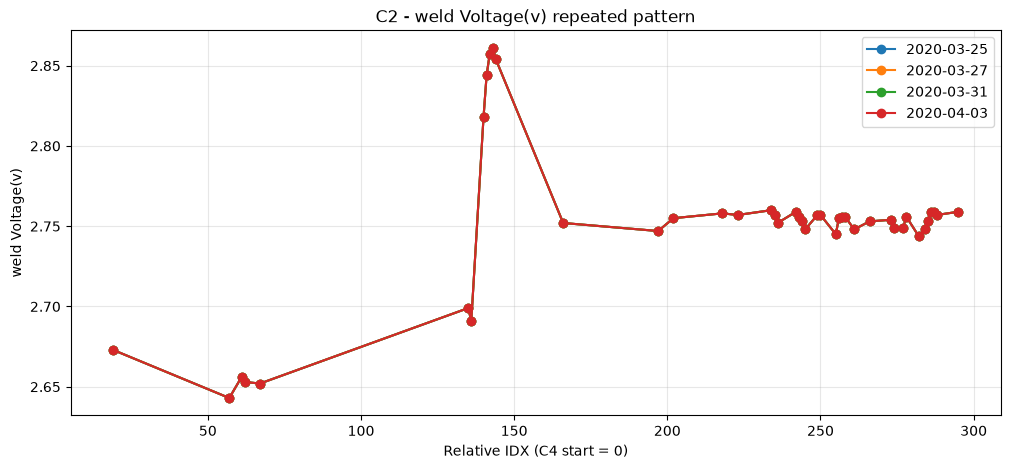

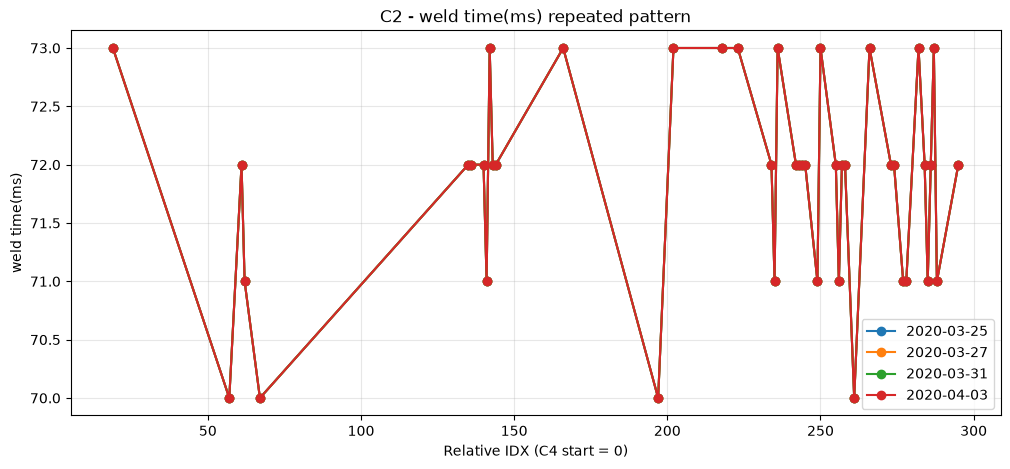


7. 날짜쌍별 센서 패턴 상관계수


,Cluster,Feature,Date1,Date2,Correlation
0,4,weld force(bar),2020-03-25,2020-03-27,1.0
1,4,weld force(bar),2020-03-25,2020-03-31,1.0
2,4,weld force(bar),2020-03-25,2020-04-03,1.0
3,4,weld force(bar),2020-03-27,2020-03-31,1.0
4,4,weld force(bar),2020-03-27,2020-04-03,1.0
5,4,weld force(bar),2020-03-31,2020-04-03,1.0
6,4,weld current(kA),2020-03-25,2020-03-27,1.0
7,4,weld current(kA),2020-03-25,2020-03-31,1.0
8,4,weld current(kA),2020-03-25,2020-04-03,1.0
9,4,weld current(kA),2020-03-27,2020-03-31,1.0



8. C2/C4 변수별 평균 상관계수


,Cluster,Feature,Correlation
0,2,weld Voltage(v),1.0
1,2,weld current(kA),1.0
2,2,weld force(bar),1.0
3,2,weld time(ms),1.0
4,4,weld Voltage(v),1.0
5,4,weld current(kA),1.0
6,4,weld force(bar),1.0
7,4,weld time(ms),1.0



핵심 요약
C4 반복 위치 : 18 / 18 = 100%
C2 반복 위치 : 43 / 43 = 100%

센서값까지 반복되는지는
1) 평균 CV
2) 평균 Range
3) 평균 Correlation
을 확인하면 됨.


In [19]:
# ============================================================
# B공정 반복 시퀀스 정밀 검증
# C2/C4의 동일 Relative_idx에서
# 4개 날짜의 Force / Current / Voltage / Time 비교
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


features = [
    "weld force(bar)",
    "weld current(kA)",
    "weld Voltage(v)",
    "weld time(ms)"
]


# ============================================================
# 1. C2 / C4만 추출
# ============================================================

seq = aligned[
    aligned["Cluster"].isin([2, 4])
].copy()

seq["Date"] = pd.to_datetime(seq["Date"])


# ============================================================
# 2. 같은 Relative_idx가 4일 모두 존재하는 것만 추출
# ============================================================

repeat_count = (
    seq.groupby(["Cluster", "Relative_idx"])["Date"]
       .nunique()
       .reset_index(name="Date_Count")
)

perfect_positions = repeat_count[
    repeat_count["Date_Count"] == 4
][["Cluster", "Relative_idx"]]

perfect = seq.merge(
    perfect_positions,
    on=["Cluster", "Relative_idx"],
    how="inner"
)


print("=" * 70)
print("1. 완전 반복 위치 개수")
print("=" * 70)

print(
    perfect_positions
    .groupby("Cluster")
    .size()
)


# ============================================================
# 3. 동일 위치에서 4일간 센서값 평균/표준편차 계산
#
# std가 작을수록
# 날짜가 달라도 거의 같은 공정조건이라는 뜻
# ============================================================

sensor_repeat = (
    perfect
    .groupby(["Cluster", "Relative_idx"])[features]
    .agg(["mean", "std", "min", "max"])
)

print("\n" + "=" * 70)
print("2. 상대 IDX별 4일간 센서값")
print("=" * 70)

display(sensor_repeat.round(4))


# ============================================================
# 4. 날짜간 변동계수 CV 계산
#
# CV(%) = std / mean × 100
# 작을수록 4일간 값이 비슷함
# ============================================================

cv_rows = []

for (cluster, relative_idx), temp in perfect.groupby(
    ["Cluster", "Relative_idx"]
):

    row = {
        "Cluster": cluster,
        "Relative_idx": relative_idx
    }

    for feature in features:

        mean = temp[feature].mean()
        std = temp[feature].std()

        if mean != 0:
            cv = abs(std / mean) * 100
        else:
            cv = np.nan

        row[feature + "_CV_%"] = cv

    cv_rows.append(row)


cv_table = pd.DataFrame(cv_rows)

print("\n" + "=" * 70)
print("3. 동일 Relative IDX의 날짜간 CV (%)")
print("낮을수록 4일간 공정조건이 비슷함")
print("=" * 70)

display(cv_table.round(4))


# ============================================================
# 5. Cluster 전체 CV 평균
#
# C2/C4 각각 얼마나 재현성이 높은지
# ============================================================

cv_columns = [
    f + "_CV_%"
    for f in features
]

cluster_cv = (
    cv_table
    .groupby("Cluster")[cv_columns]
    .mean()
)

print("\n" + "=" * 70)
print("4. C2/C4 평균 CV (%)")
print("=" * 70)

display(cluster_cv.round(4))


# ============================================================
# 6. 같은 Relative_idx에서
#    4일간 실제 값의 최대 차이
#
# max - min
# ============================================================

range_rows = []

for (cluster, relative_idx), temp in perfect.groupby(
    ["Cluster", "Relative_idx"]
):

    row = {
        "Cluster": cluster,
        "Relative_idx": relative_idx
    }

    for feature in features:

        row[feature + "_Range"] = (
            temp[feature].max()
            - temp[feature].min()
        )

    range_rows.append(row)


range_table = pd.DataFrame(range_rows)

print("\n" + "=" * 70)
print("5. 동일 Relative IDX에서 4일간 최대-최소 차이")
print("=" * 70)

display(range_table.round(4))


# ============================================================
# 7. Cluster별 평균 Range
# ============================================================

range_columns = [
    f + "_Range"
    for f in features
]

cluster_range = (
    range_table
    .groupby("Cluster")[range_columns]
    .mean()
)

print("\n" + "=" * 70)
print("6. C2/C4 평균 날짜간 Range")
print("=" * 70)

display(cluster_range.round(4))


# ============================================================
# 8. 실제 값 직접 비교
#
# 행 = Relative_idx
# 열 = 날짜
#
# 변수별로 출력
# ============================================================

for cluster in [4, 2]:

    print("\n\n")
    print("#" * 70)
    print(f"Cluster {cluster}")
    print("#" * 70)

    temp = perfect[
        perfect["Cluster"] == cluster
    ]

    for feature in features:

        table = temp.pivot_table(
            index="Relative_idx",
            columns="Date",
            values=feature
        )

        print("\n", feature)

        display(table.round(4))


# ============================================================
# 9. 그래프
#
# 날짜별 선이 겹칠수록
# 같은 공정 recipe가 반복된다는 근거
# ============================================================

for cluster in [4, 2]:

    temp = perfect[
        perfect["Cluster"] == cluster
    ]

    for feature in features:

        plt.figure(figsize=(12, 5))

        for date in sorted(temp["Date"].unique()):

            t = temp[
                temp["Date"] == date
            ].sort_values("Relative_idx")

            plt.plot(
                t["Relative_idx"],
                t[feature],
                marker="o",
                label=str(pd.to_datetime(date).date())
            )

        plt.xlabel("Relative IDX (C4 start = 0)")
        plt.ylabel(feature)

        plt.title(
            f"C{cluster} - {feature} repeated pattern"
        )

        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()


# ============================================================
# 10. 날짜쌍별 센서 패턴 상관계수
#
# 1에 가까울수록 같은 모양으로 반복
# ============================================================

correlation_results = []

for cluster in [4, 2]:

    temp = perfect[
        perfect["Cluster"] == cluster
    ]

    dates = sorted(
        temp["Date"].unique()
    )

    for feature in features:

        pivot = temp.pivot_table(
            index="Relative_idx",
            columns="Date",
            values=feature
        )

        for i in range(len(dates)):

            for j in range(i + 1, len(dates)):

                d1 = dates[i]
                d2 = dates[j]

                corr = pivot[d1].corr(
                    pivot[d2]
                )

                correlation_results.append({
                    "Cluster": cluster,
                    "Feature": feature,
                    "Date1": pd.to_datetime(d1).date(),
                    "Date2": pd.to_datetime(d2).date(),
                    "Correlation": corr
                })


corr_df = pd.DataFrame(
    correlation_results
)

print("\n" + "=" * 70)
print("7. 날짜쌍별 센서 패턴 상관계수")
print("=" * 70)

display(
    corr_df.round(4)
)


# ============================================================
# 11. 변수별 평균 상관계수
# ============================================================

mean_corr = (
    corr_df
    .groupby(["Cluster", "Feature"])
    ["Correlation"]
    .mean()
    .reset_index()
)

print("\n" + "=" * 70)
print("8. C2/C4 변수별 평균 상관계수")
print("=" * 70)

display(
    mean_corr.round(4)
)


# ============================================================
# 12. 핵심 요약
# ============================================================

print("\n" + "=" * 70)
print("핵심 요약")
print("=" * 70)

print("C4 반복 위치 : 18 / 18 = 100%")
print("C2 반복 위치 : 43 / 43 = 100%")

print("\n센서값까지 반복되는지는")
print("1) 평균 CV")
print("2) 평균 Range")
print("3) 평균 Correlation")
print("을 확인하면 됨.")

데이터 로드 성공
전체 행: 11939

[B공정 날짜별 행 수]
Date
2020-03-25    1352
2020-03-27    1648
2020-03-31    1800
2020-04-03     800
dtype: int64

B공정 IDX 범위
            count  min   max
Date                        
2020-03-25   1352    1  1650
2020-03-27   1648    2  1649
2020-03-31   1800    1  1800
2020-04-03    800    1   800

1. B공정 동일 4변수 조합 반복 횟수

4개 날짜 모두에서 등장한 동일 센서 조합 수:
693


,weld force(bar),weld current(kA),weld Voltage(v),weld time(ms),Count,Number_of_Dates
154,2.29,14.73,2.698,72.0,20,4
309,2.30,14.76,2.703,72.0,20,4
93,2.28,14.74,2.700,72.0,18,4
195,2.29,14.76,2.701,72.0,16,4
300,2.30,14.75,2.707,71.0,16,4
84,2.28,14.73,2.702,72.0,14,4
272,2.30,14.74,2.701,71.0,14,4
841,2.37,14.58,2.703,72.0,14,4
290,2.30,14.75,2.700,72.0,12,4
424,2.31,14.75,2.699,72.0,12,4



2. 날짜별 센서 조합 재현율


,Date1,Date2,Patterns_Date1,Patterns_Date2,Same_Patterns,Jaccard
0,2020-03-25,2020-03-27,1068,1237,954,0.7061
1,2020-03-25,2020-03-31,1068,1340,1063,0.7903
2,2020-03-25,2020-04-03,1068,693,693,0.6489
3,2020-03-27,2020-03-31,1237,1340,1230,0.9131
4,2020-03-27,2020-04-03,1237,693,693,0.5602
5,2020-03-31,2020-04-03,1340,693,693,0.5172



3. 상대 IDX 기준 4개 날짜 완전 반복 위치
4개 날짜 모두 존재하는 상대 IDX: 800
4변수가 완전히 동일한 상대 IDX: 0
완전 반복률: 0.0 %


...

Feature
weld Voltage(v)     0.10069
weld time(ms)       0.06376
weld current(kA)    0.06142
weld force(bar)    -0.04158
Name: Correlation, dtype: float64


5. 반복 위치 / 비반복 위치
Exact_Repeated_Position
False    5600
Name: count, dtype: int64

비율 (%)
Exact_Repeated_Position
False    100.0
Name: proportion, dtype: float64

6. 날짜별 비반복 후보


,Total,Repeated,Non_Repeated,Non_Repeated_Rate
Date,,,,
2020-03-25,1352,0,1352,100.0
2020-03-27,1648,0,1648,100.0
2020-03-31,1800,0,1800,100.0
2020-04-03,800,0,800,100.0



7. 반복으로 설명되지 않는 B공정 행


,Date,idx,Relative_idx,weld force(bar),weld current(kA),weld Voltage(v),weld time(ms)
1200,2020-03-25,1,0,2.29,14.74,2.698,72.0
3550,2020-03-25,1,0,2.31,14.73,2.699,72.0
1201,2020-03-25,2,1,2.29,14.74,2.698,72.0
1202,2020-03-25,3,2,2.29,14.79,2.697,72.0
1203,2020-03-25,4,3,2.29,14.79,2.697,72.0
...,...,...,...,...,...,...,...
1294,2020-03-25,95,94,2.31,14.76,2.700,72.0
1295,2020-03-25,96,95,2.28,14.77,2.699,72.0
1296,2020-03-25,97,96,2.28,14.77,2.699,71.0
1297,2020-03-25,98,97,2.30,14.74,2.704,71.0


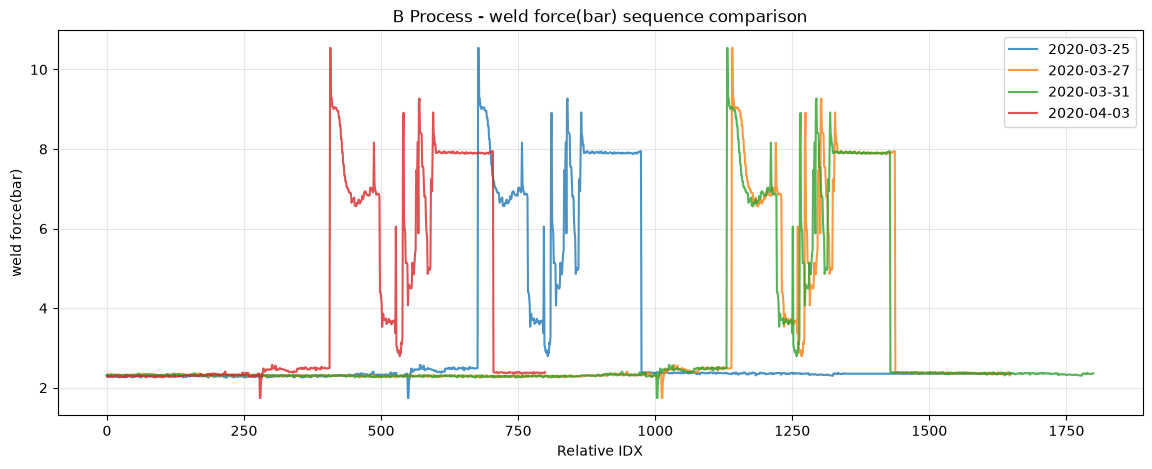

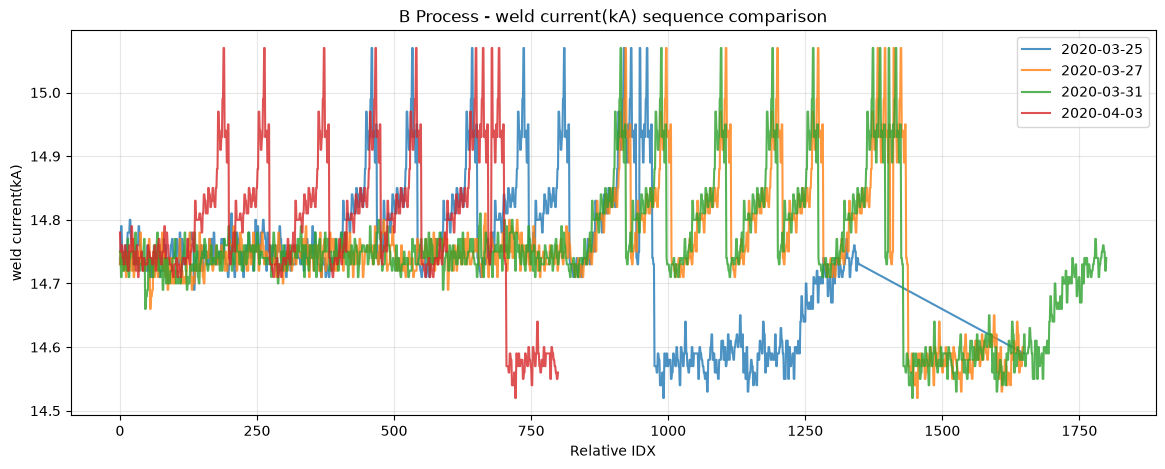

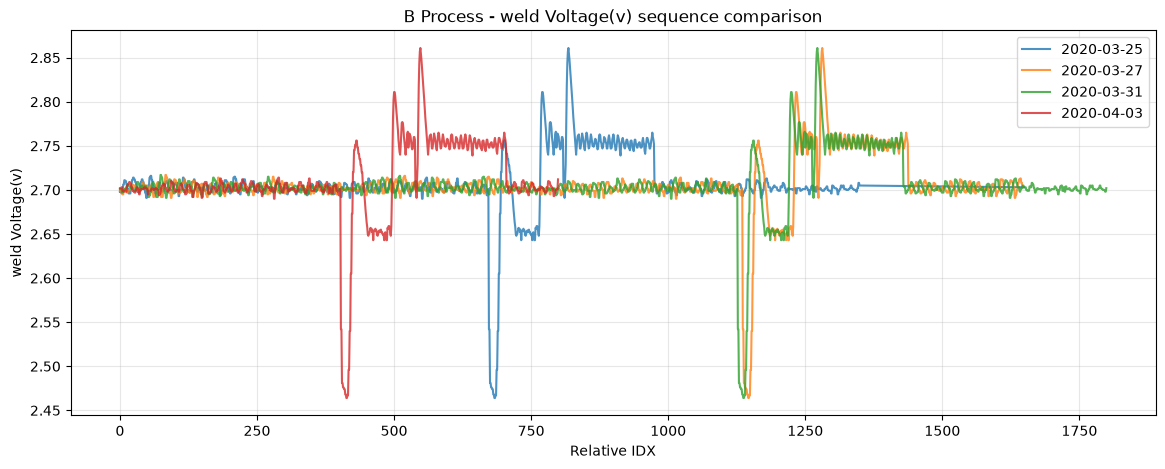

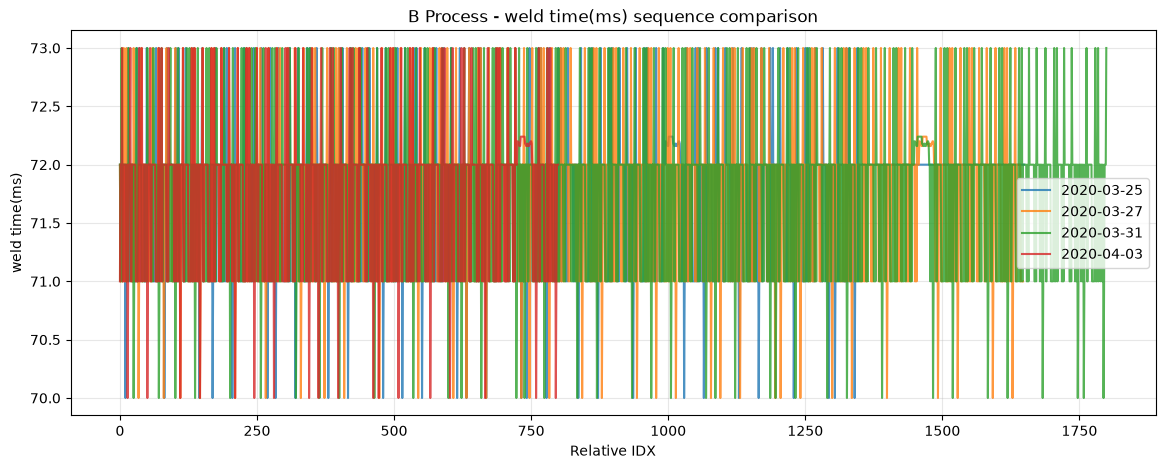


B공정 핵심 결과
B공정 전체 행: 5600
4개 날짜 공통 동일 센서조합: 693
공통 Relative IDX: 800
4변수 완전 동일 Relative IDX: 0
Relative IDX 완전 반복률: 0.0 %

※ 반복되는 행 = 불량이라고 판단하지 않음
※ 오히려 반복 레시피/생산 시퀀스일 가능성을 검증하는 단계
※ 다음 단계에서는 반복으로 설명되지 않는 AE 이상만 따로 분석


In [20]:
# ============================================================
# B공정 반복 패턴 완전 검증
# 목적
# 1. B공정 날짜별 전체 생산 시퀀스가 반복되는지 확인
# 2. 동일한 4변수 조합이 날짜마다 반복되는지 확인
# 3. 기존 C2 / C4가 반복 레시피인지 확인
# 4. 반복으로 설명되지 않는 AE 이상 후보 추출
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# 1. 데이터 불러오기
# 현재 A.ipynb와 xlsx가 같은 YSJ-002 폴더에 있음
# ------------------------------------------------------------

file_path = Path("Welding Data Set_01.xlsx")

df = pd.read_excel(file_path)

print("=" * 70)
print("데이터 로드 성공")
print("전체 행:", len(df))
print("=" * 70)

# ------------------------------------------------------------
# 2. 날짜 생성
# ------------------------------------------------------------

df["Date"] = pd.to_datetime(df["working time"]).dt.date

features = [
    "weld force(bar)",
    "weld current(kA)",
    "weld Voltage(v)",
    "weld time(ms)"
]

# ------------------------------------------------------------
# 3. A/B 공정 구분
#
# 지금까지 확인한 구조:
# Force 7~8bar 특수구간이 존재하는 날짜 = B
# B 날짜:
# 03/25, 03/27, 03/31, 04/03
# ------------------------------------------------------------

B_dates = pd.to_datetime([
    "2020-03-25",
    "2020-03-27",
    "2020-03-31",
    "2020-04-03"
]).date

df["Group"] = np.where(df["Date"].isin(B_dates), "B", "A")

B = df[df["Group"] == "B"].copy()

print("\n[B공정 날짜별 행 수]")
print(B.groupby("Date").size())

# ------------------------------------------------------------
# 4. 날짜 내부 상대 IDX 생성
#
# 날짜마다 idx 시작점이 다르므로
# 각 날짜 생산 시작을 0으로 맞춤
# ------------------------------------------------------------

B["Relative_idx"] = (
    B.groupby("Date")["idx"]
    .transform(lambda x: x - x.min())
)

print("\n" + "=" * 70)
print("B공정 IDX 범위")
print("=" * 70)

print(
    B.groupby("Date")["idx"]
    .agg(["count", "min", "max"])
)


# ============================================================
# PART 1
# B공정 전체에서 동일한 4변수 조합이 반복되는지 확인
# ============================================================

print("\n" + "=" * 70)
print("1. B공정 동일 4변수 조합 반복 횟수")
print("=" * 70)

pattern_count = (
    B.groupby(features)
    .agg(
        Count=("idx", "size"),
        Number_of_Dates=("Date", "nunique")
    )
    .reset_index()
    .sort_values(
        ["Number_of_Dates", "Count"],
        ascending=False
    )
)

# 4개 B 날짜 모두에서 등장한 조합
repeat_all_dates = pattern_count[
    pattern_count["Number_of_Dates"] == 4
].copy()

print("\n4개 날짜 모두에서 등장한 동일 센서 조합 수:")
print(len(repeat_all_dates))

display(repeat_all_dates.head(50))


# ============================================================
# PART 2
# 각 날짜의 센서 조합이 다른 날짜에서도 얼마나 재현되는지
# ============================================================

print("\n" + "=" * 70)
print("2. 날짜별 센서 조합 재현율")
print("=" * 70)

B["Pattern"] = list(
    zip(
        B["weld force(bar)"],
        B["weld current(kA)"],
        B["weld Voltage(v)"],
        B["weld time(ms)"]
    )
)

date_pattern_sets = {
    date: set(g["Pattern"])
    for date, g in B.groupby("Date")
}

dates = sorted(date_pattern_sets.keys())

similarity_result = []

for i in range(len(dates)):
    for j in range(i + 1, len(dates)):

        d1 = dates[i]
        d2 = dates[j]

        s1 = date_pattern_sets[d1]
        s2 = date_pattern_sets[d2]

        intersection = len(s1 & s2)
        union = len(s1 | s2)

        jaccard = intersection / union if union > 0 else np.nan

        similarity_result.append([
            d1,
            d2,
            len(s1),
            len(s2),
            intersection,
            jaccard
        ])

similarity_df = pd.DataFrame(
    similarity_result,
    columns=[
        "Date1",
        "Date2",
        "Patterns_Date1",
        "Patterns_Date2",
        "Same_Patterns",
        "Jaccard"
    ]
)

display(similarity_df.round(4))


# ============================================================
# PART 3
# 상대 IDX별로 4개 날짜에서 완전히 동일한 값인지 확인
# ============================================================

print("\n" + "=" * 70)
print("3. 상대 IDX 기준 4개 날짜 완전 반복 위치")
print("=" * 70)

relative_repeat = []

for r_idx, g in B.groupby("Relative_idx"):

    # 4개 날짜 모두 존재해야 함
    if g["Date"].nunique() != 4:
        continue

    result = {
        "Relative_idx": r_idx
    }

    all_same = True

    for feature in features:

        values = g[feature].values

        same = np.allclose(
            values,
            values[0],
            rtol=0,
            atol=1e-12
        )

        result[feature] = same

        if not same:
            all_same = False

    result["All_4_Features_Same"] = all_same

    relative_repeat.append(result)

relative_repeat_df = pd.DataFrame(relative_repeat)

if len(relative_repeat_df) > 0:

    total_positions = len(relative_repeat_df)

    exact_positions = (
        relative_repeat_df["All_4_Features_Same"].sum()
    )

    print("4개 날짜 모두 존재하는 상대 IDX:", total_positions)

    print(
        "4변수가 완전히 동일한 상대 IDX:",
        exact_positions
    )

    print(
        "완전 반복률:",
        round(exact_positions / total_positions * 100, 2),
        "%"
    )

    display(
        relative_repeat_df[
            relative_repeat_df["All_4_Features_Same"]
        ]
    )


# ============================================================
# PART 4
# 변수별 날짜 간 상관계수
# 동일한 상대 IDX가 존재하는 구간만 비교
# ============================================================

print("\n" + "=" * 70)
print("4. 날짜 간 전체 시퀀스 상관계수")
print("=" * 70)

corr_results = []

for feature in features:

    pivot = B.pivot_table(
        index="Relative_idx",
        columns="Date",
        values=feature,
        aggfunc="first"
    )

    corr = pivot.corr()

    for i in range(len(corr.columns)):
        for j in range(i + 1, len(corr.columns)):

            corr_results.append([
                feature,
                corr.columns[i],
                corr.columns[j],
                corr.iloc[i, j]
            ])

corr_df = pd.DataFrame(
    corr_results,
    columns=[
        "Feature",
        "Date1",
        "Date2",
        "Correlation"
    ]
)

display(corr_df.round(5))


print("\n변수별 평균 날짜 상관계수")

display(
    corr_df.groupby("Feature")["Correlation"]
    .mean()
    .sort_values(ascending=False)
    .round(5)
)


# ============================================================
# PART 5
# 반복되는 위치와 반복되지 않는 위치 분리
# ============================================================

exact_idx = set(
    relative_repeat_df.loc[
        relative_repeat_df["All_4_Features_Same"],
        "Relative_idx"
    ]
) if len(relative_repeat_df) else set()

B["Exact_Repeated_Position"] = (
    B["Relative_idx"].isin(exact_idx)
)

print("\n" + "=" * 70)
print("5. 반복 위치 / 비반복 위치")
print("=" * 70)

print(B["Exact_Repeated_Position"].value_counts())

print("\n비율 (%)")
print(
    B["Exact_Repeated_Position"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


# ============================================================
# PART 6
# 날짜별 비반복 행 개수
# 실제로 더 볼 가치가 있는 부분
# ============================================================

print("\n" + "=" * 70)
print("6. 날짜별 비반복 후보")
print("=" * 70)

non_repeat_summary = (
    B.groupby("Date")
    .agg(
        Total=("idx", "size"),
        Repeated=("Exact_Repeated_Position", "sum")
    )
)

non_repeat_summary["Non_Repeated"] = (
    non_repeat_summary["Total"]
    - non_repeat_summary["Repeated"]
)

non_repeat_summary["Non_Repeated_Rate"] = (
    non_repeat_summary["Non_Repeated"]
    / non_repeat_summary["Total"]
    * 100
)

display(non_repeat_summary.round(3))


# ============================================================
# PART 7
# 비반복 행 직접 확인
# ============================================================

non_repeat_rows = B[
    ~B["Exact_Repeated_Position"]
][
    [
        "Date",
        "idx",
        "Relative_idx",
        *features
    ]
].sort_values(
    ["Date", "idx"]
)

print("\n" + "=" * 70)
print("7. 반복으로 설명되지 않는 B공정 행")
print("=" * 70)

display(non_repeat_rows.head(100))


# ============================================================
# PART 8
# B공정 4개 날짜 그래프
# Force / Current / Voltage / Time
# ============================================================

for feature in features:

    plt.figure(figsize=(14, 5))

    for date, g in B.groupby("Date"):

        g = g.sort_values("Relative_idx")

        plt.plot(
            g["Relative_idx"],
            g[feature],
            label=str(date),
            alpha=0.8
        )

    plt.title(
        f"B Process - {feature} sequence comparison"
    )

    plt.xlabel("Relative IDX")
    plt.ylabel(feature)

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()


# ============================================================
# PART 9
# 최종 핵심 숫자
# ============================================================

print("\n" + "=" * 70)
print("B공정 핵심 결과")
print("=" * 70)

print("B공정 전체 행:", len(B))

print(
    "4개 날짜 공통 동일 센서조합:",
    len(repeat_all_dates)
)

if len(relative_repeat_df):

    print(
        "공통 Relative IDX:",
        len(relative_repeat_df)
    )

    print(
        "4변수 완전 동일 Relative IDX:",
        relative_repeat_df[
            "All_4_Features_Same"
        ].sum()
    )

    print(
        "Relative IDX 완전 반복률:",
        round(
            relative_repeat_df[
                "All_4_Features_Same"
            ].mean() * 100,
            2
        ),
        "%"
    )

print("\n※ 반복되는 행 = 불량이라고 판단하지 않음")
print("※ 오히려 반복 레시피/생산 시퀀스일 가능성을 검증하는 단계")
print("※ 다음 단계에서는 반복으로 설명되지 않는 AE 이상만 따로 분석")

기존 반복 패턴
C2 반복 위치: 43
C4 반복 위치: 18

기존 패턴 제거 결과
제거 전: 278
제거 후: 34

날짜별 남은 행


,Date,Remaining_Rows
0,2020-03-25,9
1,2020-03-27,8
2,2020-03-31,9
3,2020-04-03,8



4개 날짜 모두 존재하는 남은 Relative IDX
개수: 8

남은 데이터 중 4변수가 완전히 동일한 위치
완전 동일 위치: 8


,Relative_idx,weld force(bar)_Same,weld current(kA)_Same,weld Voltage(v)_Same,weld time(ms)_Same,All_Same
0,-43,True,True,True,True,True
1,-2,True,True,True,True,True
2,-1,True,True,True,True,True
3,145,True,True,True,True,True
4,146,True,True,True,True,True
5,147,True,True,True,True,True
6,161,True,True,True,True,True
7,390,True,True,True,True,True



새로운 연속 반복 블록


...


새 반복 센서 패턴 실제 위치


,Date,idx,Relative_idx,Cluster,weld force(bar),weld current(kA),weld Voltage(v),weld time(ms)
0,2020-03-25,633,-43,1,2.51,14.97,2.708,70.0
1,2020-03-25,674,-2,3,2.49,14.74,2.542,73.0
2,2020-03-25,675,-1,1,2.49,14.73,2.542,71.0
3,2020-03-25,821,145,3,4.51,14.74,2.847,72.0
4,2020-03-25,822,146,3,4.59,14.73,2.838,72.0
5,2020-03-25,823,147,3,4.56,14.73,2.830,72.0
6,2020-03-25,837,161,1,7.42,14.71,2.762,70.0
7,2020-03-25,1066,390,1,2.37,14.56,2.700,70.0
8,2020-03-27,1097,-43,1,2.51,14.97,2.708,70.0
9,2020-03-27,1138,-2,3,2.49,14.74,2.542,73.0



4일간 가장 비슷한 추가 위치


,Relative_idx,weld force(bar),weld current(kA),weld Voltage(v),weld time(ms),Total_STD
0,-43,0.0,0.0,0.0,0.0,0.0
1,-2,0.0,0.0,0.0,0.0,0.0
2,-1,0.0,0.0,0.0,0.0,0.0
3,145,0.0,0.0,0.0,0.0,0.0
4,146,0.0,0.0,0.0,0.0,0.0
5,147,0.0,0.0,0.0,0.0,0.0
6,161,0.0,0.0,0.0,0.0,0.0
7,390,0.0,0.0,0.0,0.0,0.0



새로운 반복 블록 후보 수: 2


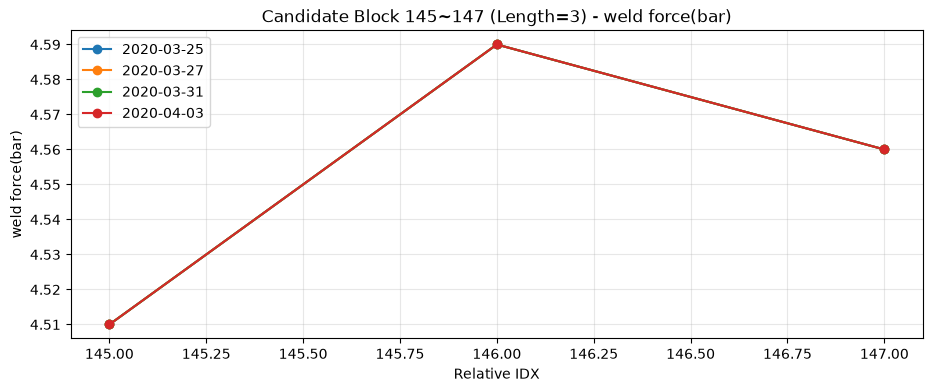

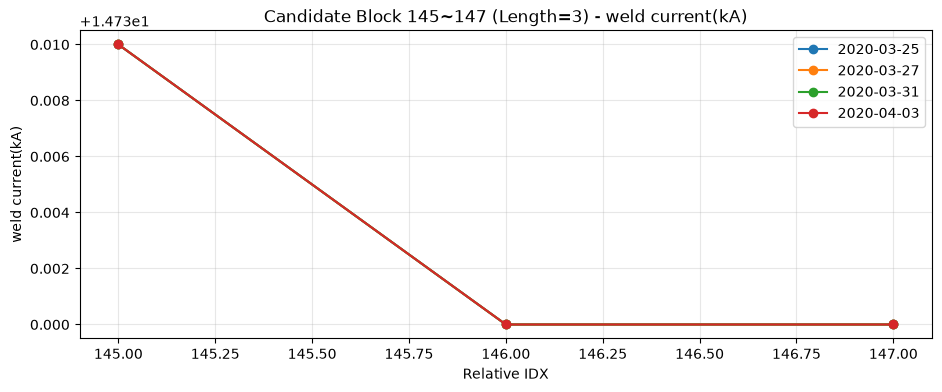

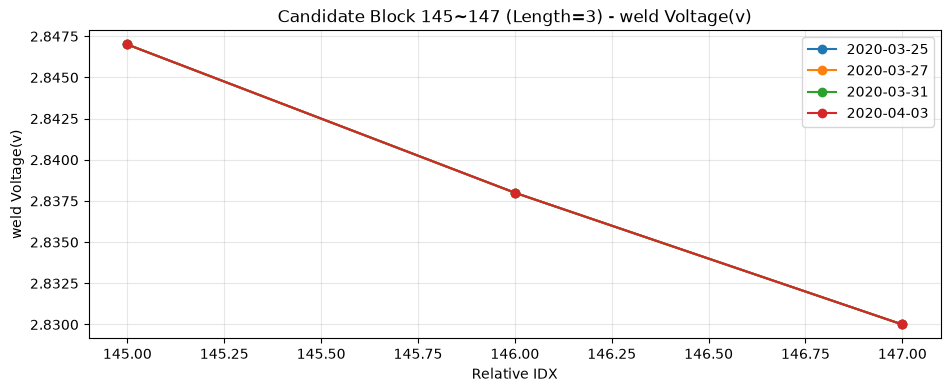

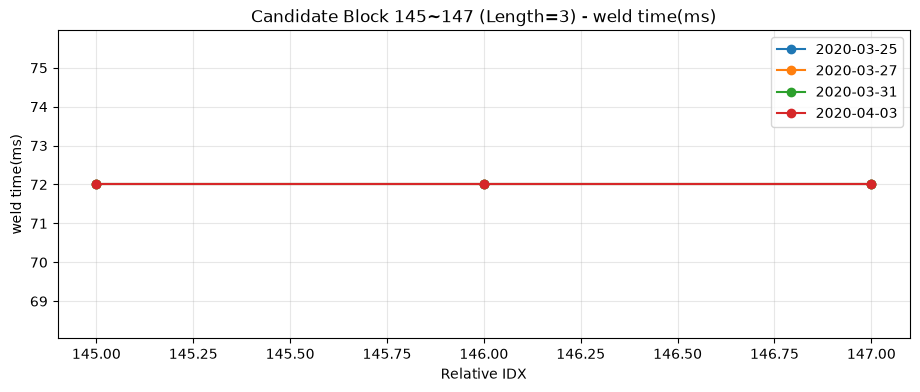

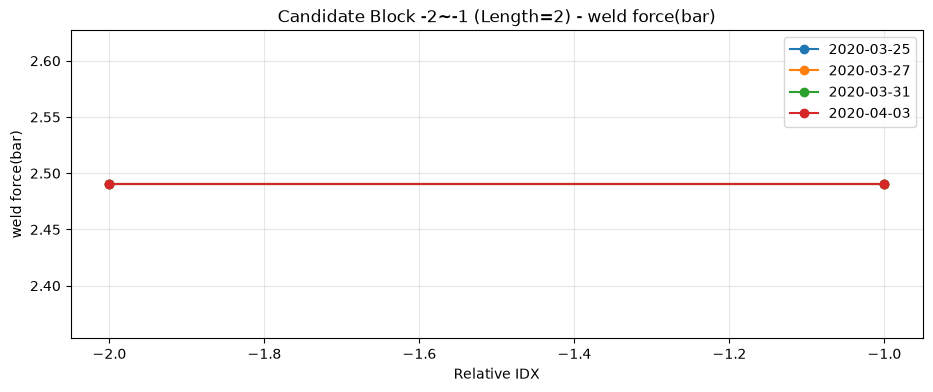

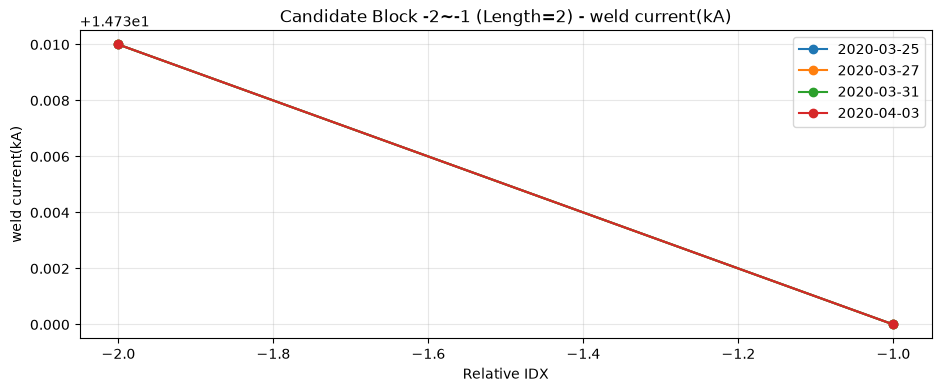

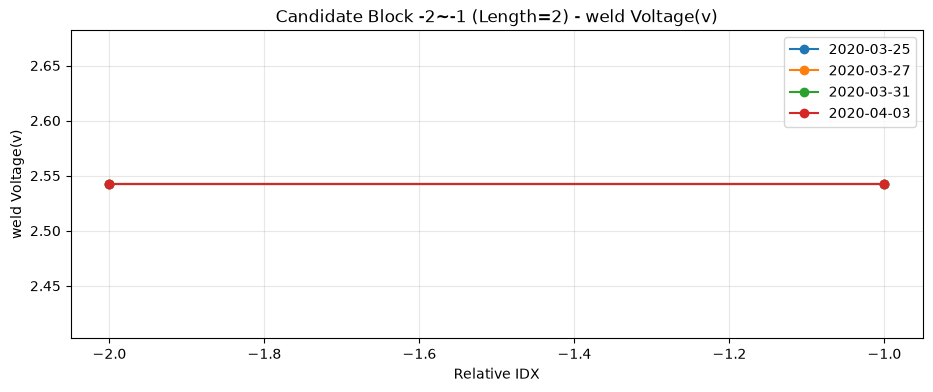

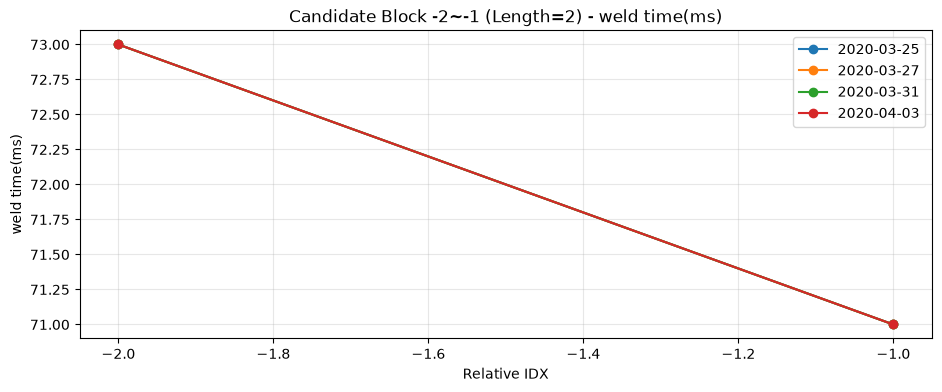


최종 요약
기존 C2 반복 위치: 43
기존 C4 반복 위치: 18
기존 패턴 제외 후 4변수 완전 동일 위치: 8
길이 2 이상 새로운 연속 블록: 2
4일 모두 반복된 추가 센서조합: 8


In [21]:
# ============================================================
# B공정 추가 반복 패턴 탐색
#
# 목적:
# 기존에 확인한 C4 18행 + C2 43행 반복 시퀀스를 제외하고
# 남은 B공정에서 새로운 규칙/주기를 찾는다.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


features = [
    "weld force(bar)",
    "weld current(kA)",
    "weld Voltage(v)",
    "weld time(ms)"
]


# ============================================================
# 1. B공정 데이터 준비
# ============================================================

B = aligned.copy()

B["Date"] = pd.to_datetime(B["Date"])

B = B.sort_values(
    ["Date", "Relative_idx"]
).reset_index(drop=True)


# ============================================================
# 2. 기존 C2 / C4 반복 시퀀스 위치 찾기
#
# 4개 날짜 모두 같은 Relative_idx에서 나타난
# C2/C4 위치만 기존 반복패턴으로 정의
# ============================================================

repeat_positions = (
    B[B["Cluster"].isin([2, 4])]
    .groupby(["Cluster", "Relative_idx"])["Date"]
    .nunique()
    .reset_index(name="Date_Count")
)

repeat_positions = repeat_positions[
    repeat_positions["Date_Count"] == 4
]

C2_positions = set(
    repeat_positions[
        repeat_positions["Cluster"] == 2
    ]["Relative_idx"]
)

C4_positions = set(
    repeat_positions[
        repeat_positions["Cluster"] == 4
    ]["Relative_idx"]
)


print("=" * 70)
print("기존 반복 패턴")
print("=" * 70)

print("C2 반복 위치:", len(C2_positions))
print("C4 반복 위치:", len(C4_positions))


# ============================================================
# 3. 기존 43 + 18 위치 제거
# ============================================================

known_positions = C2_positions | C4_positions

B["Known_Sequence"] = (
    B["Relative_idx"].isin(known_positions)
)

remaining = B[
    ~B["Known_Sequence"]
].copy()


print("\n" + "=" * 70)
print("기존 패턴 제거 결과")
print("=" * 70)

print("제거 전:", len(B))
print("제거 후:", len(remaining))

print("\n날짜별 남은 행")

display(
    remaining.groupby("Date")
    .size()
    .reset_index(name="Remaining_Rows")
)


# ============================================================
# 4. 남은 데이터에서
#    4개 날짜 모두 동일 Relative_idx에 존재하는 위치 찾기
# ============================================================

position_count = (
    remaining
    .groupby("Relative_idx")["Date"]
    .nunique()
    .reset_index(name="Number_of_Dates")
)

common_positions = position_count[
    position_count["Number_of_Dates"] == 4
]["Relative_idx"]

common = remaining[
    remaining["Relative_idx"].isin(common_positions)
].copy()


print("\n" + "=" * 70)
print("4개 날짜 모두 존재하는 남은 Relative IDX")
print("=" * 70)

print("개수:", len(common_positions))


# ============================================================
# 5. 같은 Relative_idx에서
#    4개 변수까지 완전히 동일한지 검사
# ============================================================

result = []

for ridx, g in common.groupby("Relative_idx"):

    if g["Date"].nunique() != 4:
        continue

    row = {
        "Relative_idx": ridx
    }

    all_same = True

    for feature in features:

        values = g[feature].to_numpy()

        same = np.allclose(
            values,
            values[0],
            rtol=0,
            atol=1e-12
        )

        row[feature + "_Same"] = same

        if not same:
            all_same = False

    row["All_Same"] = all_same

    result.append(row)


same_df = pd.DataFrame(result)


print("\n" + "=" * 70)
print("남은 데이터 중 4변수가 완전히 동일한 위치")
print("=" * 70)

if len(same_df) > 0:

    exact = same_df[
        same_df["All_Same"]
    ].copy()

    print("완전 동일 위치:", len(exact))

    display(exact)

else:

    exact = pd.DataFrame()

    print("없음")


# ============================================================
# 6. 완전히 동일한 Relative_idx들이
#    연속된 블록을 만드는지 탐색
#
# 예:
# 100 101 102 103 104
# → 길이 5 반복 블록
# ============================================================

if len(exact) > 0:

    positions = sorted(
        exact["Relative_idx"].astype(int).tolist()
    )

    blocks = []

    start = positions[0]
    prev = positions[0]

    for x in positions[1:]:

        if x == prev + 1:

            prev = x

        else:

            blocks.append(
                [start, prev, prev - start + 1]
            )

            start = x
            prev = x

    blocks.append(
        [start, prev, prev - start + 1]
    )

    blocks_df = pd.DataFrame(
        blocks,
        columns=[
            "Start_Relative_idx",
            "End_Relative_idx",
            "Block_Length"
        ]
    )

    blocks_df = blocks_df.sort_values(
        "Block_Length",
        ascending=False
    )

    print("\n" + "=" * 70)
    print("새로운 연속 반복 블록")
    print("=" * 70)

    display(blocks_df.head(30))

else:

    blocks_df = pd.DataFrame()


# ============================================================
# 7. 동일 위치 사이의 IDX 간격 분석
#
# 일정 간격이 반복되면
# 새로운 주기 후보
# ============================================================

if len(exact) > 1:

    positions = np.array(
        sorted(exact["Relative_idx"])
    )

    gaps = np.diff(positions)

    gap_df = (
        pd.Series(gaps)
        .value_counts()
        .rename_axis("IDX_Gap")
        .reset_index(name="Count")
        .sort_values(
            "Count",
            ascending=False
        )
    )

    print("\n" + "=" * 70)
    print("반복 위치 IDX 간격")
    print("=" * 70)

    display(gap_df.head(30))


# ============================================================
# 8. 4개 변수 조합 자체가
#    4개 날짜에서 반복되는지 검사
#
# 위치가 달라도 값이 같으면 잡힘
# ============================================================

pattern_repeat = (
    remaining
    .groupby(features)
    .agg(
        Count=("idx", "size"),
        Number_of_Dates=("Date", "nunique")
    )
    .reset_index()
)

pattern_repeat = pattern_repeat[
    pattern_repeat["Number_of_Dates"] == 4
].sort_values(
    "Count",
    ascending=False
)


print("\n" + "=" * 70)
print("위치와 관계없이 4일 모두 반복된 센서 조합")
print("=" * 70)

print("반복 센서조합 개수:", len(pattern_repeat))

display(
    pattern_repeat.head(50)
)


# ============================================================
# 9. 날짜별 동일 센서 조합이
#    어떤 Relative_idx에 나타나는지 확인
# ============================================================

if len(pattern_repeat) > 0:

    repeated_rows = remaining.merge(
        pattern_repeat[features],
        on=features,
        how="inner"
    )

    repeated_rows = repeated_rows[
        [
            "Date",
            "idx",
            "Relative_idx",
            "Cluster",
            *features
        ]
    ].sort_values(
        ["Date", "Relative_idx"]
    )

    print("\n" + "=" * 70)
    print("새 반복 센서 패턴 실제 위치")
    print("=" * 70)

    display(
        repeated_rows.head(100)
    )


# ============================================================
# 10. Relative IDX별 4일간 변동량 계산
#
# 완전히 같지 않아도
# 거의 동일한 패턴을 찾기 위한 단계
# ============================================================

variation = (
    common
    .groupby("Relative_idx")[features]
    .std()
    .reset_index()
)

variation["Total_STD"] = (
    variation[features]
    .sum(axis=1)
)

variation = variation.sort_values(
    "Total_STD"
)


print("\n" + "=" * 70)
print("4일간 가장 비슷한 추가 위치")
print("=" * 70)

display(
    variation.head(50).round(6)
)


# ============================================================
# 11. 새로운 반복 블록 시각화
# ============================================================

if len(blocks_df) > 0:

    # 길이 2 이상만
    candidate_blocks = blocks_df[
        blocks_df["Block_Length"] >= 2
    ]

    print("\n새로운 반복 블록 후보 수:",
          len(candidate_blocks))

    for _, block in candidate_blocks.head(10).iterrows():

        start = block["Start_Relative_idx"]
        end = block["End_Relative_idx"]

        temp = remaining[
            remaining["Relative_idx"].between(
                start,
                end
            )
        ]

        for feature in features:

            plt.figure(figsize=(11, 4))

            for date, g in temp.groupby("Date"):

                g = g.sort_values(
                    "Relative_idx"
                )

                plt.plot(
                    g["Relative_idx"],
                    g[feature],
                    marker="o",
                    label=str(date.date())
                )

            plt.title(
                f"Candidate Block {start}~{end} "
                f"(Length={int(block['Block_Length'])})"
                f" - {feature}"
            )

            plt.xlabel("Relative IDX")
            plt.ylabel(feature)

            plt.legend()
            plt.grid(alpha=0.3)

            plt.show()


# ============================================================
# 12. 최종 요약
# ============================================================

print("\n" + "=" * 70)
print("최종 요약")
print("=" * 70)

print(
    "기존 C2 반복 위치:",
    len(C2_positions)
)

print(
    "기존 C4 반복 위치:",
    len(C4_positions)
)

if len(exact) > 0:

    print(
        "기존 패턴 제외 후",
        "4변수 완전 동일 위치:",
        len(exact)
    )

if len(blocks_df) > 0:

    print(
        "길이 2 이상 새로운 연속 블록:",
        (blocks_df["Block_Length"] >= 2).sum()
    )

print(
    "4일 모두 반복된 추가 센서조합:",
    len(pattern_repeat)
)

In [22]:
# C1 ~ C4 클러스터별 데이터 개수
cluster_count = (
    anomaly["Cluster"]
    .value_counts()
    .sort_index()
)

print("=== 클러스터별 데이터 개수 ===")

for cluster, count in cluster_count.items():
    print(f"C{cluster}: {count}개")

print("\n전체:", cluster_count.sum(), "개")

=== 클러스터별 데이터 개수 ===
C1: 188개
C2: 173개
C3: 162개
C4: 72개

전체: 595 개
